# 📘 Cas d'usage — Certification "Concevoir et implémenter une solution d'IA"

Nom Prénom : EL OUARDI Mina <br>
Formation : Concevoir une solution IA <br> 
Date : 26/06/2026

## Introduction

**Nom du projet : TravelMind** - solution IA destinée à aider une agence de voyages haut de gamme à personnaliser les séjours et à anticiper la satisfaction client.

Ce notebook final centralise les étapes stabilisées du projet TravelMind :

1. cadrage métier, définition du besoin, cas d'usage et KPI ;
2. identification, datasheet et gouvernance du dataset ;
3. analyse des risques éthiques, sociétaux, RGPD et conformité AI Act ;
4. analyse métier du dataset brut et contrôles de cohérence ;
5. nettoyage, préparation des données, contrôle des valeurs manquantes, doublons, valeurs négatives et outliers ;
6. feature engineering, versioning des données et segmentation exploratoire ;
7. modélisation pré-voyage, comparaison des modèles, validation croisée et diagnostic de performance ;
8. modélisation post-voyage et comparaison avec le pré-voyage pour analyser l'apport des variables opérationnelles ;
9. expériences complémentaires : NLP exploratoire, SMOTE, Optuna, overfitting, underfitting et essais non retenus ;
10. choix du modèle pré-voyage industrialisé, Model Card, métriques, biais et empreinte carbone ;
11. industrialisation avec `train.py`, TravelMind API, TravelMind Dashboard, Docker, monitoring, CI/CD et stratégie de réentraînement ;
12. synthèse finale, références documentaires et bonnes pratiques adoptées.

## 0. Journal de bord du projet TravelMind

Ce journal de bord synthétise les principales décisions prises pendant le projet. Il permet de suivre l'avancement, la raison de chaque action, les preuves associées et la décision retenue pour le livrable final.

| Étape | Action réalisée | Objectif | Résultat obtenu | Preuve / suite |
| --- | --- | --- | --- | --- |
| Initialisation | Création de l'environnement Python `.venv`, du dépôt Git/GitHub et de la base Docker | Rendre le projet reproductible, versionné et portable | Structure projet en place avec dépendances, dépôt Git et conteneurisation | `requirements.txt`, `.gitignore`, `Dockerfile`, `docker-compose.yml` |
| Cadrage métier | Définition du besoin TravelMind, des cas d'usage pré-voyage et post-voyage, des KPI et des contraintes | Clarifier le problème métier et vérifier que l'IA apporte une valeur | Deux objectifs distingués : prédiction avant départ et analyse qualité après séjour | KPI métier, séparation pré/post-voyage | ??? 
| Dataset | Identification du fichier `Examen_travel_planning_dataset.csv` et vérification des droits d'usage | Vérifier la pertinence, la disponibilité et la cohérence du jeu de données | Dataset synthétique, anonymisé et utilisable dans le cadre de ce projet | `data/Examen_travel_planning_dataset.csv`|
| Datasheet et gouvernance | Documentation de la motivation, composition, usages, limites, distribution et maintenance du dataset | Répondre aux exigences de documentation du jeu de données | Datasheet structurée ajoutée au notebook |
| Éthique, RGPD et AI Act | Analyse des risques, registre RGPD, rôles AI Act, usage clients finaux et obligation d'alphabétisation IA | Encadrer l'usage responsable de TravelMind | Risques, mesures, supervision humaine |
| Analyse métier du dataset brut | Contrôle de l'unicité, satisfaction, budget, prix vol, activités, imprévus, réorganisation et fuite de données | Identifier les cas incohérents ou explicables avant préparation | Incohérences critiques distinguées des observations métier explicables| tableaux de contrôles |
| Préparation des données | Nettoyage, valeurs manquantes, outliers, valeurs négatives, doublons et formats | Renforcer l'intégrité des données avant modélisation | Traitements documentés et appliqués | pipelines sklearn |
| Pipeline | Incluson de l'imputation, encodage, standardisation et traitement IQR dans les pipelines après split train/test | Éviter que le test influence les paramètres appris sur le train | Pipeline plus rigoureux et conforme aux bonnes pratiques ML | `ColumnTransformer`, `Pipeline`, `IQRMedianOutlierReplacer` |
| Feature engineering | Création de variables dérivées pré-voyage et post-voyage explicatives | Ajouter du signal métier tout en respectant le moment d'utilisation | Features pré-voyage retenues pour l'API, variables post-voyage exclues du modèle pré-voyage | Sections feature engineering et liste des features |
| Versioning des données | Mise en place des versions v1.0, v1.1, v1.2, v2.0 et v2.1 | Tracer les transformations du dataset et garantir la reproductibilité | Versions documentées et générées dans `data/versions/` | `scripts/version_data.py`, `docs/data_versioning.md` |
| Modélisation pré-voyage | Comparaison de modèles 3 classes avec baseline, validation croisée et diagnostics | Tester la capacité des variables avant départ à prédire la satisfaction | Performance modeste, cohérente avec le faible signal pré-voyage | Retenu comme modèle industrialise car il correspond au cas d'usage avant départ |
| Expériences pré-voyage | Tests Optuna, RandomizedSearch, SMOTE, SMOTENC, augmentation 20 000 et 50 000 lignes | Chercher un gain de performance sans changer l'objectif métier | Gains limités ou instables, parfois surapprentissage | pour industrialisation | Notebook de tests hyperparamètres, synthèse des essais |
| Modélisation post-voyage | Ajout des variables opérationnelles `imprevus`, `respect_budget`, `reorganisation_necessaire` pour analyse qualité | Comparer le signal disponible après séjour avec le signal pré-voyage | Scores meilleurs, confirmant que les variables post-voyage expliquent davantage la satisfaction | Conservé pour analyse qualité, non retenu pour l'API pré-voyage | Sections post-voyage |
| NLP exploratoire | Analyse de `retour_client` avec tokenisation, lemmatisation, POS, NER et sentiment | Évaluer l'apport du texte libre | NLP utile pour l'analyse qualitative, mais non retenu dans le modèle principal en raison du risque de fuite du ressenti client | Conservé comme exploration | Section NLP exploratoire |
| Évaluation et transparence | Ajout matrice de confusion, validation croisée, overfitting, underfitting, Model Card, métriques éthiques et CodeCarbon | Documenter la performance, les limites et les impacts | Lecture métier des scores, biais et empreinte carbone documentée | Model Card, CodeCarbon |
| Industrialisation | Création de `train.py`, `app/`, TravelMind API, monitoring, logs et TravelMind Dashboard | Servir le modèle pré-voyage hors notebook | API locale fonctionnelle avec `/health`, `/predict`, `/monitoring/*` et interface web | `train.py`, `app/main.py`, `app_web.py` |
| Monitoring et réentraînement | Journalisation JSONL, drift, alertes, dashboard KPI et stratégie de réentraînement | Suivre l'exploitation et déclencher des actions si le contexte change | Monitoring initial et seuils d'alerte disponibles | `app/monitoring.py`, `docs/strategie_reentrainement.md` |
| CI/CD et qualité | Ajout des tests, GitHub Actions | Automatiser les contrôles avant livraison | Tests API/ML/monitoring et contrôle qualité modèle intégrés | `.github/workflows/ci-cd.yml`, `tests/`, `configs/model_quality_gate.json` |
| Architecture cible | Architecture retenue : API locale + dashboard + Docker optionnel + CI/CD | Choisir une architecture proportionnée au prototype | Architecture retenue : API locale + dashboard + Docker optionnel + CI/CD |

## 0.1 Ordre du livrable

Les cellules de code restent placées dans un ordre executable : chargement, nettoyage, modélisation, évaluation, puis industrialisation.

| Partie principale du notebook | Points couverts | Preuves principales |
| --- | --- | --- |
| Cadrage, besoins métier, cas d'usage et dataset | Besoin métier, cas d'usage, données pertinentes, disponibilite, alternatives | Datasheet, contexte métier, analyse du dataset |
| Risques éthiques, sociétaux et registre RGPD | Chartes, impacts, biais, dilemmes, acteurs concernes, verification legale | Analyse éthique, registre RGPD, Model Card |
| Préparation des données | Nommage, formats, valeurs manquantes, doublons, incohérences, stockage, cycle de vie | Nettoyage, contrôles, feature engineering, gouvernance dataset |
| Choix du modèle IA | Indicateurs, contraintes, familles de modèles, eco-conception, résultat attendu | Comparaison modèles, choix pré-voyage, criteres de decision |
| Entraînement supervisé | Pipeline, hyperparamêtres, optimisation, validation, feature engineering | Pipelines scikit-learn, Optuna, SMOTE teste, validation croisee |
| Implémentation et intégration | Versioning, CI/CD, API, reporting, suivi des prédictions | `train.py`, FastAPI, Streamlit, tests, GitHub Actions |
| Architecture cible | Scenarios d'architecture, contraintes, couts, acteurs a interroger | Schema d'architecture, scenarios local/Docker/cloud/MLOps |
| Performance et impacts | Métriques, seuils, suivi, interprétation, actions declenchees | Matrices, rapports, monitoring, CodeCarbon, métriques éthiques |
| Amélioration continue | Évaluation automatisee, métriques intégrées, periodicite de revue | Quality gate CI/CD, strategie de réentraînement, monitoring |

## C1. Cadrage, besoins métier, cas d'usage et dataset

### 1.1 Définition du problème métier

L'agence de voyages souhaite améliorer la personnalisation des séjours et la satisfaction client à partir de l'historique des voyages. Le problème métier concret est double :

- avant le départ, estimer si les informations disponibles lors de la planification suffisent à anticiper la satisfaction client ;
- après le séjour, identifier les facteurs opérationnels associés à une satisfaction faible ou élevée afin d'améliorer les futures propositions.

La cible métier étudiée est `satisfaction_client`. Le projet distingue donc volontairement deux cas d'usage : un objectif pré-voyage, utile pour la planification, et un objectif post-voyage, utile pour l'analyse qualité et l'amélioration continue.

### 1.2 Objectifs IA retenus et règles de fuite de données

| Objectif | Moment d'utilisation | Variables autorisées | Variables exclues |
| --- | --- | --- | --- |
| Pré-voyage | Avant le départ | profil, budget, destination, saison, durée, hébergement, météo prévue, activité | `imprevus`, `reorganisation_necessaire`, `respect_budget`, `retour_client` |
| Post-voyage | Après ou pendant le séjour | variables pré-voyage + événements opérationnels observés | `retour_client` brut et variables NLP dérivées |

Pour le modèle pré-voyage final, la satisfaction est regroupée en 3 classes :

- `0` : insatisfait, notes 1 et 2 ;
- `1` : neutre, note 3 ;
- `2` : satisfait, notes 4 et 5.

Cette séparation évite la fuite de données : les variables connues uniquement pendant ou après le séjour ne doivent pas être utilisées pour prédire la satisfaction avant le départ.

### 1.3 Indicateurs de succès du projet

| KPI | Rôle dans le projet | Seuil ou interprétation attendue |
| --- | --- | --- |
| `macro_f1` | Mesurer la performance globale en tenant compte des classes minoritaires | Indicateur principal pour comparer les modèles |
| `balanced_accuracy` | Vérifier que le modèle ne favorise pas uniquement la classe majoritaire | Doit être supérieur au modèle naïf |
| Matrice de confusion | Identifier les classes les plus confondues | La classe `neutre` est surveillée spécifiquement |
| Stabilité en validation croisée | Vérifier que le score ne dépend pas d'un seul découpage train/test | Écart-type faible recherché |
| Cohérence métier des variables importantes | Vérifier que le modèle s'appuie sur des signaux interprétables | Les variables post-voyage doivent ressortir dans l'objectif post-voyage |
| Absence de fuite de données | Garantir que le modèle respecte le moment d'utilisation prévu | Obligatoire pour comparer pré-voyage et post-voyage |

### 1.4 Contraintes du projet

| Contrainte | Impact sur le projet |
| --- | --- |
| Données synthétiques | Les résultats servent de preuve de méthode et de démonstrateur ; ils ne constituent pas encore une validation opérationnelle sur clients réels. |
| Volume limité, environ 1500 lignes | Les modèles complexes risquent de surapprendre et les performances restent sensibles au découpage train/test. |
| Signal pré-voyage faible | Les variables disponibles avant le départ expliquent peu la satisfaction. |
| Sobriété technique | Les traitements lourds, notamment NLP avancé, Optuna massif ou augmentation extrême, doivent rester optionnels, isolés ou justifiés par un gain mesurable. |
| Contraintes RGPD et AI Act | Toute donnée réelle ou exposition client impose validation RGPD, transparence, supervision humaine, traçabilité et alphabétisation IA. |
| Supervision humaine | Le score ne doit pas déclencher de décision automatique ; un conseiller doit pouvoir valider, corriger ou ignorer la recommandation. |

### 1.5 L'IA est-elle nécessaire ?

Une solution simple suffit pour certaines parties du projet : règles métier, tableaux de bord, contrôles de cohérence et statistiques descriptives permettent déjà d'identifier des anomalies et des facteurs de risque.

L'IA devient pertinente uniquement si l'objectif est de généraliser ces observations à de nouveaux séjours et de produire une estimation automatisée de la satisfaction. Les expériences du notebook montrent cependant que :

- le cas pré-voyage contient peu de signal prédictif avec les variables disponibles ;
- le cas post-voyage est plus cohérent pour l'analyse qualité, car il utilise les événements réellement observés pendant ou après le séjour ;

### C1.2 Datasheet structurée du jeu de données

Cette sous-section formalise la datasheet du fichier `data/Examen_travel_planning_dataset.csv` selon les dimensions attendues pour documenter un jeu de données utilisé dans un projet IA.

#### Motivation et contexte de collecte

Le dataset est utilisé dans le cadre d'un projet de planification de voyages. L'objectif métier est d'analyser des séjours passés afin de comprendre les facteurs associés à la satisfaction client et d'évaluer la possibilité de construire un modèle de prédiction. Les données sont synthétiques et anonymisées ; elles ne proviennent donc pas d'une collecte client réelle, mais simulent des situations plausibles de voyages avec budgets, destinations, contraintes, imprévus et retours clients.

#### Composition et statistiques descriptives

Le fichier contient 1500 lignes et 15 colonnes. Chaque ligne représente un séjour. Les variables couvrent le profil client, le budget, la destination, la saison, la durée, l'hébergement, le prix du vol, la météo prévue, l'activité principale, les imprévus, la réorganisation, le respect du budget, la satisfaction client et le retour textuel. Les statistiques descriptives sont vérifiées dans le notebook : valeurs manquantes, distribution de la cible, types de variables, valeurs uniques, doublons, incohérences métier et valeurs atypiques.

#### Variables principales

| Colonne | Type métier | Utilité pour le projet |
| --- | --- | --- |
| `trip_id` | Identifiant technique | Suivi de la ligne ; exclu des entrées du modèle car il ne porte pas de signal métier. |
| `client_type` | Catégorie client | Adapter l’analyse au profil voyageur : famille, couple, solo, business ou senior. |
| `budget_total` | Numérique | Représenter la contrainte budgétaire globale du séjour. |
| `destination` | Catégorie | Comparer les destinations et analyser leur lien avec la satisfaction. |
| `saison` | Catégorie | Tenir compte de la période du voyage et de son effet potentiel sur l’expérience. |
| `duree_jours` | Numérique | Mesurer l’impact de la durée du séjour sur le budget, la logistique et la satisfaction. |
| `type_hebergement` | Catégorie | Évaluer le rôle du type de logement dans l’expérience client. |
| `prix_vol` | Numérique | Mesurer le poids du transport dans le budget total du séjour. |
| `meteo_prevue` | Catégorie | Anticiper les risques liés à la météo avant le départ. |
| `activite_principale` | Catégorie | Relier le séjour aux centres d’intérêt ou au motif principal du client. |
| `satisfaction_client` | Numérique / cible | Variable cible du projet, regroupée ensuite en 3 classes : insatisfait, neutre, satisfait. |
| `imprevus` | Catégorie post-voyage | Variable d’analyse qualité après séjour ; exclue du modèle pré-voyage pour éviter la fuite de données. |
| `reorganisation_necessaire` | Binaire post-voyage | Indique si le séjour a nécessité une réorganisation ; utilisée en analyse post-voyage, exclue du pré-voyage. |
| `respect_budget` | Binaire post-voyage | Indique si le budget prévu a été respecté ; utile pour l’analyse post-voyage, exclu du modèle pré-voyage. |
| `retour_client` | Texte libre | Exploitable pour l’analyse NLP exploratoire ; non retenu dans le modèle principal car trop proche du ressenti final. |

#### Usages recommandés

Le dataset est adapté à l'exploration de données, à l'analyse de cohérence métier, à la comparaison entre un objectif pré-voyage et un objectif post-voyage, ainsi qu'à la construction d'un prototype de modèle IA. Pour le modèle pré-voyage, seules les variables disponibles avant le séjour doivent être utilisées. Pour le modèle post-voyage, les variables d'événements observés comme `imprevus`, `reorganisation_necessaire` et `respect_budget` peuvent être utilisées si l'objectif est l'analyse ou l'évaluation après séjour.

#### Limitations

Le dataset reste synthétique, de taille modérée et ne reflète pas nécessairement toute la complexité d'une activité réelle d'agence de voyages. Certaines variables pré-voyage contiennent peu de signal pour expliquer la satisfaction client. Plusieurs incohérences doivent être contrôlées avant modélisation. Les variables post-voyage ne doivent pas être utilisées dans un modèle censé prédire la satisfaction avant le départ, afin d'éviter une fuite de données.

#### Distribution

Le dataset de référence est stocké localement dans le projet au chemin `data/Examen_travel_planning_dataset.csv`. Comme il s'agit d'un dataset synthétique et anonymisé, il peut être versionné dans GitHub avec le code, la documentation et les notebooks.

Le projet met aussi en place un versioning explicite des données dans `data/versions/` afin de tracer les transformations successives :

| Version | Emplacement | Contenu | Usage |
| --- | --- | --- | --- |
| `v1.0` | `data/versions/v1_0_raw/` | Dataset brut fourni | Référence initiale, sans transformation |
| `v1.1` | `data/versions/v1_1_cleaning/` | Nettoyage des colonnes, espaces et formats | Base propre pour les contrôles qualité |
| `v1.2` | `data/versions/v1_2_incoherences/` | Suppression des incohérences critiques | Base cohérente avant modélisation |
| `v2.0` | `data/versions/v2_0_feature_engineering/` | Ajout des variables dérivées | Base enrichie pour expérimentation |
| `v2.1` | `data/versions/v2_1_enrichment/` | Répertoire prévu pour enrichissements futurs | Sources externes ou nouvelles données à valider |

Le fichier `data/versions/manifest.json` documente les versions produites. Le script `scripts/version_data.py` permet de regénérer ces versions de manière reproductible. La documentation associée est disponible dans `docs/data_versioning.md`.

Si des données réelles étaient ajoutées ultérieurement, leur diffusion ne serait pas automatique : une validation RGPD, une anonymisation ou pseudonymisation, une politique d'accès, une durée de conservation et une validation juridique seraient nécessaires avant tout partage ou versioning public.

#### Maintenance

Toute modification du dataset doit être documentée : ajout de colonnes, correction d'incohérences, enrichissement externe, suppression de lignes ou changement de cible. Les traitements appliqués doivent rester reproductibles dans le notebook. En cas d'évolution du jeu de données, il faudra mettre à jour les statistiques descriptives, les contrôles de cohérence, la liste des variables autorisées et les résultats de modélisation.

## C2. Risques éthiques, sociétaux et registre RGPD

Dans ce projet, le traitement porte uniquement sur le fichier `data/Examen_travel_planning_dataset.csv`. Ce fichier est un dataset synthétique et anonymisé. Il ne contient pas de nom, prénom, email, téléphone, adresse, numéro de passeport ou identifiant client réel. Le registre ci-dessous documente donc le traitement réalisé dans ce projet, et non un traitement opérationnel de données clients réelles.

#### Finalités du traitement

| Finalité | Description |
| --- | --- |
| Documentation du dataset | Décrire le jeu de données utilisé pour répondre au besoin métier de planification de voyages. |
| Analyse de cohérence métier | Vérifier la qualité du fichier : valeurs manquantes, incohérences, doublons, valeurs atypiques. |
| Modélisation pré-voyage | Tester la capacité des variables disponibles avant le séjour à expliquer la satisfaction client. |
| Modélisation post-voyage | Tester l'apport des variables observées pendant ou après le séjour : `imprevus`, `respect_budget`, `reorganisation_necessaire`. |

#### Catégories de données collectées

| Catégorie | Colonnes concernées | Statut dans ce projet |
| --- | --- | --- |
| Identifiant technique | `trip_id` | Identifiant synthétique de ligne, non rattaché à une personne réelle. |
| Profil voyageur simulé | `client_type` | Catégorie générique : famille, couple, solo, business, senior. |
| Caractéristiques du séjour | `destination`, `saison`, `duree_jours`, `type_hebergement`, `activite_principale`, `meteo_prevue` | Variables descriptives du voyage fictif. |
| Données budgétaires simulées | `budget_total`, `prix_vol` | Montants fictifs utilisés pour l'analyse et la modélisation. |
| Événements post-voyage simulés | `imprevus`, `reorganisation_necessaire`, `respect_budget` | Variables opérationnelles fictives connues après ou pendant le séjour. |
| Satisfaction et avis fictifs | `satisfaction_client`, `retour_client` | Score et commentaire synthétiques, sans auteur identifiable. |

Aucune donnée personnelle directement identifiable n'est traitée dans le périmètre actuel du notebook.

#### Durée de conservation

| Élément conservé | Durée retenue pour ce projet |
| --- | --- |
| Dataset brut synthétique | Conservé dans `data/` pendant la durée du projet. |
| Notebooks d'analyse | Conservés dans `notebooks/` pour assurer la traçabilité des choix et des résultats. |
| Documentation projet | Conservée dans `docs/` et dans le notebook pour justifier la démarche. |

Comme le dataset est synthétique, il n'y a pas de durée de conservation liée à des personnes concernées identifiables dans ce projet.

### C2.1 Analyse des risques éthiques et sociétaux

Cette section synthétise les risques éthiques, sociétaux, juridiques et environnementaux propres à TravelMind. Le détail de conformité AI Act est traité une seule fois dans la section C2.2.

#### Positionnement éthique du projet

| Point de cadrage | Position retenue |
| --- | --- |
| Nature de la solution | Outil d'aide à l'analyse et à la recommandation, pas une décision automatique |
| Domaine | Planification de voyages haut de gamme et anticipation de la satisfaction client |
| Données | Dataset synthétique et anonymisé, sans données personnelles réelles |
| Sortie du modèle | Prédiction probabiliste en 3 classes : insatisfait, neutre, satisfait |
| Usage autorisé | Aide à la personnalisation, priorisation des contrôles humains, analyse qualité |

#### Risques identifiés et mesures retenues

| Risque | Conséquence possible | Mesure appliquée dans le projet |
| --- | --- | --- |
| Surinterprétation du score | Le client ou le conseiller peut croire que la prédiction est certaine | Affichage des probabilités, du niveau de confiance, des limites du modèle et maintien d'une supervision humaine |
| Performance pré-voyage modeste | Le score peut être utilisé comme une certitude alors que le signal pré-voyage est faible | Positionnement du modèle comme aide indicative, lecture des métriques, matrice de confusion et revue humaine obligatoire |
| Fuite de données | Utiliser des informations post-voyage pour prédire avant départ fausserait les performances | Séparation stricte pré-voyage / post-voyage et exclusion de `imprevus`, `respect_budget`, `reorganisation_necessaire` et `retour_client` du modèle pré-voyage |
| Automatisation excessive | Le score pourrait déclencher une décision commerciale sans validation humaine | Usage interdit pour refus automatique, tarification individualisée injustifiée ou remplacement du conseiller |
| Données synthétiques | Les résultats peuvent ne pas refléter le comportement de clients réels | Documentation des limites, validation métier requise et réévaluation avant usage avec données réelles |
| Données personnelles futures | L'ajout de données clients réelles pourrait créer des risques RGPD | Registre de traitement, minimisation, anonymisation/pseudonymisation, politique d'accès et validation juridique avant diffusion |
| Manque d'alphabétisation IA | Les utilisateurs internes peuvent mal interpréter les sorties du modèle | Formation courte, guide utilisateur, consignes d'usage, sensibilisation aux biais et procédure de revue humaine |
| Dérive des données en exploitation | Les profils de voyages saisis peuvent s'éloigner du dataset d'entraînement | Monitoring `/monitoring/drift`, alertes, journalisation JSONL et stratégie de réentraînement |
| Impact environnemental | Entraînements lourds, NLP avancé ou optimisations massives peuvent augmenter l'empreinte carbone | Modèles tabulaires sobres, CodeCarbon, NLP non retenu dans le modèle industrialisé et expériences lourdes isolées |

#### Biais potentiels à surveiller

| Axe de biais | Pourquoi le surveiller | Contrôle prévu dans TravelMind |
| --- | --- | --- |
| Budget, prix du vol et hébergement | Ces variables peuvent agir comme proxys socio-économiques et influencer injustement la recommandation | Analyse des erreurs par tranches de budget, contrôle des variables importantes, interdiction d'usage pour exclure ou défavoriser un client |
| Destination, saison et météo prévue | Certaines destinations ou périodes peuvent dominer le dataset et réduire la qualité sur les cas rares | Contrôle de distribution, suivi de dérive via `/monitoring/drift`, comparaison des performances par destination si volume suffisant |
| Classe de satisfaction | Les classes ne sont pas parfaitement équilibrées, ce qui peut favoriser la classe majoritaire | Suivi de `macro_f1`, `balanced_accuracy`, matrice de confusion, baseline `DummyClassifier` et validation croisée |
| Données synthétiques | Le dataset peut ne pas représenter toute la diversité de clients réels d'une agence haut de gamme | Documentation des limites, validation métier avant production, test sur nouvelles données réelles anonymisées si disponibles |
| Texte libre `retour_client` | Le sentiment exprimé peut être très proche de la satisfaction finale et créer une fuite de signal | NLP conservé comme exploration qualitative, non retenu dans le modèle pré-voyage industrialisé |
| Dérive en exploitation | Les voyages saisis dans l'API peuvent évoluer par rapport au jeu d'entraînement | Logs JSONL, dashboard KPI, alertes de dérive, seuils de monitoring et stratégie de réentraînement |

#### Acteurs à informer

| Acteur | Information à transmettre | Action attendue |
| --- | --- | --- |
| Commanditaire / direction métier | Objectif du modèle, performances modestes du pré-voyage, limites du dataset synthétique et usage non automatique | Valider le positionnement comme aide à la décision, pas comme outil de décision automatique |
| Conseillers voyage | Interprétation des probabilités, niveau de confiance, limites du modèle, cas nécessitant une revue humaine | Utiliser TravelMind comme support de conseil et garder la responsabilité de la recommandation finale |
| Clients finaux | Information claire qu'une IA peut assister la personnalisation du séjour et que la proposition peut être revue par un conseiller | Garantir transparence, compréhension et possibilité d'explication humaine |
| Référent juridique / RGPD / DPO | Nature synthétique du dataset actuel, conditions d'ajout de données réelles, registre de traitement, durée de conservation et droits des personnes | Valider le cadre légal avant toute utilisation de données clients réelles ou diffusion externe |
| Équipe data / technique | Variables autorisées, variables exclues, pipeline sans fuite, monitoring, dérive, quality gate et réentraînement | Maintenir le modèle, contrôler les performances et documenter chaque évolution |
| DSI / sécurité | Architecture locale, API, logs, Docker, accès aux données et conditions d'exposition éventuelle hors poste local | Définir les règles d'hébergement, d'accès, de sauvegarde et de sécurité avant production |

#### Conclusion éthique

TravelMind peut être utilisé comme support d'analyse et de personnalisation à condition de conserver une supervision humaine, de présenter les prédictions comme probabilistes, de surveiller les biais, d'informer les acteurs concernés et de ne pas utiliser le score pour prendre une décision automatique individuelle.


### C2.2 Conformité à la loi européenne sur l'IA (AI Act)

Cette section documente les réponses au questionnaire AI Act pour TravelMind, en tenant compté d'un usage destiné aux clients finaux de l'agence de voyage. 

#### Références réglementaires utilisées

Sources officielles : https://artificialintelligenceact.eu/fr/evaluation/verificateur-de-conformite-a-l-acte-de-l-ai-de-l-ue/

#### Positionnement AI Act retenu

Le tableau ci-dessous reprend les 9 questions du questionnaire AI Act applicables au positionnement de TravelMind. Les réponses sont documentées pour le cas du projet : solution de recommandation et d'anticipation de satisfaction pour une agence de voyages, destinée à des utilisateurs finaux, sans décision automatique.

| Elément du questionnaire | Réponse | Justification pour TravelMind |
| --- | --- | --- |
| Type d'entité | Fournisseur/ déployeur | Le projet développe le modèle, l'API et le dashboard. |
| Modification par un acteur aval | Aucune de ces réponses | Aucun déployeur, distributeur ou importateur aval n'a changé la marque, la finalité ou le fonctionnement substantiel du système. |
| Catégories haut risque produits | Aucune | TravelMind n'est pas un composant de sûreté pour aviation civile, véhicules, systèmes ferroviaires, équipements marins ou véhicules agricoles. |
| Systèmes interdits | Aucune | TravelMind ne manipule pas les personnes, n'exploite pas leurs vulnérabilités, ne fait pas de biométrie, notation sociale, police prédictive, reconnaissance faciale ou reconnaissance des émotions. |
| Systèmes transparents | Aucune dans le cadre actuel | TravelMind ne génère pas de contenu synthétique audio, image, vidéo ou texte publié pour informer le public ; ne fait pas de reconnaissance des émotions, de catégorisation biométrique ou de deepfake. |
| Classement haut risque global | non haut risque dans le cadre actuel | Le cas d'usage concerne la personnalisation de voyages et l'aide à l'anticipation de satisfaction. Il ne conditionne pas l'accès à un service essentiel, à l'emploi, au crédit, à l'éducation, à la justice ou à un service public. À réévaluer si la finalité change. |
| Champ d'application | Je suis établi ou situé dans l'UE ; les résultats de mon système d'IA sont utilisés dans l'UE | Le projet est conçu pour une agence de voyage opérant dans l'UE et les recommandations TravelMind sont destinées à des clients ou conseillers situés dans l'UE. |
| Systèmes exclus | Aucune | TravelMind n'est pas développé exclusivement à des fins militaires, n'est pas utilisé par des autorités de pays tiers pour l'application de la loi, n'est pas une simple activité de R&D isolée, n'est pas un composant libre indépendant et n'est pas un usage personnel non professionnel. |

#### Résultat : Obligation d'alphabétisation IA

Voici la démarche d'alphabétisation IA prévue pour TravelMind :

| Mesure | Application pour TravelMind |
| --- | --- |
| Formation courte | Sensibilisation pour conseillers, métier, technique et monitoring |
| Guide utilisateur | Explication des entrees, sorties, classes, probabilites, niveau de confiance et limites |
| Règles d'usage | Interdiction d'utilisér TravelMind seul pour refuser une offre ou remplacer le conseiller |
| Supervision humaine | Le conseiller peut valider, corriger ou ignorer la recommandation |
| Gestion des alertes | Faible confiance, derive ou résultat incoherent = revue humaine obligatoire |
| Mise à jour périodique | Nouvelle sensibilisation après changement majeur du modèle, des données ou du cas d'usage |

## C3. Préparation des données, intégrité et pertinence

Cette partie décrit uniquement les traitements retenus pour rendre le dataset exploitable sans dupliquer le détail déjà présenté dans l'analyse métier. Les contrôles appliqués sont :

| Contrôle | Traitement retenu | Raison |
| --- | --- | --- |
| Unicité | Verification de `trip_id` et des doublons | Garantir qu'un séjour n'est pas compté plusieurs fois |
| Cible `satisfaction_client` | Suppression des valeurs manquantes ou hors intervalle 1-5 | La cible ne doit pas être inventée |
| Prix du vol > budget total | Suppression des lignes incohérentes | On ne connaît pas la valeur correcte à corriger |
| Valeurs manquantes | Imputation dans les pipelines après split train/test | Éviter la fuite de données |
| Outliers numériques | Traitement IQR + médiane apprise sur le train | Limiter l'effet des valeurs extrêmes sans inventer de cible |
| Variables post-voyage | Exclusion du modèle pré-voyage | Respecter le moment d'utilisation et éviter la fuite de données |

Les incohérences explicables métier sont conservées dans l'analyse, mais ne sont pas toutes traitées comme erreurs de données.


### C3.1 Imports et configuration



In [2]:
import os
import math
import time
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import mlflow
import mlflow.sklearn
import optuna

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
    silhouette_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from xgboost import XGBClassifier

# Imports optionnels : ils restent centralisés ici pour garder le notebook lisible.
# Les cellules concernées gèrent l'indisponibilité éventuelle de ces dépendances.
try:
    import spacy
except ImportError:
    spacy = None

try:
    from transformers import pipeline as transformers_pipeline
except ImportError:
    transformers_pipeline = None

try:
    from codecarbon import OfflineEmissionsTracker
except ImportError:
    OfflineEmissionsTracker = None

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MLFLOW_TRACKING_URI = f"sqlite:///{(PROJECT_ROOT / 'mlflow.db').as_posix()}"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("travelmind_satisfaction")

print("MLflow tracking URI:", mlflow.get_tracking_uri())

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 40)

RANDOM_STATE = 42
TARGET_COLUMN = "satisfaction_client"


c:\Users\khadi\Downloads\Examen_IA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLflow tracking URI: sqlite:///c:/Users/khadi/Downloads/Examen_IA/mlflow.db


### C3.2 Chargement du dataset



In [3]:
data_path = Path("..") / "data" / "Examen_travel_planning_dataset.csv"
if not data_path.exists():
    data_path = Path("data") / "Examen_travel_planning_dataset.csv"

df_raw = pd.read_csv(data_path)

print(f"Fichier chargé : {data_path}")
print(f"Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")
display(df_raw.head())

Fichier chargé : ..\data\Examen_travel_planning_dataset.csv
Dimensions : 1500 lignes x 15 colonnes


,trip_id,client_type,budget_total,destination,saison,duree_jours,type_hebergement,prix_vol,meteo_prevue,activite_principale,satisfaction_client,imprevus,reorganisation_necessaire,respect_budget,retour_client
0,1,solo,5548.90,Dubaï,automne,3,hôtel,1320.77,ensoleillé,plage,3.0,annulation,1,0,Séjour mitigé.
1,2,business,3288.27,Rome,printemps,12,hôtel,1524.09,variable,randonnée,4.0,aucun,0,1,Excellent séjour.
2,3,senior,13347.18,Bali,printemps,16,villa,881.94,ensoleillé,plage,5.0,météo,1,1,Excellent séjour.
3,4,couple,7049.42,Sydney,automne,17,appartement,844.39,nuageux,randonnée,3.0,météo,1,1,Séjour mitigé.
4,5,solo,7612.92,Paris,hiver,7,hôtel,1081.24,pluie,gastronomie,2.0,retard_vol,1,1,Séjour mitigé.


### C3.3 Analyse métier détaillée

Cette section reprend l'analyse métier de cohérence du dataset brut : contrôle de la cible, budget, client business, météo, imprevus, risques de fuite de données et sélection des incohérences à traiter avant modélisation.



### 1. Méthode d'analyse

Les contrôles sont réalisés sur le dataset brut, sans correction préalable.

Pour chaque observation, le notebook contient :

1. l'explication métier du contrôle ;
2. le code de détection ;
3. l'affichage des lignes concernées.

Les cas détectés ne sont pas tous des erreurs. Certains sont des points de vigilance.


In [4]:
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)

In [5]:
# Chargement robuste du fichier CSV depuis le dossier data
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "Examen_travel_planning_dataset.csv"
df_brut = pd.read_csv(DATA_PATH)

print(f"Dataset chargé : {DATA_PATH}")
print(f"Dimensions : {df_brut.shape[0]} lignes x {df_brut.shape[1]} colonnes")
display(df_brut.head())

Dataset chargé : c:\Users\khadi\Downloads\Examen_IA\data\Examen_travel_planning_dataset.csv
Dimensions : 1500 lignes x 15 colonnes


,trip_id,client_type,budget_total,destination,saison,duree_jours,type_hebergement,prix_vol,meteo_prevue,activite_principale,satisfaction_client,imprevus,reorganisation_necessaire,respect_budget,retour_client
0,1,solo,5548.90,Dubaï,automne,3,hôtel,1320.77,ensoleillé,plage,3.0,annulation,1,0,Séjour mitigé.
1,2,business,3288.27,Rome,printemps,12,hôtel,1524.09,variable,randonnée,4.0,aucun,0,1,Excellent séjour.
2,3,senior,13347.18,Bali,printemps,16,villa,881.94,ensoleillé,plage,5.0,météo,1,1,Excellent séjour.
3,4,couple,7049.42,Sydney,automne,17,appartement,844.39,nuageux,randonnée,3.0,météo,1,1,Séjour mitigé.
4,5,solo,7612.92,Paris,hiver,7,hôtel,1081.24,pluie,gastronomie,2.0,retard_vol,1,1,Séjour mitigé.


In [6]:
# Fonctions utilitaires utilisées dans tout le notebook

def normaliser_texte(serie):
    """Standardise les textes pour faciliter les comparaisons métier."""
    return serie.fillna("").astype(str).str.strip().str.lower()


def afficher_cas(df_cas, colonnes=None, n=10):
    """Affiche le nombre de cas détectés puis un échantillon lisible."""
    print(f"Nombre de cas détectés : {len(df_cas)}")
    if len(df_cas) == 0:
        print("Aucun cas à afficher.")
        return

    if colonnes is not None:
        display(df_cas[colonnes].head(n))
    else:
        display(df_cas.head(n))


colonnes_principales = [
    "trip_id", "client_type", "budget_total", "destination", "saison",
    "duree_jours", "type_hebergement", "prix_vol", "meteo_prevue",
    "activite_principale", "satisfaction_client", "imprevus",
    "reorganisation_necessaire", "respect_budget"
]

### 2. Vue d'ensemble du dataset brut

Avant de chercher les incohérences métier, on vérifie la structuré générale : volume, colonnes, types et valeurs manquantes.


In [7]:
print("Dimensions du dataset :", df_brut.shape)
print("\nTypes des colonnes :")
display(df_brut.dtypes.to_frame("type"))

missing_values = (
    df_brut.isna().sum()
    .to_frame("nb_valeurs_manquantes")
)
missing_values["pourcentage"] = (missing_values["nb_valeurs_manquantes"] / len(df_brut) * 100).round(2)
missing_values = missing_values.sort_values("nb_valeurs_manquantes", ascending=False)

display(missing_values[missing_values["nb_valeurs_manquantes"] > 0])

Dimensions du dataset : (1500, 15)

Types des colonnes :


,type
trip_id,int64
client_type,object
budget_total,float64
destination,object
saison,object
duree_jours,int64
type_hebergement,object
prix_vol,float64
meteo_prevue,object
activite_principale,object


,nb_valeurs_manquantes,pourcentage
prix_vol,53,3.53
imprevus,53,3.53
activite_principale,48,3.20
budget_total,40,2.67
meteo_prevue,39,2.60
type_hebergement,36,2.40
satisfaction_client,25,1.67
retour_client,25,1.67


### 2.1 Identification des valeurs uniques par colonne

Cette étape complète la vue d'ensemble du dataset brut. Elle permet de contrôler la cardinalité de chaque variable, c'est-à-dire le nombre de valeurs différentes présentes dans chaque colonne.

L'objectif est de vérifier la cohérence des modalités, repérer les colonnes quasi constantes, identifier les variables catégorielles à encoder et détecter les colonnes avec beaucoup de valeurs distinctes, comme les identifiants ou les textes libres.


In [8]:
resume_valeurs_uniques = pd.DataFrame({
    "colonne": df_brut.columns,
    "type": df_brut.dtypes.astype(str).values,
    "nb_valeurs_uniques": [
        df_brut[colonne].nunique(dropna=True)
        for colonne in df_brut.columns
    ],
    "nb_valeurs_manquantes": [
        df_brut[colonne].isna().sum()
        for colonne in df_brut.columns
    ],
    "exemples_valeurs": [
        list(df_brut[colonne].dropna().unique()[:10])
        for colonne in df_brut.columns
    ],
})

resume_valeurs_uniques["taux_unicite_%"] = (
    resume_valeurs_uniques["nb_valeurs_uniques"] / len(df_brut) * 100
).round(2)

resume_valeurs_uniques["interpretation"] = np.select(
    [
        resume_valeurs_uniques["nb_valeurs_uniques"] == len(df_brut),
        resume_valeurs_uniques["nb_valeurs_uniques"] <= 2,
        resume_valeurs_uniques["nb_valeurs_uniques"] <= 20,
    ],
    [
        "identifiant ou texte tres specifique",
        "variable binaire ou quasi binaire",
        "variable categorielle a faible cardinalite",
    ],
    default="variable numerique continue ou forte cardinalite",
)

resume_valeurs_uniques = resume_valeurs_uniques.sort_values(
    "nb_valeurs_uniques",
    ascending=False,
).reset_index(drop=True)

display(resume_valeurs_uniques)

,colonne,type,nb_valeurs_uniques,nb_valeurs_manquantes,exemples_valeurs,taux_unicite_%,interpretation
0,trip_id,int64,1500,0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",100.00,identifiant ou texte tres specifique
1,prix_vol,float64,1429,53,"[1320.77, 1524.09, 881.94, 844.39, 1081.24, 17...",95.27,variable numerique continue ou forte cardinalite
2,budget_total,float64,1419,40,"[5548.9, 3288.27, 13347.18, 7049.42, 7612.92, ...",94.60,variable numerique continue ou forte cardinalite
3,duree_jours,int64,23,0,"[3, 12, 16, 17, 7, 5, 4, 11, 21, 10]",1.53,variable numerique continue ou forte cardinalite
4,retour_client,object,15,25,"[Séjour mitigé., Excellent séjour., De nombreu...",1.00,variable categorielle a faible cardinalite
5,destination,object,8,0,"[Dubaï, Rome, Bali, Sydney, Paris, New York, L...",0.53,variable categorielle a faible cardinalite
6,satisfaction_client,float64,8,25,"[3.0, 4.0, 5.0, 2.0, 1.0, 6.0, 0.0, 7.0]",0.53,variable categorielle a faible cardinalite
7,client_type,object,5,0,"[solo, business, senior, couple, famille]",0.33,variable categorielle a faible cardinalite
8,activite_principale,object,5,48,"[plage, randonnée, gastronomie, business, cult...",0.33,variable categorielle a faible cardinalite
9,imprevus,object,5,53,"[annulation, aucun, météo, retard_vol, bagages]",0.33,variable categorielle a faible cardinalite


### 3. Unicité des séjours

#### Observation métier

Chaque ligne représente un séjour passé. La colonne `trip_id` doit donc identifiér un séjour unique.

Un doublon sur `trip_id` pourrait fausser l'analyse car un même séjour serait compté plusieurs fois.


In [9]:
doublons_trip_id = df_brut[df_brut["trip_id"].duplicated(keep=False)].copy()
doublons_lignes = df_brut[df_brut.duplicated(keep=False)].copy()

print("Doublons sur trip_id :")
afficher_cas(doublons_trip_id, colonnes_principales)

print("\nDoublons exacts sur toutes les colonnes :")
afficher_cas(doublons_lignes, colonnes_principales)

Doublons sur trip_id :
Nombre de cas détectés : 0
Aucun cas à afficher.

Doublons exacts sur toutes les colonnes :
Nombre de cas détectés : 0
Aucun cas à afficher.


### 4. Cohérence de la satisfaction client

#### Observation métier 
Le cahier des charges indique que `satisfaction_client` est un score de 1 à 5.
Les valeurs inférieures à 1, supérieures à 5 ou manquantes sont donc incohérentes avec la définition officielle de la variable.
Ces cas doivent être exclus avant d'utiliser `satisfaction_client` comme cible IA.

In [10]:
satisfaction_invalide = df_brut[
    df_brut["satisfaction_client"].isna()
    | ~df_brut["satisfaction_client"].between(1, 5)
].copy()

afficher_cas(
    satisfaction_invalide,
    ["trip_id", "client_type", "destination", "satisfaction_client", "imprevus", "retour_client"]
)

Nombre de cas détectés : 30


,trip_id,client_type,destination,satisfaction_client,imprevus,retour_client
765,766,couple,Bali,NaN,annulation,Une expérience inoubliable.
771,772,solo,Tokyo,NaN,bagages,À éviter.
778,779,couple,Rome,NaN,annulation,Déçu par l'organisation.
800,801,couple,Paris,6.0,aucun,Très bon rapport qualité-prix.
801,802,famille,Dubaï,NaN,aucun,Une expérience inoubliable.
811,812,solo,Rome,6.0,aucun,"Très satisfait, je recommande."
812,813,solo,Bali,0.0,retard_vol,À éviter.
826,827,couple,Sydney,NaN,météo,Déçu par l'organisation.
835,836,famille,Dubaï,NaN,météo,Excellent séjour.
858,859,famille,Paris,NaN,retard_vol,Très mauvaise expérience.


### 5. Prix du vol supérieur au budget total

#### Observation métier
Le `budget_total` représente le budget global du séjour.
Si `prix_vol > budget_total`, le coût du vol dépasse déjà le budget disponible. C'est une incohérence forte ou un séjour impossible à financer sans dépassement.
Le cas est encore plus problématique si `respect_budget = 1`, car cela indique que le budget aurait été respecté malgré un vol supérieur au budget total.

In [11]:
vol_superieur_budget = df_brut[
    df_brut["prix_vol"].notna()
    & df_brut["budget_total"].notna()
    & (df_brut["prix_vol"] > df_brut["budget_total"])
].copy()

vol_superieur_budget["ecart_vol_budget"] = (
    vol_superieur_budget["prix_vol"] - vol_superieur_budget["budget_total"]
).round(2)

print("Tous les cas où le prix du vol dépasse le budget total :")
afficher_cas(
    vol_superieur_budget.sort_values("ecart_vol_budget", ascending=False),
    ["trip_id", "client_type", "destination", "budget_total", "prix_vol", "ecart_vol_budget", "respect_budget"]
)

print("\nCas contradictoires : prix_vol > budget_total ET respect_budget = 1")
vol_superieur_budget_respecte = vol_superieur_budget[vol_superieur_budget["respect_budget"] == 1]
afficher_cas(
    vol_superieur_budget_respecte,
    ["trip_id", "client_type", "destination", "budget_total", "prix_vol", "ecart_vol_budget", "respect_budget"]
)

Tous les cas où le prix du vol dépasse le budget total :
Nombre de cas détectés : 52


,trip_id,client_type,destination,budget_total,prix_vol,ecart_vol_budget,respect_budget
825,826,couple,Rome,500.00,4500.00,4000.00,0
1388,1389,business,Rome,1052.28,4500.00,3447.72,0
1434,1435,business,Paris,500.00,1554.63,1054.63,0
1384,1385,famille,Lisbonne,4152.93,5200.00,1047.07,1
902,903,famille,Rome,500.00,1535.25,1035.25,0
1413,1414,famille,Tokyo,637.34,1593.89,956.55,0
1144,1145,famille,Dubaï,500.00,1443.55,943.55,0
948,949,couple,New York,500.00,1432.13,932.13,0
1402,1403,business,New York,500.00,1426.89,926.89,0
1206,1207,senior,Lisbonne,500.00,1352.70,852.70,0



Cas contradictoires : prix_vol > budget_total ET respect_budget = 1
Nombre de cas détectés : 5


,trip_id,client_type,destination,budget_total,prix_vol,ecart_vol_budget,respect_budget
7,8,couple,Rome,1173.19,1694.67,521.48,1
216,217,business,Rome,1147.25,1438.08,290.83,1
230,231,business,Dubaï,1388.56,1444.72,56.16,1
887,888,solo,Dubaï,380.00,1023.17,643.17,1
1384,1385,famille,Lisbonne,4152.93,5200.00,1047.07,1


### 6. Cohérence entre client business et activité principale

#### Observation métier

Un client `business` peut avoir une activité principale `business`, mais ce n'est pas obligatoire : il peut aussi prolonger son séjour avec de la culture, de la gastronomie ou une activité de loisir.
Ce contrôle n'est donc pas une erreur automatique. C'est un point de vigilance pour vérifier si le dataset décrit bien le comportement attendu des voyageurs professionnels.


In [12]:
client_type_norm = normaliser_texte(df_brut["client_type"])
activite_norm = normaliser_texte(df_brut["activite_principale"])

business_activite_non_business = df_brut[
    (client_type_norm == "business")
    & (activite_norm != "business")
    & (activite_norm != "")
].copy()

non_business_activite_business = df_brut[
    (client_type_norm != "business")
    & (client_type_norm != "")
    & (activite_norm == "business")
].copy()

print("Clients business avec une activité principale non-business :")
afficher_cas(
    business_activite_non_business,
    ["trip_id", "client_type", "destination", "saison", "activite_principale", "budget_total", "satisfaction_client"]
)

print("\nClients non-business avec une activité principale business :")
afficher_cas(
    non_business_activite_business,
    ["trip_id", "client_type", "destination", "saison", "activite_principale", "budget_total", "satisfaction_client"]
)

Clients business avec une activité principale non-business :
Nombre de cas détectés : 200


,trip_id,client_type,destination,saison,activite_principale,budget_total,satisfaction_client
1,2,business,Rome,printemps,randonnée,3288.27,4.0
14,15,business,New York,été,randonnée,12985.57,4.0
19,20,business,Tokyo,printemps,plage,10416.72,3.0
27,28,business,Lisbonne,été,culture,10572.54,5.0
29,30,business,Dubaï,été,culture,2403.24,4.0
34,35,business,Bali,hiver,gastronomie,7427.80,1.0
37,38,business,New York,printemps,plage,13023.12,5.0
40,41,business,Tokyo,été,culture,5227.96,2.0
41,42,business,Tokyo,été,randonnée,5142.10,5.0
44,45,business,Tokyo,été,culture,4100.91,3.0



Clients non-business avec une activité principale business :
Nombre de cas détectés : 122


,trip_id,client_type,destination,saison,activite_principale,budget_total,satisfaction_client
10,11,senior,Bali,automne,business,12845.33,5.0
15,16,solo,Rome,automne,business,6125.88,1.0
16,17,senior,New York,hiver,business,8193.32,2.0
20,21,famille,Bali,automne,business,8186.44,2.0
23,24,solo,Dubaï,automne,business,13391.63,5.0
25,26,couple,Lisbonne,hiver,business,954.98,1.0
42,43,solo,New York,printemps,business,13696.57,2.0
47,48,couple,Lisbonne,hiver,business,9297.44,5.0
71,72,solo,Sydney,hiver,business,2187.78,3.0
129,130,solo,Tokyo,hiver,business,4161.07,3.0


### 7. Activités extérieures et météo risquée

#### Observation métier

L'activité `randonnée` est sensible à la météo.
Si la météo prévue est `pluie` ou `variable`, le séjour peut nécessiter une alternative ou un plan de réorganisation.
Ce n'est pas forcément une erreur, mais c'est une information importante pour l'anticipation des imprévus.

In [13]:
meteo_norm = normaliser_texte(df_brut["meteo_prevue"])
activites_exterieures = ["randonnée", "randonnee"]
meteos_risquees = ["pluie", "variable"]

activites_meteo_risque = df_brut[
    activite_norm.isin(activites_exterieures)
    & meteo_norm.isin(meteos_risquees)
].copy()

afficher_cas(
    activites_meteo_risque,
    ["trip_id", "destination", "saison", "meteo_prevue", "activite_principale", "imprevus", "reorganisation_necessaire", "satisfaction_client"]
)

Nombre de cas détectés : 75


,trip_id,destination,saison,meteo_prevue,activite_principale,imprevus,reorganisation_necessaire,satisfaction_client
1,2,Rome,printemps,variable,randonnée,aucun,0,4.0
7,8,Rome,été,pluie,randonnée,annulation,1,2.0
9,10,New York,automne,variable,randonnée,météo,1,1.0
14,15,New York,été,pluie,randonnée,retard_vol,1,4.0
32,33,Dubaï,printemps,variable,randonnée,bagages,1,1.0
38,39,Lisbonne,été,pluie,randonnée,retard_vol,1,1.0
51,52,Paris,printemps,variable,randonnée,bagages,1,2.0
54,55,Dubaï,automne,variable,randonnée,retard_vol,1,2.0
157,158,Paris,printemps,variable,randonnée,aucun,0,3.0
169,170,Lisbonne,hiver,variable,randonnée,aucun,0,1.0


### 8. Cohérence entre imprévus et réorganisation

#### Observation métier
La variable `reorganisation_necessaire` doit normalement être liée aux imprévus.
Deux situations sont à contrôler 
1. `imprevus = aucun` mais `reorganisation_necessaire = 1` : cas suspect, car il y a une réorganisation sans imprévu déclaré ;
2. `imprevus != aucun` mais `reorganisation_necessaire = 0` : cas possible si l'imprévu est mineur nécessitant pas une réorganisation.


In [14]:
imprevus_norm = normaliser_texte(df_brut["imprevus"])

aucun_imprevu_mais_reorganisation = df_brut[
    (imprevus_norm == "aucun")
    & (df_brut["reorganisation_necessaire"] == 1)
].copy()

imprevu_sans_reorganisation = df_brut[
    (imprevus_norm != "")
    & (imprevus_norm != "aucun")
    & (df_brut["reorganisation_necessaire"] == 0)
].copy()

print("Aucun imprévu déclaré mais réorganisation nécessaire :")
afficher_cas(
    aucun_imprevu_mais_reorganisation,
    ["trip_id", "destination", "meteo_prevue", "activite_principale", "imprevus", "reorganisation_necessaire", "satisfaction_client"]
)

print("\nImprévu déclaré mais aucune réorganisation :")
afficher_cas(
    imprevu_sans_reorganisation,
    ["trip_id", "destination", "meteo_prevue", "activite_principale", "imprevus", "reorganisation_necessaire", "satisfaction_client"]
)

Aucun imprévu déclaré mais réorganisation nécessaire :
Nombre de cas détectés : 19


,trip_id,destination,meteo_prevue,activite_principale,imprevus,reorganisation_necessaire,satisfaction_client
78,79,Bali,ensoleillé,gastronomie,aucun,1,3.0
135,136,Bali,ensoleillé,plage,aucun,1,3.0
136,137,New York,nuageux,business,aucun,1,4.0
262,263,Lisbonne,pluie,gastronomie,aucun,1,3.0
363,364,Bali,ensoleillé,gastronomie,aucun,1,5.0
395,396,New York,ensoleillé,randonnée,aucun,1,2.0
417,418,Rome,pluie,business,aucun,1,2.0
473,474,Dubaï,pluie,business,aucun,1,2.0
490,491,Lisbonne,nuageux,culture,aucun,1,5.0
496,497,Paris,pluie,plage,aucun,1,2.0



Imprévu déclaré mais aucune réorganisation :
Nombre de cas détectés : 335


,trip_id,destination,meteo_prevue,activite_principale,imprevus,reorganisation_necessaire,satisfaction_client
63,64,Lisbonne,ensoleillé,plage,météo,0,3.0
66,67,Rome,ensoleillé,business,météo,0,4.0
69,70,Tokyo,ensoleillé,randonnée,retard_vol,0,2.0
71,72,Sydney,variable,business,météo,0,3.0
72,73,Lisbonne,ensoleillé,gastronomie,retard_vol,0,1.0
79,80,Tokyo,nuageux,randonnée,bagages,0,2.0
81,82,New York,variable,gastronomie,météo,0,3.0
86,87,Dubaï,pluie,culture,retard_vol,0,1.0
90,91,Paris,ensoleillé,culture,annulation,0,3.0
91,92,Bali,variable,culture,retard_vol,0,4.0


### 9. Imprévus et satisfaction faible

#### Observation métier

Un imprévu peut réduire la satisfaction client.
Les cas où `imprevus != aucun` et `satisfaction_client <= 2` sont cohérents métier, mais importants pour comprendre les facteurs d'insatisfaction.

In [15]:
imprevus_satisfaction_faible = df_brut[
    (imprevus_norm != "")
    & (imprevus_norm != "aucun")
    & df_brut["satisfaction_client"].notna()
    & (df_brut["satisfaction_client"] <= 2)
].copy()

afficher_cas(
    imprevus_satisfaction_faible,
    ["trip_id", "client_type", "destination", "imprevus", "reorganisation_necessaire", "respect_budget", "satisfaction_client", "retour_client"]
)

Nombre de cas détectés : 573


,trip_id,client_type,destination,imprevus,reorganisation_necessaire,respect_budget,satisfaction_client,retour_client
4,5,solo,Paris,retard_vol,1,1,2.0,Séjour mitigé.
7,8,couple,Rome,annulation,1,1,2.0,Séjour mitigé.
8,9,couple,Paris,annulation,1,0,2.0,Séjour mitigé.
9,10,solo,New York,météo,1,0,1.0,Séjour mitigé.
11,12,senior,Paris,retard_vol,1,0,2.0,Séjour mitigé.
12,13,famille,New York,météo,1,1,1.0,Séjour mitigé.
13,14,solo,Sydney,annulation,1,1,2.0,Séjour mitigé.
22,23,famille,Lisbonne,bagages,1,0,1.0,Séjour mitigé.
25,26,couple,Lisbonne,retard_vol,1,1,1.0,Séjour mitigé.
28,29,solo,Bali,retard_vol,1,0,2.0,Séjour mitigé.


### 10. Risque de fuite de données pour la modélisation

#### Observation métier
Certaines colonnes décrivent le résultat du séjour a posteriori :
- `imprevus` ;
- `reorganisation_necessaire` ;
- `respect_budget` ;
- `retour_client`.
Si le modèle doit prédire la satisfaction avant le départ, ces variables ne doivent pas être utilisées comme entrées, car elles ne sont pas connues au moment de la recommandation.
Elles peuvent cependant servir à une analyse après séjour ou à un modèle secondaire d'amélioration continue.

In [16]:
colonnes_post_sejour = ["imprevus", "reorganisation_necessaire", "respect_budget", "retour_client", "satisfaction_client"]
display(df_brut[["trip_id", *colonnes_post_sejour]].head(10))

,trip_id,imprevus,reorganisation_necessaire,respect_budget,retour_client,satisfaction_client
0,1,annulation,1,0,Séjour mitigé.,3.0
1,2,aucun,0,1,Excellent séjour.,4.0
2,3,météo,1,1,Excellent séjour.,5.0
3,4,météo,1,1,Séjour mitigé.,3.0
4,5,retard_vol,1,1,Séjour mitigé.,2.0
5,6,météo,1,1,Excellent séjour.,5.0
6,7,météo,1,1,Excellent séjour.,5.0
7,8,annulation,1,1,Séjour mitigé.,2.0
8,9,annulation,1,0,Séjour mitigé.,2.0
9,10,météo,1,0,Séjour mitigé.,1.0


### 11. Sélection des incohérences à traiter avant modélisation

Toutes les observations précédentes ne doivent pas être corrigées. Certaines sont des signaux métier utiles, d'autres sont des incohérences qui peuvent dégrader directement le modèle.

Pour le modèle principal envisagé, la cible est `satisfaction_client`. On distingue donc :

- les problèmes à traiter obligatoirement avant l'entraînement ;
- les variables à exclure pour éviter la fuite de données ;
- les points de vigilance à conserver car ils peuvent avoir une explication métier plausible.

In [17]:
selection_traitement_modele = pd.DataFrame([
    {
        "controle": "Satisfaction hors échelle ou manquante",
        "impact_modele": "Impact critique sur la cible y",
        "decision": "Traiter obligatoirement",
        "traitement_recommande": "Supprimer les lignes sans cible ou hors échelle 1-5",
    },
    {
        "controle": "Prix du vol supérieur au budget total",
        "impact_modele": "Crée des relations budgétaires impossibles",
        "decision": "Traiter obligatoirement",
        "traitement_recommande": "Exclure les lignes concernées, car corriger prix_vol ou budget_total inventerait une information",
    },
    {
        "controle": "Prix du vol > budget total et respect_budget = 1",
        "impact_modele": "Contradiction métier forte entre budget et résultat",
        "decision": "Traité automatiquement",
        "traitement_recommande": "Ces lignes sont incluses dans la règle générale prix_vol > budget_total et sont donc supprimées",
    },
    {
        "controle": "Aucun imprévu mais réorganisation nécessaire",
        "impact_modele": "Cas suspect fort : une réorganisation est déclarée sans incident associé",
        "decision": "Traiter en nettoyage strict",
        "traitement_recommande": "Exclure ces lignes dans cette version car la réorganisation n'a pas de cause déclarée dans le dataset",
    },
    {
        "controle": "Client business avec activité non-business",
        "impact_modele": "Peut refléter un séjour mixte business/loisir",
        "decision": "Conserver et documenter",
        "traitement_recommande": "Ne pas corriger automatiquement ; conserver comme comportement métier plausible",
    },
    {
        "controle": "Client non-business avec activité business",
        "impact_modele": "Peut refléter une activité professionnelle ponctuelle sans que le client soit typé business",
        "decision": "Conserver et documenter",
        "traitement_recommande": "Ne pas corriger automatiquement ; conserver comme modalité métier plausible",
    },
    {
        "controle": "Imprévu déclaré sans réorganisation",
        "impact_modele": "Peut refléter un incident mineur ou résolu sans modification du séjour",
        "decision": "Conserver et documenter",
        "traitement_recommande": "Ne pas supprimer ; interpréter comme un signal opérationnel plutôt qu'une erreur",
    },
    {
        "controle": "Imprévu avec satisfaction faible",
        "impact_modele": "Signal explicatif cohérent de l'insatisfaction",
        "decision": "Conserver et documenter",
        "traitement_recommande": "Ne pas supprimer ; utiliser dans l'analyse post-voyage, mais exclure du modèle pré-voyage pour éviter la fuite de données",
    },
    {
        "controle": "Variables post-séjour : imprevus, reorganisation_necessaire, respect_budget, retour_client",
        "impact_modele": "Risque majeur de fuite de données si la prédiction est faite avant le départ",
        "decision": "Exclure des features du modèle pré-voyage ; autoriser selon l'objectif post-voyage",
        "traitement_recommande": "Ne pas les mettre dans X pré-voyage ; les utiliser seulement dans le modèle post-voyage explicatif validé",
    },
])

display(selection_traitement_modele)

,controle,impact_modele,decision,traitement_recommande
0,Satisfaction hors échelle ou manquante,Impact critique sur la cible y,Traiter obligatoirement,Supprimer les lignes sans cible ou hors échell...
1,Prix du vol supérieur au budget total,Crée des relations budgétaires impossibles,Traiter obligatoirement,"Exclure les lignes concernées, car corriger pr..."
2,Prix du vol > budget total et respect_budget = 1,Contradiction métier forte entre budget et rés...,Traité automatiquement,Ces lignes sont incluses dans la règle général...
3,Aucun imprévu mais réorganisation nécessaire,Cas suspect fort : une réorganisation est décl...,Traiter en nettoyage strict,Exclure ces lignes dans cette version car la r...
4,Client business avec activité non-business,Peut refléter un séjour mixte business/loisir,Conserver et documenter,Ne pas corriger automatiquement ; conserver co...
5,Client non-business avec activité business,Peut refléter une activité professionnelle pon...,Conserver et documenter,Ne pas corriger automatiquement ; conserver co...
6,Imprévu déclaré sans réorganisation,Peut refléter un incident mineur ou résolu san...,Conserver et documenter,Ne pas supprimer ; interpréter comme un signal...
7,Imprévu avec satisfaction faible,Signal explicatif cohérent de l'insatisfaction,Conserver et documenter,Ne pas supprimer ; utiliser dans l'analyse pos...
8,"Variables post-séjour : imprevus, reorganisati...",Risque majeur de fuite de données si la prédic...,Exclure des features du modèle pré-voyage ; au...,Ne pas les mettre dans X pré-voyage ; les util...


#### Observations non traitées comme erreurs

Les contrôles suivants ne sont pas corrigés automatiquement car ils peuvent représenter des comportements métier réels ou des signaux utiles :

- `client business` avec activité non-business : possible séjour mixte business/loisir ou temps libre pendant un déplacement professionnel ;
- `client non-business` avec activité business : possible activité professionnelle ponctuelle, séminaire, rendez-vous ou voyage personnel avec contrainte professionnelle ;
- activité extérieure avec météo risquée : signal utile pour créer `meteo_risque`, pas une erreur ;
- `imprévu déclaré sans réorganisation` : possible imprévu mineur, incident résolu rapidement ou pris en charge sans modification du planning ;
- `imprévu avec satisfaction faible` : signal explicatif cohérent, utile pour comprendre l'insatisfaction.

Ces cas sont donc conservés dans le dataset. Ils ne sont pas considérés comme des erreurs à supprimer. En revanche, les variables post-voyage restent exclues du modèle pré-voyage pour éviter la fuite de données.

Dans cette version, le nettoyage strict conserve une seule règle opérationnelle liée aux imprévus : supprimer uniquement les lignes `imprevus = aucun` avec `reorganisation_necessaire = 1`, car la réorganisation n'a aucune cause déclarée dans le dataset.

### KPI métier suivis dans le projet

| KPI métier | Définition | Utilité métier |
| --- | --- | --- |
| Taux de satisfaction client | Part des séjours avec `satisfaction_client` égale à 4 ou 5 | Mesurer la part de séjours perçus positivement par les clients |
| Taux d'insatisfaction client | Part des séjours avec `satisfaction_client` égale à 1 ou 2 | Identifier le volume de séjours nécessitant une analyse qualité prioritaire |
| Satisfaction moyenne | Moyenne de `satisfaction_client` sur l'ensemble des séjours | Suivre le niveau global de qualité perçue |
| Taux de respect du budget | Part des séjours avec `respect_budget = 1` | Contrôler la maîtrise budgétaire des propositions de voyage |
| Taux d'imprévus | Part des séjours avec `imprevus` différent de `aucun` | Mesurer l'exposition aux incidents pendant le séjour |
| Taux de réorganisation | Part des séjours avec `reorganisation_necessaire = 1` | Évaluer la charge opérationnelle générée par les incidents |
| Satisfaction moyenne par destination | Moyenne de `satisfaction_client` par destination | Repérer les destinations qui génèrent une satisfaction forte ou faible |
| Satisfaction moyenne par type de client | Moyenne de `satisfaction_client` par `client_type` | Vérifier si certains profils voyageurs sont moins bien servis |


### KPI techniques suivis dans le projet

| KPI technique | Définition | Utilité dans le projet |
| --- | --- | --- |
| `accuracy` | Part globale de prédictions correctes | Donner une première lecture de la performance du modèle |
| `balanced_accuracy` | Accuracy moyenne corrigée par classe | Vérifier que le modèle ne favorise pas uniquement la classe majoritaire |
| `macro_f1` | Moyenne des F1-scores calculés séparément pour chaque classe | Indicateur principal, car il tient compte des classes minoritaires |
| Matrice de confusion | Tableau croisant classes réelles et classes prédites | Identifier les classes les plus confondues par le modèle |
| Validation croisée | Score moyen obtenu sur plusieurs découpages du dataset | Vérifier la stabilité du modèle et limiter la dépendance à un seul train/test split |
| Écart train/test | Différence entre les scores d'entraînement et de test | Détecter un risque d'overfitting ou d'underfitting |
| Taux de faible confiance | Part des prédictions API dont la probabilité maximale est faible | Déclencher une revue humaine lorsque le modèle est incertain |
| Dérive des données | Écart entre les données reçues en API et les données d'entraînement | Surveiller si les usages réels s'éloignent du dataset initial |
| Temps d'inférence | Temps nécessaire pour produire une prédiction | Vérifier que l'API reste exploitable dans un usage interactif |


### C3.4 Contrôles de cohérence métier initiaux



In [18]:
imprevus_initiaux_norm = df_raw["imprevus"].astype("string").str.strip().str.lower()

controle_initial = pd.DataFrame([
    {
        "controle": "doublons trip_id",
        "nb_lignes": int(df_raw["trip_id"].duplicated().sum()),
        "impact": "risque de double comptage",
    },
    {
        "controle": "satisfaction manquante ou hors échelle 1-5",
        "nb_lignes": int((df_raw[TARGET_COLUMN].isna() | ~df_raw[TARGET_COLUMN].between(1, 5)).sum()),
        "impact": "cible invalide pour l'apprentissage",
    },
    {
        "controle": "prix_vol > budget_total",
        "nb_lignes": int((df_raw["prix_vol"] > df_raw["budget_total"]).sum()),
        "impact": "incohérence budgétaire métier",
    },
    {
        "controle": "prix_vol > budget_total et respect_budget = 1",
        "nb_lignes": int(((df_raw["prix_vol"] > df_raw["budget_total"]) & (df_raw["respect_budget"] == 1)).sum()),
        "impact": "contradiction métier forte incluse dans la règle budget",
    },
    {
        "controle": "aucun imprévu mais réorganisation nécessaire",
        "nb_lignes": int(((imprevus_initiaux_norm == "aucun") & (df_raw["reorganisation_necessaire"] == 1)).sum()),
        "impact": "cas suspect fort retenu dans le nettoyage strict",
    },
    {
        "controle": "imprévu déclaré sans réorganisation",
        "nb_lignes": int(((imprevus_initiaux_norm != "") & (imprevus_initiaux_norm != "aucun") & (df_raw["reorganisation_necessaire"] == 0)).sum()),
        "impact": "cas métier possible documenté, non supprimé",
    },
])
display(controle_initial)

,controle,nb_lignes,impact
0,doublons trip_id,0,risque de double comptage
1,satisfaction manquante ou hors échelle 1-5,30,cible invalide pour l'apprentissage
2,prix_vol > budget_total,52,incohérence budgétaire métier
3,prix_vol > budget_total et respect_budget = 1,5,contradiction métier forte incluse dans la règ...
4,aucun imprévu mais réorganisation nécessaire,19,cas suspect fort retenu dans le nettoyage strict
5,imprévu déclaré sans réorganisation,335,"cas métier possible documenté, non supprimé"



### 6.1 Contrôle des valeurs négatives

Les colonnes numériques métier suivantes ne doivent pas contenir de valeurs négatives : `budget_total`, `duree_jours` et `prix_vol`.

Une valeur négative serait incohérente pour le projet : un budget, une durée de séjour ou un prix de vol ne peut pas être inférieur à zéro. Ce contrôle est effectué avant le nettoyage afin d'identifiér les anomalies fortes du dataset brut.


In [19]:
colonnes_controle_negatif = ["budget_total", "duree_jours", "prix_vol"]

controle_valeurs_negatives = []

cas_valeurs_negatives = []
for column in colonnes_controle_negatif:
    serie_numerique = pd.to_numeric(df_raw[column], errors="coerce")
    mask_negatif = serie_numerique < 0
    nb_negatifs = int(mask_negatif.sum())

    controle_valeurs_negatives.append({
        "colonne": column,
        "nb_valeurs_negatives": nb_negatifs,
        "minimum_observe": serie_numerique.min(),
        "decision": "à supprimer ou corriger" if nb_negatifs > 0 else "aucune action nécessaire",
    })

    if nb_negatifs > 0:
        cas = df_raw.loc[mask_negatif, ["trip_id", column]].copy()
        cas["colonne_negative"] = column
        cas_valeurs_negatives.append(cas)

controle_valeurs_negatives = pd.DataFrame(controle_valeurs_negatives)
display(controle_valeurs_negatives)

if cas_valeurs_negatives:
    cas_valeurs_negatives = pd.concat(cas_valeurs_negatives, ignore_index=True)
    display(cas_valeurs_negatives)
else:
    print("Aucune valeur négative détectée dans les colonnes numériques contrôlées.")

,colonne,nb_valeurs_negatives,minimum_observe,decision
0,budget_total,0,380.0,aucune action nécessaire
1,duree_jours,0,2.0,aucune action nécessaire
2,prix_vol,0,35.0,aucune action nécessaire


Aucune valeur négative détectée dans les colonnes numériques contrôlées.


### C3.5 Nettoyage des données



#### Intégrité, formats et corrections appliquées au nettoyage

Cette étape distingue le nettoyage métier réalisé avant modélisation et les prétraitements statistiques réalisés ensuite dans les pipelines `scikit-learn`.

- Les noms initiaux des colonnes sont conservés car ils sont explicites et cohérents avec le métier : `budget_total`, `duree_jours`, `prix_vol`, `satisfaction_client`, `respect_budget`, etc.
- Les colonnes numériques comme `budget_total`, `duree_jours`, `prix_vol` et `satisfaction_client` sont converties avec `pd.to_numeric` lorsque nécessaire afin de garantir des calculs fiables.
- Les colonnes catégorielles et textuelles sont standardisées : passage en minuscules, suppression des espaces inutiles et homogénéisation des libellés. Cela évite que `Hotel`, `hôtel` ou ` hôtel ` soient interprétés comme des catégories différentes.
- L'unicité des séjours est contrôlée via `trip_id` et les doublons de lignes afin d'éviter le double comptage d'un même séjour.
- Les lignes avec `satisfaction_client` manquante ou hors échelle 1-5 sont supprimées, car la cible ne doit pas être absente ou incohérente pour l'apprentissage supervisé.
- Les lignes avec `prix_vol > budget_total` sont supprimées, car le vol dépasse déjà le budget total disponible pour le séjour.
- Les lignes `imprevus = aucun` avec `reorganisation_necessaire = 1` sont supprimées, car elles indiquent une réorganisation sans incident déclaré.
- Les observations métier plausibles sont conservées : client business avec activité non-business, client non-business avec activité business, imprévu sans réorganisation et satisfaction faible avec imprévu. Ces cas peuvent refléter des situations réelles et porter du signal métier.
- Les valeurs manquantes ne sont pas imputées directement avant la séparation train/test. L'imputation est réalisée dans le pipeline afin que les paramètres soient appris uniquement sur le jeu d'entraînement.
- Les outliers numériques sont traités dans le pipeline avec la méthode IQR et un remplacement par la médiane apprise sur le train. Cela limite l'effet des valeurs extrêmes sans fuite de données.

Ainsi, les incohérences métier critiques sont corrigées avant la modélisation, tandis que les paramètres statistiques d'imputation, de standardisation, d'encodage et de traitement des outliers sont appris uniquement sur le jeu d'entraînement puis appliqués au jeu de test.


In [20]:
def nettoyer_dataset(df_source: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df = df_source.copy()
    nb_initial = len(df)

    for column in df.select_dtypes(include=["object", "string"]).columns:
        cleaned_column = (
            df[column]
            .astype("string")
            .str.strip()
            .str.lower()
            .replace({"": np.nan, "nan": np.nan})
        )
        df[column] = cleaned_column.mask(cleaned_column.isna(), np.nan).astype(object)

    numeric_source_columns = [
        "budget_total",
        "duree_jours",
        "prix_vol",
        TARGET_COLUMN,
        "reorganisation_necessaire",
        "respect_budget",
    ]

    for column in numeric_source_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    # 1. Cible invalide : suppression obligatoire car satisfaction_client est y.
    df = df[df[TARGET_COLUMN].between(1, 5)].copy()
    nb_after_target = len(df)
    df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(int)

    # 2. Incohérence budgétaire : si les deux valeurs sont connues,
    # le vol ne peut pas dépasser le budget total.
    budget_valid_mask = (
        df["prix_vol"].isna()
        | df["budget_total"].isna()
        | (df["prix_vol"] <= df["budget_total"])
    )
    df = df[budget_valid_mask].copy()
    nb_after_budget = len(df)

    # 3. Incohérence stricte issue de l'analyse métier.
    # Les cas métier plausibles sont conservés et documentés, pas supprimés.
    imprevus_norm = df["imprevus"].fillna("").astype("string").str.strip().str.lower()

    aucun_imprevu_mais_reorganisation_mask = (
        (imprevus_norm == "aucun")
        & (df["reorganisation_necessaire"] == 1)
    )
    imprevu_sans_reorganisation_mask = (
        (imprevus_norm != "")
        & (imprevus_norm != "aucun")
        & (df["reorganisation_necessaire"] == 0)
    )

    incoherence_metier_report = pd.DataFrame([
        {
            "controle": "aucun imprevu mais reorganisation necessaire",
            "nb_lignes_detectees": int(aucun_imprevu_mais_reorganisation_mask.sum()),
            "nb_lignes_supprimees": int(aucun_imprevu_mais_reorganisation_mask.sum()),
            "decision": "supprimer",
            "raison": "reorganisation necessaire sans cause declaree dans imprevus",
        },
        {
            "controle": "imprevu declare sans reorganisation",
            "nb_lignes_detectees": int(imprevu_sans_reorganisation_mask.sum()),
            "nb_lignes_supprimees": 0,
            "decision": "conserver et documenter",
            "raison": "imprevu mineur, resolu sans modification du planning ou gere par le prestataire",
        },
    ])

    incoherence_metier_mask = aucun_imprevu_mais_reorganisation_mask
    df = df[~incoherence_metier_mask].copy()
    nb_after_incoherences_metier = len(df)

    # Règles métier sans apprentissage statistique.
    # L'imputation statistique reste gérée plus tard par le pipeline sklearn.
    df["imprevus"] = df["imprevus"].fillna("aucun").replace({"nan": "aucun"})
    df["retour_client"] = df["retour_client"].fillna("").replace({"nan": ""})

    cleaning_report = pd.DataFrame([
        {
            "etape": "dataset brut",
            "nb_lignes": nb_initial,
            "lignes_supprimees": 0,
        },
        {
            "etape": "cible satisfaction_client valide",
            "nb_lignes": nb_after_target,
            "lignes_supprimees": nb_initial - nb_after_target,
        },
        {
            "etape": "coherence initiale prix_vol <= budget_total",
            "nb_lignes": nb_after_budget,
            "lignes_supprimees": nb_after_target - nb_after_budget,
        },
        {
            "etape": "reorganisation sans imprevu declare",
            "nb_lignes": nb_after_incoherences_metier,
            "lignes_supprimees": nb_after_budget - nb_after_incoherences_metier,
        },
    ])

    pipeline_treatment_report = pd.DataFrame([
        {
            "traitement": "imputation numerique",
            "moment": "pipeline apres train/test split",
            "parametres_appris": "mediane calculee uniquement sur le train",
        },
        {
            "traitement": "outliers IQR numeriques continus",
            "moment": "pipeline apres train/test split",
            "parametres_appris": "Q1, Q3, bornes IQR et mediane calcules uniquement sur le train",
        },
        {
            "traitement": "standardisation numerique",
            "moment": "pipeline apres train/test split",
            "parametres_appris": "moyenne et ecart-type calcules uniquement sur le train",
        },
        {
            "traitement": "imputation categorielle et encodage OneHot",
            "moment": "pipeline apres train/test split",
            "parametres_appris": "mode et categories apprises uniquement sur le train",
        },
        {
            "traitement": "SMOTE si experience activee",
            "moment": "ImbPipeline sur train uniquement",
            "parametres_appris": "reequilibrage applique uniquement aux donnees d'entrainement ou aux folds train",
        },
    ])

    return df, cleaning_report, incoherence_metier_report, pipeline_treatment_report


df_model, cleaning_report, incoherence_metier_report, pipeline_treatment_report = nettoyer_dataset(df_raw)

display(cleaning_report)
display(incoherence_metier_report)
display(pipeline_treatment_report)
print(f"Volume final apres nettoyage metier : {len(df_model)} lignes")
print(f"Valeurs manquantes conservees avant pipeline : {int(df_model.isna().sum().sum())}")

,etape,nb_lignes,lignes_supprimees
0,dataset brut,1500,0
1,cible satisfaction_client valide,1470,30
2,coherence initiale prix_vol <= budget_total,1418,52
3,reorganisation sans imprevu declare,1399,19


,controle,nb_lignes_detectees,nb_lignes_supprimees,decision,raison
0,aucun imprevu mais reorganisation necessaire,19,19,supprimer,reorganisation necessaire sans cause declaree ...
1,imprevu declare sans reorganisation,311,0,conserver et documenter,"imprevu mineur, resolu sans modification du pl..."


,traitement,moment,parametres_appris
0,imputation numerique,pipeline apres train/test split,mediane calculee uniquement sur le train
1,outliers IQR numeriques continus,pipeline apres train/test split,"Q1, Q3, bornes IQR et mediane calcules uniquem..."
2,standardisation numerique,pipeline apres train/test split,moyenne et ecart-type calcules uniquement sur ...
3,imputation categorielle et encodage OneHot,pipeline apres train/test split,mode et categories apprises uniquement sur le ...
4,SMOTE si experience activee,ImbPipeline sur train uniquement,reequilibrage applique uniquement aux donnees ...


Volume final apres nettoyage metier : 1399 lignes
Valeurs manquantes conservees avant pipeline : 193


### 7.1 Équilibre des classes après nettoyage

Cette vérification est réalisée juste après le nettoyage métier, avant le feature engineering et avant toute séparation train/test. Elle permet de contrôler la distribution réelle de la cible dans le dataset nettoyé.

Deux distributions sont observées :

- `satisfaction_client` en 5 classes, correspondant aux notes originales de 1 à 5 ;
- `satisfaction_client` regroupée en 3 classes : `insatisfait_1_2`, `neutre_3`, `satisfait_4_5`.

Ce contrôle sert à vérifier si les classes sont suffisamment représentées et à justifier l'utilisation de métriques adaptées comme `macro_f1`, `balanced_accuracy`, la validation croisée et le split stratifié.


Équilibre des classes après nettoyage


,cible,classe,libelle,nombre,pourcentage
0,satisfaction_client_5_classes_apres_nettoyage,1,1_tres_insatisfait,251,17.94
1,satisfaction_client_5_classes_apres_nettoyage,2,2_insatisfait,404,28.88
2,satisfaction_client_5_classes_apres_nettoyage,3,3_neutre,337,24.09
3,satisfaction_client_5_classes_apres_nettoyage,4,4_satisfait,247,17.66
4,satisfaction_client_5_classes_apres_nettoyage,5,5_tres_satisfait,160,11.44


,cible,classe,libelle,nombre,pourcentage
0,satisfaction_client_3_classes_apres_nettoyage,0,insatisfait_1_2,655,46.82
1,satisfaction_client_3_classes_apres_nettoyage,1,neutre_3,337,24.09
2,satisfaction_client_3_classes_apres_nettoyage,2,satisfait_4_5,407,29.09


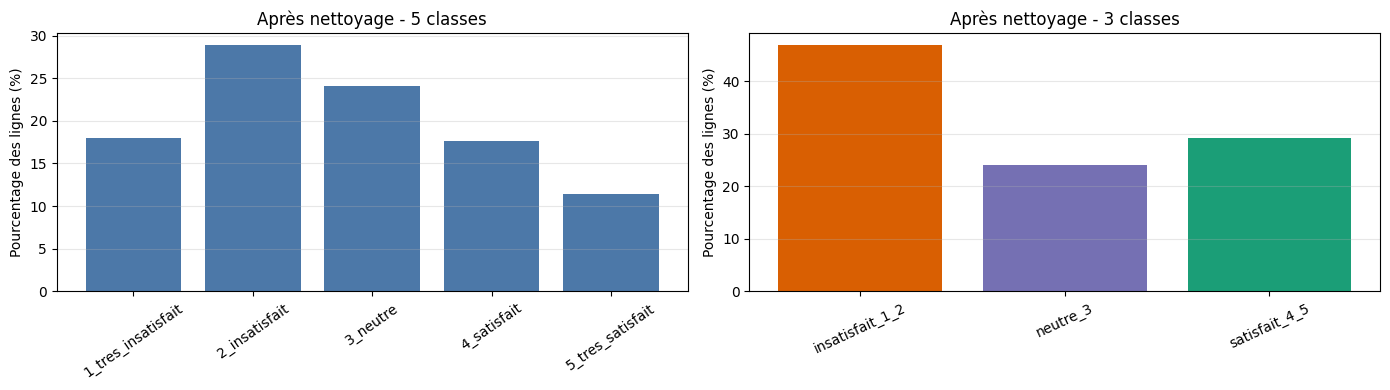

Conclusion sur l'équilibre des classes après nettoyage


,point,conclusion
0,Classe majoritaire,La classe la plus représentée après regroupeme...
1,Classe minoritaire,La classe la moins représentée est neutre_3 (2...
2,Niveau d'équilibre,L'écart entre classe majoritaire et minoritair...
3,Impact sur la modélisation,Le modèle doit être évalué avec macro_f1 et ba...
4,Décision méthodologique,La suite du notebook utilise une séparation tr...


In [21]:
def satisfaction_3_classes_apres_nettoyage(value: int) -> int:
    if value <= 2:
        return 0
    if value == 3:
        return 1
    return 2

libelles_5_classes_apres_nettoyage = {
    1: "1_tres_insatisfait",
    2: "2_insatisfait",
    3: "3_neutre",
    4: "4_satisfait",
    5: "5_tres_satisfait",
}

libelles_3_classes_apres_nettoyage = {
    0: "insatisfait_1_2",
    1: "neutre_3",
    2: "satisfait_4_5",
}


def calculer_distribution_apres_nettoyage(y: pd.Series, libelles: dict[int, str], cible: str) -> pd.DataFrame:
    distribution = (
        y.value_counts()
        .sort_index()
        .rename_axis("classe")
        .reset_index(name="nombre")
    )
    distribution["libelle"] = distribution["classe"].map(libelles)
    distribution["pourcentage"] = (
        distribution["nombre"] / distribution["nombre"].sum() * 100
    ).round(2)
    distribution["cible"] = cible
    return distribution[["cible", "classe", "libelle", "nombre", "pourcentage"]]


distribution_nettoyage_5_classes = calculer_distribution_apres_nettoyage(
    df_model[TARGET_COLUMN].astype(int),
    libelles_5_classes_apres_nettoyage,
    "satisfaction_client_5_classes_apres_nettoyage",
)

distribution_nettoyage_3_classes = calculer_distribution_apres_nettoyage(
    df_model[TARGET_COLUMN].astype(int).apply(satisfaction_3_classes_apres_nettoyage),
    libelles_3_classes_apres_nettoyage,
    "satisfaction_client_3_classes_apres_nettoyage",
)

print("Équilibre des classes après nettoyage")
display(distribution_nettoyage_5_classes)
display(distribution_nettoyage_3_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(
    distribution_nettoyage_5_classes["libelle"],
    distribution_nettoyage_5_classes["pourcentage"],
    color="#4c78a8",
)
axes[0].set_title("Après nettoyage - 5 classes")
axes[0].set_ylabel("Pourcentage des lignes (%)")
axes[0].tick_params(axis="x", rotation=35)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(
    distribution_nettoyage_3_classes["libelle"],
    distribution_nettoyage_3_classes["pourcentage"],
    color=["#d95f02", "#7570b3", "#1b9e77"],
)
axes[1].set_title("Après nettoyage - 3 classes")
axes[1].set_ylabel("Pourcentage des lignes (%)")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

classe_majoritaire_3 = distribution_nettoyage_3_classes.sort_values(
    "pourcentage", ascending=False
).iloc[0]
classe_minoritaire_3 = distribution_nettoyage_3_classes.sort_values(
    "pourcentage", ascending=True
).iloc[0]
ecart_classes_3 = round(
    classe_majoritaire_3["pourcentage"] - classe_minoritaire_3["pourcentage"], 2
)

if ecart_classes_3 >= 20:
    niveau_desequilibre = "déséquilibre important"
elif ecart_classes_3 >= 10:
    niveau_desequilibre = "déséquilibre modéré"
else:
    niveau_desequilibre = "équilibre acceptable"

conclusion_equilibre_apres_nettoyage = pd.DataFrame([
    {
        "point": "Classe majoritaire",
        "conclusion": (
            f"La classe la plus représentée après regroupement est "
            f"{classe_majoritaire_3['libelle']} "
            f"({classe_majoritaire_3['pourcentage']:.2f} %)."
        ),
    },
    {
        "point": "Classe minoritaire",
        "conclusion": (
            f"La classe la moins représentée est "
            f"{classe_minoritaire_3['libelle']} "
            f"({classe_minoritaire_3['pourcentage']:.2f} %)."
        ),
    },
    {
        "point": "Niveau d'équilibre",
        "conclusion": (
            f"L'écart entre classe majoritaire et minoritaire est de "
            f"{ecart_classes_3:.2f} points : {niveau_desequilibre}."
        ),
    },
    {
        "point": "Impact sur la modélisation",
        "conclusion": (
            "Le modèle doit être évalué avec macro_f1 et balanced_accuracy, "
            "car l'accuracy seule peut masquer une mauvaise performance sur les classes moins représentées."
        ),
    },
    {
        "point": "Décision méthodologique",
        "conclusion": (
            "La suite du notebook utilise une séparation train/test stratifiée "
            "et des diagnostics par classe pour conserver une évaluation fiable."
        ),
    },
])

print("Conclusion sur l'équilibre des classes après nettoyage")
display(conclusion_equilibre_apres_nettoyage)


#### Interprétation des résultats après nettoyage

Après nettoyage métier, le dataset contient `1399` séjours exploitables. Le regroupement en 3 classes montre une classe majoritaire `insatisfait_1_2` d'environ `46.82 %`, contre `24.09 %` pour `neutre_3` et `29.09 %` pour `satisfait_4_5`.

La cible est donc déséquilibrée. Pour éviter une lecture trop favorable de l'`accuracy`, l'évaluation du modèle repose principalement sur `macro_f1`, `balanced_accuracy`, le split stratifié et la matrice de confusion.


## 8. Feature engineering


#### Pertinence métier des variables préparées

Les variables créées dans le feature engineering servent à transformer les colonnes brutes en indicateurs plus directement exploitables par le modèle et plus lisibles pour le métier.

- Les variables pré-voyage dérivées sont utilisables avant le départ et peuvent donc entrer dans le modèle industrialisé : `budget_par_jour`, `part_vol_budget`, `sejour_long`, `meteo_risque`, `client_business` et `hebergement_luxe`.
- `budget_par_jour` mesure le niveau de confort budgétaire quotidien du séjour.
- `part_vol_budget` mesure le poids du transport dans le budget total et permet d'identifier un budget potentiellement tendu.
- `sejour_long` distingue les séjours longs, qui peuvent impliquer plus de complexité logistique.
- `meteo_risque` identifie les séjours exposés à une météo défavorable ou variable.
- `client_business` isole les voyages professionnels, dont les attentes peuvent différer des voyages loisirs.
- `hebergement_luxe` repère les hébergements de type `resort` ou `villa`, associés à un niveau d'attente plus élevé.
- Les variables post-voyage explicatives sont créées uniquement pour l'analyse post-voyage : `imprevu_present`, `imprevu_transport` et `imprevu_meteo`.
- Les variables post-voyage brutes `imprevus`, `reorganisation_necessaire` et `respect_budget` sont conservées pour le modèle post-voyage, mais exclues du modèle pré-voyage pour éviter la fuite de données.
- Le dataset final `df_model` reste contrôlé avant la séparation train/test : dimensions, exemples de variables créées, valeurs manquantes et équilibre des classes.


In [22]:
def ajouter_features_base(df_source: pd.DataFrame) -> pd.DataFrame:
    df = df_source.copy()

    safe_duree = df["duree_jours"].replace(0, np.nan)
    safe_budget = df["budget_total"].replace(0, np.nan)

    def indicateur(condition: pd.Series, missing_mask: pd.Series) -> pd.Series:
        return pd.Series(
            np.where(missing_mask, np.nan, condition.astype(int)),
            index=df.index,
        )

    df["budget_par_jour"] = df["budget_total"] / safe_duree
    df["part_vol_budget"] = df["prix_vol"] / safe_budget
    df["sejour_long"] = indicateur(df["duree_jours"] >= 14, df["duree_jours"].isna())
    df["meteo_risque"] = indicateur(
        df["meteo_prevue"].isin(["pluie", "variable"]),
        df["meteo_prevue"].isna(),
    )
    df["client_business"] = indicateur(
        df["client_type"] == "business",
        df["client_type"].isna(),
    )
    df["hebergement_luxe"] = indicateur(
        df["type_hebergement"].isin(["resort", "villa"]),
        df["type_hebergement"].isna(),
    )


    # Variables post-voyage explicatives : utilisées uniquement dans le modele post-voyage.
    df["imprevu_present"] = indicateur(df["imprevus"] != "aucun", df["imprevus"].isna())
    df["imprevu_transport"] = indicateur(
        df["imprevus"].isin(["retard_vol", "annulation", "bagages"]),
        df["imprevus"].isna(),
    )
    df["imprevu_meteo"] = indicateur(
        df["imprevus"].isin(["météo", "meteo", "météo"]),
        df["imprevus"].isna(),
    )

    for column in ["budget_par_jour", "part_vol_budget"]:
        df[column] = df[column].replace([np.inf, -np.inf], np.nan)

    for column in df.select_dtypes(include=["object", "string"]).columns:
        df[column] = df[column].mask(df[column].isna(), np.nan).astype(object)

    return df


df_model = ajouter_features_base(df_model)

features_base = [
    "budget_par_jour",
    "part_vol_budget",
    "sejour_long",
    "meteo_risque",
    "client_business",
    "hebergement_luxe",
]

features_post_voyage_explicatives = [
    "imprevus",
    "reorganisation_necessaire",
    "respect_budget",
    "imprevu_present",
    "imprevu_transport",
    "imprevu_meteo",
]
print("Dimensions apres feature engineering :", df_model.shape)
display(df_model[features_base + [TARGET_COLUMN]].head())
print(f"Valeurs manquantes avant pipeline : {int(df_model.isna().sum().sum())}")

Dimensions apres feature engineering : (1399, 24)


,budget_par_jour,part_vol_budget,sejour_long,meteo_risque,client_business,hebergement_luxe,satisfaction_client
0,1849.633333,0.238024,0.0,0.0,0.0,0.0,3
1,274.022500,0.463493,0.0,1.0,1.0,0.0,4
2,834.198750,0.066077,1.0,0.0,0.0,1.0,5
3,414.671765,0.119781,1.0,0.0,0.0,0.0,3
4,1087.560000,0.142027,0.0,1.0,0.0,0.0,2


Valeurs manquantes avant pipeline : 381



### 8.1 Liste de features

#### Variables pré-voyage brutes

- `client_type`
- `budget_total`
- `destination`
- `saison`
- `duree_jours`
- `type_hebergement`
- `prix_vol`
- `meteo_prevue`
- `activite_principale`

#### Variables pré-voyage dérivées conservées

- `budget_par_jour`
- `part_vol_budget`
- `sejour_long`
- `meteo_risque`
- `client_business`
- `hebergement_luxe`

#### Variables post-voyage conservées uniquement pour le modèle post-voyage

- `imprevus`
- `reorganisation_necessaire`
- `respect_budget`
- `imprevu_present`
- `imprevu_transport`
- `imprevu_meteo`

### 8.2 Vérification courte de la cible après feature engineering

Le feature engineering ajoute des variables explicatives dans `df_model`, mais ne modifie pas la cible `satisfaction_client`. Cette vérification sert uniquement à confirmer que la distribution des classes reste identique à celle observée après nettoyage.


In [23]:
# Fonction commune utilisée ensuite par les modèles pré-voyage et post-voyage.
# Elle transforme la note de satisfaction 1-5 en cible 3 classes.
def regrouper_satisfaction_3_classes(value: int) -> int:
    if value <= 2:
        return 0
    if value == 3:
        return 1
    return 2

libelles_satisfaction_3 = {
    0: "insatisfait_1_2",
    1: "neutre_3",
    2: "satisfait_4_5",
}

def distribution_classes(y: pd.Series, libelles: dict[int, str], nom_cible: str) -> pd.DataFrame:
    distribution = (
        y.value_counts()
        .sort_index()
        .rename_axis("classe")
        .reset_index(name="nombre")
    )
    distribution["libelle"] = distribution["classe"].map(libelles)
    distribution["pourcentage"] = (
        distribution["nombre"] / distribution["nombre"].sum() * 100
    ).round(2)
    distribution["cible"] = nom_cible
    return distribution[["cible", "classe", "libelle", "nombre", "pourcentage"]]

distribution_satisfaction_3 = distribution_classes(
    df_model[TARGET_COLUMN].astype(int).apply(regrouper_satisfaction_3_classes),
    libelles_satisfaction_3,
    "satisfaction_client_3_classes_dataset_final",
)

controle_equilibre_final = distribution_satisfaction_3.copy()

print("Vérification courte de la cible sur le dataset final df_model")
display(controle_equilibre_final)


Vérification courte de la cible sur le dataset final df_model


,cible,classe,libelle,nombre,pourcentage
0,satisfaction_client_3_classes_dataset_final,0,insatisfait_1_2,655,46.82
1,satisfaction_client_3_classes_dataset_final,1,neutre_3,337,24.09
2,satisfaction_client_3_classes_dataset_final,2,satisfait_4_5,407,29.09


#### Interprétation synthétique

La distribution de la cible reste identique à celle observée après le nettoyage : le feature engineering n'a pas créé, supprimé ou modifié de classe de satisfaction.

Le dataset final conserve donc le même déséquilibre de classes, avec une classe `insatisfait_1_2` majoritaire. Cette vérification confirme que la suite du notebook doit conserver le split stratifié, `macro_f1`, `balanced_accuracy` et la matrice de confusion pour évaluer correctement les modèles.


### 8.3 Stockage, cycle de vie et gouvernance du dataset

Cette section synthétise comment les données TravelMind sont stockées, versionnées et encadrées. L'objectif est d'assurer la traçabilité du dataset sans répéter les traitements déjà détaillés dans les sections précédentes.

#### Stockage retenu

| Objet | Emplacement | Rôle |
| --- | --- | --- |
| Dataset brut | `data/Examen_travel_planning_dataset.csv` | Source initiale du projet |
| Versions de données | `data/versions/` | Historiser les étapes majeures de transformation |
| Dataset de travail | `df_model` dans le notebook | Dataset reconstruit après nettoyage et feature engineering |
| Pipelines ML | Objets `Pipeline` / `ColumnTransformer` | Appliquer imputation, outliers, encodage et standardisation sans fuite train/test |
| Artefacts modèle | `models/` | Modèle pré-voyage exporté par `train.py`, non versionné dans Git |
| Logs et monitoring | `logs/predictions/` | Suivre les prédictions API, la confiance et les dérives, non versionné dans Git |

Le CSV local est adapté au prototype. En production avec données clients réelles, il faudrait passer à un stockage contrôlé : base de données ou object storage, gestion des accès, sauvegardes, registre des versions et validation RGPD.

#### Cycle de vie et versioning des données

| Phase | Version / objet | Emplacement | Finalité |
| --- | --- | --- | --- |
| Données brutes | `v1.0` | `data/versions/v1_0_raw/travel_planning_dataset_v1_0.csv` | Conserver la source fournie sans transformation |
| Nettoyage des formats | `v1.1` | `data/versions/v1_1_cleaning/travel_planning_dataset_v1_1.csv` | Harmoniser textes, espaces, casse et formats numériques |
| Nettoyage des incohérences critiques | `v1.2` | `data/versions/v1_2_incoherences/travel_planning_dataset_v1_2.csv` | Retirer les lignes incompatibles avec l'apprentissage supervisé |
| Feature engineering | `v2.0` / `df_model` | `data/versions/v2_0_feature_engineering/travel_planning_dataset_v2_0.csv` | Ajouter les variables retenues pour les cas pré-voyage et post-voyage |
| Modélisation | `X_pre`, `X_post`, `y_pre`, `y_post` | Notebook final | Séparer les variables selon le moment d'utilisation pour éviter la fuite de données |
| Industrialisation | `train.py`, API, dashboard | `models/`, `app/`, `logs/` | Exporter et servir le modèle pré-voyage avec monitoring |

Le script `scripts/version_data.py` regénère les versions. Le manifeste `data/versions/manifest.json` trace les lignes, colonnes, transformations et empreintes SHA-256. Le détail est documenté dans `docs/data_versioning.md`.

#### Règles de gouvernance

- Les données préparées doivent rester reproductibles depuis le CSV brut.
- Les variables post-voyage sont exclues du modèle pré-voyage pour éviter la fuite de données.
- Les artefacts lourds, logs, runs MLflow et modèles exportés restent hors Git.
- Toute future donnée réelle devra faire l'objet d'une validation RGPD, d'une politique d'accès, d'une durée de conservation et d'une revue juridique.

#### Conclusion

La gouvernance actuelle est suffisante pour ce projet : données locales, cycle de vie versionné, transformations reproductibles et modèle pré-voyage exportable. Un passage en production demanderait surtout un stockage sécurisé, une gouvernance RGPD renforcée et une validation par les parties prenantes.


### 8.4 Segmentation client par clustering pré-voyage

Le clustering est une analyse exploratoire non supervisée. Il sert à regrouper des séjours similaires à partir des informations connues avant le départ, sans utiliser la cible `satisfaction_client`.

#### Lien avec l'ambition métier

Cette partie répond principalement à l'axe de recommandations personnalisées : mieux comprendre les profils de voyageurs pour adapter les destinations, hébergements et activités proposés. Elle contribue aussi à l'amélioration continue, car les segments peuvent ensuite être comparés avec la satisfaction et les incidents observés après voyage.

Nombre de clusters retenu : 2
Scores de silhouette testés :


,k,silhouette
0,2,0.1496
1,3,0.1419
2,4,0.1286
3,5,0.1214
4,6,0.1169


Profil synthétique des segments clients :


,segment_client,libelle_segment_metier,nb_sejours,part_lignes_pct,client_type_majoritaire,destination_majoritaire,saison_majoritaire,hebergement_majoritaire,activite_majoritaire,budget_moyen,duree_moyenne,prix_vol_moyen,part_vol_budget_moyenne
0,0,profil_sejour_long,390,27.88,senior,new york,automne,appartement,plage,9696.113,16.756,1114.392,0.149
1,1,profil_business,1009,72.12,business,new york,été,villa,culture,6547.667,8.080,1114.926,0.239


Exemples de séjours par segment :


,segment_client,trip_id,client_type,destination,saison,duree_jours,type_hebergement,budget_total,prix_vol,activite_principale
0,0,878,famille,bali,printemps,14,hôtel,500.00,50.0,plage
1,0,895,solo,bali,automne,15,hôtel,500.00,NaN,business
2,0,835,famille,new york,été,14,appartement,1265.55,1009.5,culture
3,1,884,couple,bali,été,13,villa,500.00,35.0,plage
4,1,1454,senior,tokyo,automne,4,hôtel,500.00,NaN,culture
5,1,39,senior,lisbonne,été,6,appartement,853.14,577.9,randonnée


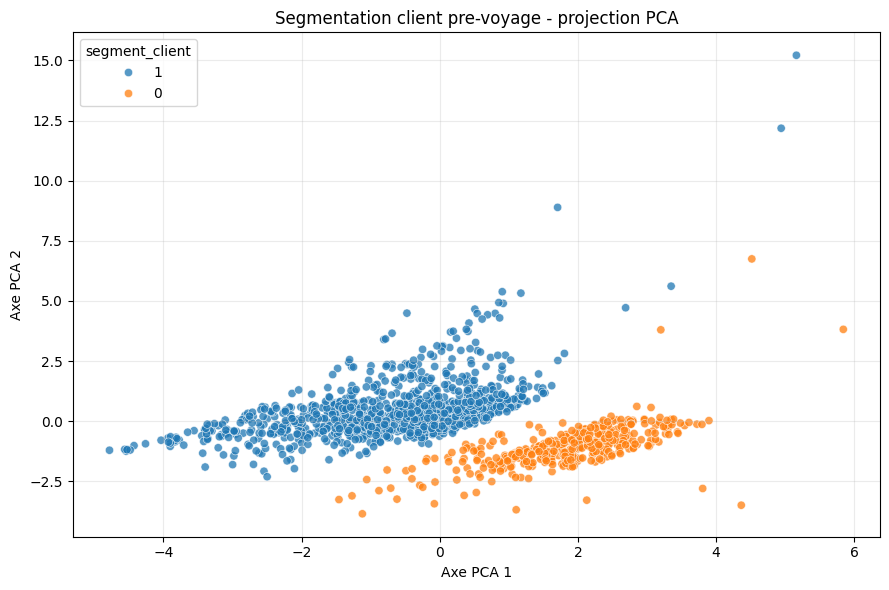

In [24]:
# Variables pre-voyage uniquement : connues avant la réalisation du séjour.
features_clustering_pre_voyage = [
    "client_type",
    "budget_total",
    "destination",
    "saison",
    "duree_jours",
    "type_hebergement",
    "prix_vol",
    "meteo_prevue",
    "activite_principale",
    "budget_par_jour",
    "part_vol_budget",
    "sejour_long",
    "meteo_risque",
    "client_business",
    "hebergement_luxe",
]
features_clustering_pre_voyage = [
    col for col in features_clustering_pre_voyage if col in df_model.columns
]

X_clustering = df_model[features_clustering_pre_voyage].copy()

colonnes_numeriques_clustering = X_clustering.select_dtypes(include=[np.number]).columns.tolist()
colonnes_categorielles_clustering = [
    col for col in X_clustering.columns if col not in colonnes_numeriques_clustering
]

preprocesseur_clustering = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            colonnes_numeriques_clustering,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]),
            colonnes_categorielles_clustering,
        ),
    ],
    remainder="drop",
    sparse_threshold=0,
)

X_clustering_prepare = preprocesseur_clustering.fit_transform(X_clustering)
X_clustering_prepare = np.asarray(X_clustering_prepare, dtype=float)

# Choix exploratoire du nombre de clusters avec le score de silhouette.
scores_silhouette = []
for k in range(2, 7):
    modele_kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = modele_kmeans.fit_predict(X_clustering_prepare)
    scores_silhouette.append({
        "k": k,
        "silhouette": silhouette_score(X_clustering_prepare, labels),
    })

silhouette_clustering = pd.DataFrame(scores_silhouette)
k_retenu = int(
    silhouette_clustering.sort_values("silhouette", ascending=False).iloc[0]["k"]
)

modele_segmentation_client = KMeans(
    n_clusters=k_retenu,
    random_state=RANDOM_STATE,
    n_init=10,
)
segments_client = modele_segmentation_client.fit_predict(X_clustering_prepare)

df_segments = df_model.copy()
df_segments["segment_client"] = segments_client.astype(int)

count_column = "trip_id" if "trip_id" in df_segments.columns else "budget_total"
aggregations_segments = {
    "nb_sejours": (count_column, "count"),
    "budget_moyen": ("budget_total", "mean"),
    "duree_moyenne": ("duree_jours", "mean"),
    "prix_vol_moyen": ("prix_vol", "mean"),
    "part_vol_budget_moyenne": ("part_vol_budget", "mean"),
}

# Variables post-voyage utilisées uniquement pour lire les segments aprés création.
if TARGET_COLUMN in df_segments.columns:
    aggregations_segments["satisfaction_moyenne"] = (TARGET_COLUMN, "mean")
if "respect_budget" in df_segments.columns:
    aggregations_segments["taux_budget_respecte"] = ("respect_budget", "mean")
if "reorganisation_necessaire" in df_segments.columns:
    aggregations_segments["taux_reorganisation"] = ("reorganisation_necessaire", "mean")

profil_segments = (
    df_segments
    .groupby("segment_client")
    .agg(**aggregations_segments)
    .reset_index()
)
profil_segments["part_lignes_pct"] = (
    profil_segments["nb_sejours"] / len(df_segments) * 100
).round(2)

def mode_safe(series: pd.Series):
    values = series.dropna()
    if values.empty:
        return "non_disponible"
    return values.mode().iloc[0]

variables_categorielles_description = [
    "client_type",
    "destination",
    "saison",
    "type_hebergement",
    "activite_principale",
]
variables_categorielles_description = [
    col for col in variables_categorielles_description if col in df_segments.columns
]

profil_categoriel_segments = (
    df_segments
    .groupby("segment_client")[variables_categorielles_description]
    .agg(mode_safe)
    .reset_index()
)
profil_categoriel_segments = profil_categoriel_segments.rename(columns={
    "client_type": "client_type_majoritaire",
    "destination": "destination_majoritaire",
    "saison": "saison_majoritaire",
    "type_hebergement": "hebergement_majoritaire",
    "activite_principale": "activite_majoritaire",
})

profil_segments = profil_segments.merge(
    profil_categoriel_segments,
    on="segment_client",
    how="left",
)

def proposer_libelle_segment(row: pd.Series) -> str:
    if row.get("client_type_majoritaire") == "business":
        return "profil_business"
    if row.get("hebergement_majoritaire") in ["resort", "villa"]:
        return "profil_premium_loisir"
    if row.get("duree_moyenne", 0) >= df_segments["duree_jours"].median():
        return "profil_sejour_long"
    return "profil_standard"

profil_segments["libelle_segment_metier"] = profil_segments.apply(
    proposer_libelle_segment,
    axis=1,
)

print(f"Nombre de clusters retenu : {k_retenu}")
print("Scores de silhouette testés :")
display(silhouette_clustering.round(4))

colonnes_resume_segments = [
    "segment_client",
    "libelle_segment_metier",
    "nb_sejours",
    "part_lignes_pct",
    "client_type_majoritaire",
    "destination_majoritaire",
    "saison_majoritaire",
    "hebergement_majoritaire",
    "activite_majoritaire",
    "budget_moyen",
    "duree_moyenne",
    "prix_vol_moyen",
    "part_vol_budget_moyenne",
]
colonnes_resume_segments = [
    col for col in colonnes_resume_segments if col in profil_segments.columns
]

resume_segments_client = (
    profil_segments[colonnes_resume_segments]
    .sort_values("segment_client")
    .reset_index(drop=True)
)

print("Profil synthétique des segments clients :")
display(resume_segments_client.round(3))

colonnes_exemples_segments = [
    "segment_client",
    "trip_id",
    "client_type",
    "destination",
    "saison",
    "duree_jours",
    "type_hebergement",
    "budget_total",
    "prix_vol",
    "activite_principale",
]
colonnes_exemples_segments = [
    col for col in colonnes_exemples_segments if col in df_segments.columns
]

exemples_segments_client = (
    df_segments
    .sort_values(["segment_client", "budget_total"])
    .groupby("segment_client", group_keys=False)
    .head(3)[colonnes_exemples_segments]
    .reset_index(drop=True)
)

print("Exemples de séjours par segment :")
display(exemples_segments_client)

# Projection 2D pour visualiser les segments.
pca_segments = PCA(n_components=2, random_state=RANDOM_STATE)
projection_segments = pca_segments.fit_transform(X_clustering_prepare)
projection_segments = pd.DataFrame({
    "axe_1": projection_segments[:, 0],
    "axe_2": projection_segments[:, 1],
    "segment_client": df_segments["segment_client"].astype(str),
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=projection_segments,
    x="axe_1",
    y="axe_2",
    hue="segment_client",
    palette="tab10",
    alpha=0.75,
)
plt.title("Segmentation client pre-voyage - projection PCA")
plt.xlabel("Axe PCA 1")
plt.ylabel("Axe PCA 2")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### Interprétation technique de la segmentation

La segmentation utilise `KMeans`. Avant l'entraînement, les variables sont préparées selon leur type afin que l'algorithme puisse calculer correctement les distances entre séjours.

- Les variables numériques sont imputées par la médiane, car elle est plus robuste que la moyenne en présence de valeurs extrêmes. Elles sont ensuite standardisées avec `StandardScaler` pour éviter qu'une variable comme `budget_total` domine les distances uniquement parce que ses valeurs sont plus grandes.
- Les variables catégorielles sont imputées par la valeur la plus fréquente, car cela conserve une modalité plausible sans inventer une nouvelle catégorie. Elles sont ensuite encodées avec `OneHotEncoder`.
- `OneHotEncoder` est choisi car les catégories comme `destination`, `saison` ou `type_hebergement` ne sont pas ordinales. Un encodage par nombres simples ferait croire à l'algorithme qu'il existe un ordre ou une distance mathématique entre les modalités, ce qui serait faux.

Le nombre de segments est choisi de manière exploratoire : le notebook teste plusieurs valeurs de `k`, de 2 à 6, puis retient celle qui maximise le score de silhouette. Le nombre final est donc affiché par la variable `k_retenu`.

Chaque segment est ensuite décrit avec des indicateurs moyens (`budget_moyen`, `duree_moyenne`, `prix_vol_moyen`, `part_vol_budget_moyenne`) et des modalités majoritaires (`client_type`, `destination`, `saison`, `type_hebergement`, `activite_principale`). Ces informations permettent de proposer un libellé métier simple.

Les variables post-voyage ne sont pas utilisées pour créer les clusters ; elles servent uniquement à lire les segments après coup. La projection PCA est seulement un support visuel et ne remplace pas l'analyse des tableaux de profils.


#### Interprétation métier de la segmentation

Les segments doivent être lus comme des profils clients exploitables par l'agence, pas comme des décisions automatiques. Ils peuvent servir à personnaliser les recommandations, prioriser l'accompagnement avant départ et produire un reporting métier plus lisible.

Les libellés comme `profil_business`, `profil_premium_loisir`, `profil_sejour_long` ou `profil_standard` sont des interprétations simples des caractéristiques dominantes de chaque segment. Ils doivent être validés par les acteurs métier avant toute utilisation opérationnelle.

Limites : le clustering dépend des variables disponibles, les segments peuvent changer si les données évoluent, et ils ne doivent pas conduire à exclure automatiquement un client d'une offre ou d'un service.

## C4-C5. Modélisation : choix, entraînement et validation

Cette partie regroupe la démarche de modélisation du projet TravelMind. Elle couvre à la fois le choix des familles de modèles, l'entraînement supervisé, la validation et la comparaison des résultats.

Deux objectifs sont distingués :

- le modèle pré-voyage, utilisable avant le départ et retenu pour l'industrialisation ;
- le modèle post-voyage, utilisé comme analyse complémentaire pour comprendre l'apport des variables opérationnelles observées après le séjour.

La démarche repose sur plusieurs principes : split train/test stratifié, pipelines `scikit-learn`, exclusion des variables de fuite, comparaison à une baseline, suivi de `macro_f1`, `balanced_accuracy`, matrice de confusion, validation croisée et diagnostics d'overfitting / underfitting.


In [25]:
class IQRMedianOutlierReplacer(BaseEstimator, TransformerMixin):
    """Remplace les outliers IQR par la mediane apprise sur le train."""

    def __init__(self, factor: float = 1.5):
        # factor=1.5 correspond a la règle IQR classique : Q1 - 1.5*IQR / Q3 + 1.5*IQR.
        self.factor = factor

    def fit(self, X, y=None):
        # Les bornes IQR et la médiane sont apprises uniquement sur le jeu transmis au fit.
        # Dans un Pipeline sklearn, ce fit est appelé uniquement sur le train.
        X_array = np.asarray(X, dtype=float)
        self.q1_ = np.nanquantile(X_array, 0.25, axis=0)
        self.q3_ = np.nanquantile(X_array, 0.75, axis=0)
        self.iqr_ = self.q3_ - self.q1_
        self.lower_bounds_ = self.q1_ - self.factor * self.iqr_
        self.upper_bounds_ = self.q3_ + self.factor * self.iqr_
        self.medians_ = np.nanmedian(X_array, axis=0)
        return self

    def transform(self, X):
        # Les valeurs hors bornes sont remplacées par la médiane apprise au fit.
        X_array = np.asarray(X, dtype=float).copy()
        outlier_mask = (
            (X_array < self.lower_bounds_)
            | (X_array > self.upper_bounds_)
        )
        return np.where(outlier_mask, self.medians_, X_array)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.asarray([f"x{i}" for i in range(len(self.medians_))], dtype=object)
        return np.asarray(input_features, dtype=object)


# Certaines colonnes exploratoires peuvent contenir des listes ou dictionnaires.
# Ces valeurs ne sont pas compatibles avec les opérations d'encodage ou de groupby.
def est_hashable(valeur) -> bool:
    try:
        hash(valeur)
        return True
    except TypeError:
        return False


def contient_valeur_non_hashable(serie: pd.Series) -> bool:
    valeurs = serie.dropna().head(1000)
    return valeurs.map(lambda valeur: not est_hashable(valeur)).any()


def detecter_variables_binaires(X: pd.DataFrame, numeric_features: list[str]) -> list[str]:
    # Les variables binaires 0/1 ne sont pas standardisees comme des variables continues.
    binary_features = []
    for column in numeric_features:
        if contient_valeur_non_hashable(X[column]):
            continue
        try:
            values = pd.Series(X[column].dropna().unique())
            unique_values = set(values.astype(float).tolist())
        except (TypeError, ValueError):
            continue
        if values.empty:
            continue
        if unique_values.issubset({0.0, 1.0}):
            binary_features.append(column)
    return binary_features


def construire_preprocesseur(X: pd.DataFrame) -> tuple[ColumnTransformer, list[str], list[str]]:
    # 1. Exclure les colonnes non compatibles avec sklearn si elles existent.
    non_hashable_features = [
        column for column in X.columns
        if contient_valeur_non_hashable(X[column])
    ]
    if non_hashable_features:
        print("Colonnes ignorees par le preprocesseur car elles contiennent des listes/dictionnaires :", non_hashable_features)

    X_compatible = X.drop(columns=non_hashable_features, errors="ignore")

    # 2. Séparer les variables numeriques et categorielles pour appliquer les bons traitements.
    numeric_features = X_compatible.select_dtypes(include="number").columns.tolist()
    categorical_features = X_compatible.select_dtypes(include=["object", "string", "category"]).columns.tolist()

    # 3. Distinguer numériques continues et indicateurs binaires.
    binary_numeric_features = detecter_variables_binaires(X_compatible, numeric_features)
    continuous_numeric_features = [
        column for column in numeric_features
        if column not in binary_numeric_features
    ]

    # 4. Numériques continues : mediane -> IQR -> standardisation.
    continuous_numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("outliers_iqr", IQRMedianOutlierReplacer()),
        ("scaler", StandardScaler()),
    ])

    # 5. Numériques binaires : imputation simple, pas de standardisation.
    binary_numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ])

    # 6. Catégorielles : modalité la plus frequente puis OneHotEncoder.
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    transformers = []
    if continuous_numeric_features:
        transformers.append(("num_cont", continuous_numeric_transformer, continuous_numeric_features))
    if binary_numeric_features:
        transformers.append(("num_bin", binary_numeric_transformer, binary_numeric_features))
    if categorical_features:
        transformers.append(("cat", categorical_transformer, categorical_features))

    preprocess = ColumnTransformer(transformers=transformers)

    return preprocess, numeric_features, categorical_features


def evaluer_classification(modeles: dict, X_train, X_test, y_train, y_test, preprocess) -> tuple[pd.DataFrame, dict]:
    # Cette fonction entraine chaque modèle avec le même pipeline de préparation,
    # puis compare les performances sur le même jeu de test.
    rows = []
    fitted = {}

    for model_name, model in modeles.items():
        # clone() évite qu'un modele ou preprocesseur ajuste contamine l'expérience suivante.
        pipeline = Pipeline(steps=[
            ("preprocess", clone(preprocess)),
            ("model", clone(model)),
        ])
        pipeline.fit(X_train, y_train)
        predictions = pipeline.predict(X_test)

        rows.append({
            "modele": model_name,
            "accuracy": accuracy_score(y_test, predictions),
            "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
            "macro_f1": f1_score(y_test, predictions, average="macro"),
        })
        fitted[model_name] = pipeline

    # Le macro_f1 est prioritaire car il donne le même poids à chaque classe.
    results = (
        pd.DataFrame(rows)
        .sort_values("macro_f1", ascending=False)
        .reset_index(drop=True)
    )

    return results, fitted


def afficher_distribution(y: pd.Series, label: str) -> None:
    # Contrôle rapide de l'équilibre des classes avant ou après split.
    print(label)
    display(
        y.value_counts()
        .sort_index()
        .rename_axis("classe")
        .reset_index(name="nombre")
        .assign(pourcentage=lambda data: (data["nombre"] / data["nombre"].sum() * 100).round(2))
    )

### C4-C5.0 Pipeline de préparation utilisé pour la modélisation

Le pipeline applique les traitements apprenant des paramètres après la séparation train/test afin d'éviter la fuite de données.

```text
Données nettoyées df_model
-> définition de X et y selon l'objectif pré-voyage ou post-voyage
-> split train/test stratifié
-> imputation apprise uniquement sur le train
-> traitement IQR des outliers appris uniquement sur le train
-> encodage OneHotEncoder appris uniquement sur le train
-> standardisation apprise uniquement sur le train
-> entraînement du modèle sur train
-> prédiction et évaluation sur test non vu
```

Cette organisation garantit que le jeu de test reste non vu jusqu'à l'évaluation finale.


### C4-C5.1 Modèle pré-voyage

Objectif : prédire la satisfaction avant le départ à partir des informations disponibles au moment de la planification.

La cible est regroupée en 3 classes pour rendre le problème plus exploitable métier :

- `0 = insatisfait` pour les notes 1 et 2 ;
- `1 = neutre ou mitigé` pour la note 3 ;
- `2 = satisfait` pour les notes 4 et 5.

In [26]:
# Colonnes connues uniquement pendant ou après le voyage.
# Elles sont exclues du modele pre-voyage pour éviter la fuite de donnees.
post_trip_columns = [
    "imprevus",
    "reorganisation_necessaire",
    "respect_budget",
    "retour_client",
    "imprevu_present",
    "imprevu_transport",
    "imprevu_meteo",
]

# Colonnes techniques sans signal métier direct.
technical_columns = ["trip_id"]

# Selection des variables autorisées avant depart.
excluded_pre_voyage = [TARGET_COLUMN, *technical_columns, *post_trip_columns]
feature_columns_pre = [
    column for column in df_model.columns
    if column not in excluded_pre_voyage
]

def est_hashable(valeur) -> bool:
    try:
        hash(valeur)
        return True
    except TypeError:
        return False


def contient_valeur_non_hashable(serie: pd.Series) -> bool:
    valeurs = serie.dropna().head(1000)
    return valeurs.map(lambda valeur: not est_hashable(valeur)).any()


colonnes_non_hashables_pre = [
    column for column in feature_columns_pre
    if contient_valeur_non_hashable(df_model[column])
]

if colonnes_non_hashables_pre:
    print("Colonnes exclues car non compatibles avec l'encodage :", colonnes_non_hashables_pre)

feature_columns_pre = [
    column for column in feature_columns_pre
    if column not in colonnes_non_hashables_pre
]

# X_pre contient uniquement les informations disponibles avant le départ.
X_pre = df_model[feature_columns_pre].copy()

# y_pre est la satisfaction regroupée en 3 classes.
y_pre = df_model[TARGET_COLUMN].apply(regrouper_satisfaction_3_classes).astype(int).copy()

# Le preprocesseur est defini ici, mais ses paramètres seront appris lors du fit sur le train.
preprocess_pre, numeric_pre, categorical_pre = construire_preprocesseur(X_pre)

resume_pre = pd.DataFrame({
    "famille": ["numeriques", "categorielles", "total", "exclues"],
    "nombre": [len(numeric_pre), len(categorical_pre), X_pre.shape[1], len(excluded_pre_voyage)],
    "colonnes": [numeric_pre, categorical_pre, feature_columns_pre, excluded_pre_voyage],
})

# Résume des colonnes utilisées et exclues pour vérifier le perimètre pre-voyage.
display(resume_pre)
afficher_distribution(y_pre, "Distribution cible pre-voyage a 3 classes")

,famille,nombre,colonnes
0,numeriques,9,"[budget_total, duree_jours, prix_vol, budget_p..."
1,categorielles,6,"[client_type, destination, saison, type_heberg..."
2,total,15,"[client_type, budget_total, destination, saiso..."
3,exclues,9,"[satisfaction_client, trip_id, imprevus, reorg..."


Distribution cible pre-voyage a 3 classes


,classe,nombre,pourcentage
0,0,655,46.82
1,1,337,24.09
2,2,407,29.09


#### Interprétation de la distribution pré-voyage

La cible pré-voyage contient `1399` séjours répartis en 3 classes : `655` séjours `insatisfait_1_2` (`46.82 %`), `337` séjours `neutre_3` (`24.09 %`) et `407` séjours `satisfait_4_5` (`29.09 %`).

La classe `insatisfait_1_2` est donc majoritaire. Ce déséquilibre peut pousser un modèle à favoriser cette classe si l'évaluation repose uniquement sur l'`accuracy`. C'est pourquoi la suite utilise un split stratifié, `macro_f1`, `balanced_accuracy` et la matrice de confusion.

Cette distribution confirme aussi que le pré-voyage est un cas difficile : le modèle doit distinguer trois niveaux de satisfaction alors que la classe neutre est moins représentée et que les variables disponibles avant le départ portent peu de signal direct sur l'expérience finale.


### C4-C5.2 Corrélations pré-voyage

Cette cellule mesure le lien entre les variables numériques connues avant le départ et la cible `satisfaction_client` regroupée en 3 classes.

La corrélation de Spearman est utilisée car elle mesure une relation monotone sans supposer une relation linéaire parfaite. Elle est calculée uniquement sur le jeu d'entraînement.

L'objectif n'est pas de choisir le modèle à partir de cette seule analyse, mais de vérifier si les variables pré-voyage contiennent un signal exploitable avant la comparaison des modèles.

La heatmap ajoutée après le tableau permet de visualiser rapidement l'intensité et le sens des corrélations entre les variables numériques pré-voyage et la cible.


In [27]:
# Split stratifié : conserve la proportion des 3 classes dans train et test.
# Il est fait avant toute opération apprenant des paramètres.
X_train_pre, X_test_pre, y_train_pre, y_test_pre = train_test_split(
    X_pre,
    y_pre,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_pre,
)

# Analyse simple du lien monotone entre variables numériques pre-voyage et cible.
# Elle est calculée uniquement sur le train pour ne pas utiliser le test dans l'analyse.
correlation_df_pre = X_train_pre[numeric_pre].copy()
correlation_df_pre["satisfaction_3_classes"] = y_train_pre.values

spearman_pre = (
    correlation_df_pre.corr(method="spearman")["satisfaction_3_classes"]
    .drop("satisfaction_3_classes")
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

display(spearman_pre.to_frame("correlation_spearman_satisfaction_3_classes").round(4).head(15))

# Visualisation : heatmap de la matrice de corrélation Spearman.
# Les variables sont ordonnées selon leur lien absolu avec la satisfaction.
variables_heatmap_pre = [
    *spearman_pre.abs().sort_values(ascending=False).index.tolist(),
    "satisfaction_3_classes",
]

correlation_heatmap_pre = correlation_df_pre[variables_heatmap_pre].corr(method="spearman")

plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation_heatmap_pre,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Heatmap des corrélations Spearman — pré-voyage")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


,correlation_spearman_satisfaction_3_classes
part_vol_budget,-0.0643
budget_total,0.0632
budget_par_jour,0.0597
hebergement_luxe,0.0476
sejour_long,-0.0276
client_business,-0.0267
meteo_risque,0.0233
duree_jours,0.0088
prix_vol,0.0038


#### Interprétation des corrélations pré-voyage

Les corrélations de Spearman obtenues sont toutes très faibles : la plus forte en valeur absolue est `part_vol_budget` avec `-0.0643`. Cela signifie qu'aucune variable pré-voyage ne présente de lien monotone fort avec la satisfaction regroupée en 3 classes.

Les variables budgétaires ont un signal légèrement positif mais limité : `budget_total` (`0.0632`) et `budget_par_jour` (`0.0597`) augmentent très faiblement avec la satisfaction. `hebergement_luxe` (`0.0476`) va dans le même sens, mais son effet reste faible. Ces résultats suggèrent qu'un budget plus confortable ou un hébergement plus haut de gamme peut aider, sans suffire à expliquer la satisfaction.

`part_vol_budget` est légèrement négative (`-0.0643`) : plus la part du vol pèse dans le budget total, plus la satisfaction tend très faiblement à baisser. `sejour_long` (`-0.0276`) et `client_business` (`-0.0267`) ont aussi une corrélation négative très faible. Ces valeurs ne permettent pas de conclure à un effet métier fort.

`meteo_risque` (`0.0233`), `duree_jours` (`0.0088`) et `prix_vol` (`0.0038`) sont quasiment non corrélées à la satisfaction. Dans le cadre du projet, cela confirme que les informations disponibles avant le départ portent peu de signal direct pour prédire la satisfaction finale. Les performances modestes du modèle pré-voyage sont donc cohérentes avec cette analyse.

Conclusion : ces variables peuvent être conservées car elles sont pertinentes métier et peuvent interagir entre elles dans un modèle, mais elles ne permettent pas à elles seules de construire un modèle pré-voyage fortement performant.


### C4-C5.3 Comparaison des modèles pré-voyage

La comparaison est volontairement limitée à trois références pour garder une lecture claire et éviter de multiplier des modèles proches :

- `Dummy_majority_pre` : baseline naïve, utile pour vérifier que le modèle apprend mieux qu'une prédiction majoritaire ;
- `LogisticRegression_pre` : modèle linéaire simple, rapide et interprétable ;
- `RandomForest_pre` : modèle d'arbres capable de capter des relations non linéaires.

In [28]:
# Trois references sont comparees : baseline, modele lineaire et modele d'arbres.
# La baseline n'est pas un modele candidat final ; elle sert de point de comparaison minimal.
# class_weight="balanced" aide les modeles supervises a tenir compte du desequilibre des classes.
modeles_pre = {
    "Dummy_majority_pre": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression_pre": LogisticRegression(max_iter=500, class_weight="balanced"),
    "RandomForest_pre": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    ),
}

# Entrainement et évaluation des modeles sur le même split train/test.
results_pre, fitted_pre = evaluer_classification(
    modeles_pre,
    X_train_pre,
    X_test_pre,
    y_train_pre,
    y_test_pre,
    preprocess_pre,
)

# Classement selon macro_f1, métrique principale du projet.
display(results_pre.round(4))
best_pre_model_name = results_pre.iloc[0]["modele"]
print("Meilleur modele pre-voyage :", best_pre_model_name)

,modele,accuracy,balanced_accuracy,macro_f1
0,LogisticRegression_pre,0.3536,0.3528,0.3462
1,RandomForest_pre,0.3857,0.3216,0.3103
2,Dummy_majority_pre,0.4679,0.3333,0.2125


Meilleur modele pre-voyage : LogisticRegression_pre


### C4-C5.4 Interprétation métier des résultats pré-voyage

#### Lecture des métriques

Les résultats montrent que le modèle pré-voyage reste limité, ce qui est cohérent avec les faibles corrélations observées sur les variables disponibles avant le départ.

| Modèle | Lecture des résultats | Interprétation projet |
| --- | --- | --- |
| `Dummy_majority_pre` | `accuracy = 0.4679`, `balanced_accuracy = 0.3333`, `macro_f1 = 0.2125` | La baseline obtient la meilleure accuracy car elle prédit surtout la classe majoritaire `insatisfait_1_2`. En revanche, son `macro_f1` est très faible : elle ne reconnaît pas correctement les trois classes. Elle ne constitue donc pas un vrai modèle prédictif. |
| `RandomForest_pre` | `accuracy = 0.3857`, `balanced_accuracy = 0.3216`, `macro_f1 = 0.3103` | Le modèle d'arbres fait mieux que la baseline en `macro_f1`, mais il reste inférieur à la régression logistique. Son accuracy est plus élevée que celle de `LogisticRegression_pre`, mais il reconnaît moins bien l'ensemble des classes. |
| `LogisticRegression_pre` | `accuracy = 0.3536`, `balanced_accuracy = 0.3528`, `macro_f1 = 0.3462` | C'est le meilleur compromis selon la métrique principale `macro_f1`. Il ne maximise pas l'accuracy, mais il répartit mieux les erreurs entre les trois classes et reste plus interprétable pour l'industrialisation. |

#### Conclusion métier

Le modèle retenu pour le pré-voyage est `LogisticRegression_pre`, car il obtient le meilleur `macro_f1` (`0.3462`) et la meilleure `balanced_accuracy` (`0.3528`) parmi les modèles testés. Ces indicateurs sont plus pertinents que l'accuracy dans ce projet, car la cible est déséquilibrée : la classe `insatisfait_1_2` représente environ `46.82 %` des observations.

La performance reste toutefois modeste. Le modèle pré-voyage doit donc être utilisé comme un outil d'aide à l'analyse ou de scoring indicatif, et non comme une décision automatique. Il permet d'estimer un niveau de risque avant le départ, mais il ne peut pas garantir la satisfaction finale du client.


### C4-C5.5 Synthèse des essais complémentaires pré-voyage non industrialisés

Des essais complémentaires ont été réalisés sé^parément. Ils servent à vérifier si le modèle pré-voyage peut être amélioré par optimisation d'hyperparamètres ou par rééquilibrage des classes.

Ces essais ne sont pas intégrés dans `train.py`, dans l'API ou dans le pipeline industrialisé. La référence industrialisée reste `LogisticRegression_pre`, avec `macro_f1 = 0.3462` dans le notebook final.

#### Référence de comparaison

| Modèle de référence | `accuracy` | `balanced_accuracy` | `macro_f1` | Rôle |
| --- | ---: | ---: | ---: | --- |
| `LogisticRegression_pre` | `0.3536` | `0.3528` | `0.3462` | Modèle pré-voyage retenu pour l'industrialisation |

#### Essais d'optimisation d'hyperparamètres

| Expérience | Hyperparamètres testés | Meilleur résultat observé | Gain vs référence | Diagnostic |
| --- | --- | --- | --- | --- |
| `RandomizedSearchCV` sur `LogisticRegression` | `C` entre `1e-3` et `100`, `class_weight` dans `[None, balanced]`, `solver = lbfgs`, `penalty = l2`, `max_iter = 2000` | `macro_f1 = 0.3413` | `-0.0049` | Pas d'amélioration par rapport au modèle retenu. |
| `RandomizedSearchCV` sur `RandomForest` | `n_estimators` entre `100` et `700`, `max_depth` dans `[2,3,4,5,6,8,10,None]`, `min_samples_split` entre `2` et `80`, `min_samples_leaf` entre `1` et `50`, `max_features` dans `[sqrt, log2, 0.5, None]`, `class_weight` dans `[None, balanced, balanced_subsample]` | `macro_f1 = 0.3362` | `-0.0100` | Performance inférieure à la régression logistique. |

#### Essais de rééquilibrage des classes

Cette synthèse compare uniquement deux familles de modèles cohérentes avec l'industrialisation visée : `LogisticRegression` pour la simplicité et `RandomForest` pour tester une approche non linéaire.

| Expérience | Paramètres testés | Meilleur résultat observé | Gain vs référence | Diagnostic |
| --- | --- | --- | --- | --- |
| `SMOTENC` | Rééquilibrage après imputation, variables catégorielles conservées, `k_neighbors = 5`. Modèles pris en compte : `LogisticRegression(max_iter=1000)` et `RandomForest(n_estimators=300, max_depth=8, min_samples_leaf=5)`. | `LogisticRegression_pre_SMOTENC`, `macro_f1 = 0.3337` | `-0.0125` | Dégradation par rapport au modèle retenu. Le rééquilibrage catégoriel ne compense pas le faible signal pré-voyage. |
| `SMOTE` avec `20 000` lignes synthétiques | Classes d'entraînement portées à environ `7040 / 7040 / 7039` lignes. Modèles pris en compte : `LogisticRegression(max_iter=500)` et `RandomForest(n_estimators=120, max_depth=8)`. | `LogisticRegression_pre_SMOTE_20000`, `macro_f1 = 0.3551` | `+0.0089` | Gain très limité. L'augmentation de volume améliore légèrement le score, mais ne crée pas de signal métier supplémentaire. |
| `SMOTE` avec `50 000` lignes synthétiques | Classes d'entraînement portées à environ `17040 / 17040 / 17039` lignes. Modèles pris en compte : `LogisticRegression(max_iter=1000)` et `RandomForest(n_estimators=120, max_depth=8)`. | `LogisticRegression_pre_SMOTE_50000`, `macro_f1 = 0.3403` | `-0.0059` | Dégradation du score. Augmenter fortement le volume synthétique n'améliore pas la capacité de généralisation. |

#### Décision

Le meilleur essai complémentaire est `LogisticRegression_pre_SMOTE_20000`, avec `macro_f1 = 0.3551`, soit un gain de seulement `+0.0089` par rapport à la référence `LogisticRegression_pre` (`macro_f1 = 0.3462`). Ce gain est trop faible pour justifier l'ajout d'une étape de sur-échantillonnage synthétique dans le pipeline industrialisé.

Les autres essais de rééquilibrage dégradent la performance : `SMOTENC` descend à `macro_f1 = 0.3337` et `SMOTE 50 000` descend à `macro_f1 = 0.3403`. Cela confirme que le problème principal n'est pas uniquement le déséquilibre des classes, mais surtout le faible signal explicatif disponible avant le départ.

La décision retenue est donc de conserver `LogisticRegression_pre` sans `SMOTE` dans l'industrialisation. Ce choix est plus simple, plus stable, plus explicable et cohérent avec la conclusion métier : le modèle pré-voyage fournit un score indicatif, mais ne peut pas fortement prédire la satisfaction finale avec les seules variables avant départ.


### C4-C5.6 Tests sur quelques voyages types pré-voyage

Cette section illustre l'utilisation concrète du modèle pré-voyage retenu pour l'industrialisation : `LogisticRegression_pre`.

Les exemples correspondent à des propositions de séjours fictives, saisissables avant le départ. Ils ne contiennent aucune information connue pendant ou après le voyage : `imprevus`, `reorganisation_necessaire`, `respect_budget` et `retour_client` sont laissés vides afin d'éviter toute fuite de données.

Les variables dérivées sont recalculées avec la même fonction de feature engineering que le dataset d'entraînement. Ensuite, seules les colonnes autorisées dans `feature_columns_pre` sont transmises au pipeline.

L'objectif n'est pas de valider la performance du modèle, mais de vérifier son comportement sur des cas métiers lisibles et de montrer comment l'API ou un conseiller peuvent comparer plusieurs options avant le départ.

In [29]:
# Creation de voyages fictifs pour tester le comportement du modele pre-voyage.
# Ces lignes representent des cas lisibles par le métier, pas un vrai jeu de validation.
voyages_types_pre = pd.DataFrame([
    {
        "scenario": "Couple culture Europe budget confortable",
        "trip_id": 9001,
        "client_type": "couple",
        "budget_total": 4200,
        "destination": "rome",
        "saison": "printemps",
        "duree_jours": 7,
        "type_hebergement": "h\u00f4tel",
        "prix_vol": 650,
        "meteo_prevue": "ensoleill\u00e9",
        "activite_principale": "culture",
    },
    {
        "scenario": "Famille plage budget tendu",
        "trip_id": 9002,
        "client_type": "famille",
        "budget_total": 3600,
        "destination": "bali",
        "saison": "\u00e9t\u00e9",
        "duree_jours": 14,
        "type_hebergement": "resort",
        "prix_vol": 2200,
        "meteo_prevue": "variable",
        "activite_principale": "plage",
    },
    {
        "scenario": "Business court sejour urbain",
        "trip_id": 9003,
        "client_type": "business",
        "budget_total": 5200,
        "destination": "new york",
        "saison": "automne",
        "duree_jours": 4,
        "type_hebergement": "h\u00f4tel",
        "prix_vol": 1450,
        "meteo_prevue": "nuageux",
        "activite_principale": "business",
    },
    {
        "scenario": "Senior randonnee meteo risquee",
        "trip_id": 9004,
        "client_type": "senior",
        "budget_total": 2800,
        "destination": "lisbonne",
        "saison": "hiver",
        "duree_jours": 6,
        "type_hebergement": "appartement",
        "prix_vol": 420,
        "meteo_prevue": "pluie",
        "activite_principale": "randonn\u00e9e",
    },
])

# Colonnes connues uniquement pendant ou apres le sejour : laissees vides pour respecter le cas pre-voyage.
for column in ["satisfaction_client", "imprevus", "reorganisation_necessaire", "respect_budget", "retour_client"]:
    voyages_types_pre[column] = np.nan

# Recalculer les memes features que sur le dataset d'entrainement.
voyages_types_pre_features = ajouter_features_base(voyages_types_pre)

# Reordonner les colonnes pour respecter exactement l'entree du pipeline entraine.
X_voyages_types_pre = voyages_types_pre_features.reindex(columns=feature_columns_pre)

# Appliquer le meilleur modele pre-voyage identifie plus haut.
best_pre_pipeline = fitted_pre[best_pre_model_name]
predictions_voyages_types_pre = best_pre_pipeline.predict(X_voyages_types_pre)

resultats_voyages_types_pre = voyages_types_pre[[
    "scenario",
    "client_type",
    "destination",
    "saison",
    "duree_jours",
    "type_hebergement",
    "budget_total",
    "prix_vol",
    "meteo_prevue",
    "activite_principale",
]].copy()

resultats_voyages_types_pre["classe_predite"] = predictions_voyages_types_pre
resultats_voyages_types_pre["libelle_prediction"] = resultats_voyages_types_pre["classe_predite"].map(libelles_satisfaction_3)

# Si le modele fournit des probabilites, elles sont affichees pour evaluer la confiance.
if hasattr(best_pre_pipeline, "predict_proba"):
    probabilites_pre = best_pre_pipeline.predict_proba(X_voyages_types_pre)
    for class_index, class_label in enumerate(best_pre_pipeline.classes_):
        libelle_classe = libelles_satisfaction_3.get(class_label, str(class_label))
        resultats_voyages_types_pre[f"proba_{libelle_classe}"] = probabilites_pre[:, class_index].round(3)

print("Modele pre-voyage teste :", best_pre_model_name)
display(resultats_voyages_types_pre)


Modele pre-voyage teste : LogisticRegression_pre


,scenario,client_type,destination,saison,duree_jours,type_hebergement,budget_total,prix_vol,meteo_prevue,activite_principale,classe_predite,libelle_prediction,proba_insatisfait_1_2,proba_neutre_3,proba_satisfait_4_5
0,Couple culture Europe budget confortable,couple,rome,printemps,7,hôtel,4200,650,ensoleillé,culture,0,insatisfait_1_2,0.388,0.259,0.353
1,Famille plage budget tendu,famille,bali,été,14,resort,3600,2200,variable,plage,0,insatisfait_1_2,0.423,0.228,0.350
2,Business court sejour urbain,business,new york,automne,4,hôtel,5200,1450,nuageux,business,1,neutre_3,0.275,0.469,0.256
3,Senior randonnee meteo risquee,senior,lisbonne,hiver,6,appartement,2800,420,pluie,randonnée,0,insatisfait_1_2,0.448,0.337,0.215


---


### C4-C5.7 Interprétation des tests sur voyages types

La cellule précédente applique le modèle pré-voyage courant (`best_pre_model_name`) sur quatre voyages fictifs. Dans la version stabilisée du projet, ce modèle correspond à `LogisticRegression_pre`.

Les prédictions doivent être interprétées comme des scores indicatifs, pas comme des décisions automatiques. Cette prudence est nécessaire car le modèle pré-voyage a une performance modeste (`macro_f1 = 0.3462`) et les variables disponibles avant le départ portent peu de signal direct sur la satisfaction finale.

#### Lecture des quatre scénarios testés

| Scénario | Prédiction | Lecture des probabilités | Interprétation métier |
| --- | --- | --- | --- |
| Couple culture Europe budget confortable | `insatisfait_1_2` | `0.388` insatisfait, `0.259` neutre, `0.353` satisfait | La prédiction est très incertaine : les probabilités `insatisfait` et `satisfait` sont proches. Le modèle ne permet pas de conclure fortement. |
| Famille plage budget tendu | `insatisfait_1_2` | `0.423` insatisfait, `0.228` neutre, `0.350` satisfait | Le risque d'insatisfaction est le plus élevé, probablement lié à un budget plus tendu, un vol coûteux et une météo variable. La confiance reste toutefois limitée. |
| Business court séjour urbain | `neutre_3` | `0.275` insatisfait, `0.469` neutre, `0.256` satisfait | C'est le scénario le plus net parmi les quatre : la classe neutre domine. Le modèle anticipe une satisfaction moyenne plutôt qu'un fort risque ou une forte satisfaction. |
| Senior randonnée météo risquée | `insatisfait_1_2` | `0.448` insatisfait, `0.337` neutre, `0.215` satisfait | Le modèle identifie un risque d'insatisfaction plus marqué, cohérent avec une activité extérieure et une météo pluvieuse. La probabilité neutre reste aussi importante. |

#### Conclusion des tests

Ces tests confirment que le modèle produit des probabilités souvent proches entre classes. Il ne faut donc pas lire uniquement la classe prédite : le niveau de confiance est essentiel.

Le modèle peut aider un conseiller à repérer des séjours potentiellement plus risqués, mais il doit rester un outil d'aide à la décision. Dans les cas où les probabilités sont proches, le conseiller doit analyser les contraintes du voyage, discuter avec le client et ajuster la proposition si nécessaire.

Ces tests servent à vérifier quatre points :

- le pipeline accepte de nouvelles lignes au format pré-voyage ;
- les variables post-voyage restent absentes ou vides ;
- les features dérivées sont recalculées de façon cohérente ;
- les probabilités par classe permettent d'évaluer le niveau de confiance.


### C4-C5.8 NLP exploratoire sur `retour_client`

Cette section ajoute une analyse NLP exploratoire sur la colonne `retour_client`. Elle sert à extraire des informations qualitatives après séjour : mots utiles, lemmes, mots cles, entités et sentiment exprimé dans le commentaire.

Point rappel : `retour_client` est une variable post-voyage. Elle ne doit pas être utilisée comme entrée du modèle pré-voyage, car elle contient directement le ressenti client après le séjour et créérait une fuite de données.

L'expérience NLP est donc conservée comme outil d'analyse qualité post-voyage, pas comme variable du modèle pré-voyage industrialisé.

In [30]:
# NLP exploratoire post-voyage.

# Paramètre d'exécution : mettre False pour ne pas lancer les traitements NLP.
# Utile si les modèles NLP ne sont pas installés ou si l'exécution est trop longue.
EXECUTER_NLP = True

# Modèle spaCy utilisé pour les traitements linguistiques en français :
# tokenisation, stop words, lemmatisation, POS tagging et entités nommées.
# `fr_core_news_sm` est plus léger ; `fr_core_news_lg` peut être plus précis mais plus lourd.
SPACY_MODEL_NAME = "fr_core_news_sm"  # remplacer par "fr_core_news_lg" si installé

# Liste de modèles de sentiment testés dans l'ordre.
# Le premier disponible est chargé ; si aucun n'est disponible, le score neutre sera appliqué.
SENTIMENT_MODEL_CANDIDATS = [
    "cmarkea/distilcamembert-base-sentiment",
    "nlptown/bert-base-multilingual-uncased-sentiment",
]


def charger_spacy(model_name: str):
    # Vérifier que la bibliothèque spaCy est bien installée.
    if spacy is None:
        raise ImportError("La dépendance spaCy n'est pas installée.")

    try:
        # Charger le modèle linguistique demandé.
        return spacy.load(model_name), model_name, None
    except OSError as exc:
        # Si le modèle français n'est pas installé, utiliser un fallback minimal.
        # Ce fallback permet la tokenisation, mais il est moins riche pour les lemmes, POS et entités.
        return spacy.blank("fr"), "spacy_blank_fr", str(exc)


def charger_analyseur_sentiment(model_names: list[str]):
    # Stocker les erreurs de chargement pour documenter pourquoi un modèle n'a pas été utilisé.
    erreurs = {}

    # Vérifier que la bibliothèque transformers est disponible.
    if transformers_pipeline is None:
        erreurs["transformers"] = "La dépendance transformers n'est pas installée."
        return None, None, erreurs

    # Tester les modèles candidats un par un et retenir le premier qui fonctionne.
    for model_name in model_names:
        try:
            analyseur = transformers_pipeline(
                "sentiment-analysis",
                model=model_name,
                tokenizer=model_name,
            )
            return analyseur, model_name, erreurs
        except Exception as exc:
            erreurs[model_name] = str(exc)

    # Si aucun modèle ne charge correctement, la suite utilisera un sentiment neutre par défaut.
    return None, None, erreurs


def normaliser_label_sentiment(label: str, score: float) -> tuple[float, str]:
    # Les modèles de sentiment ne retournent pas tous les mêmes libellés.
    # Cette fonction convertit les sorties possibles en trois classes standard :
    # négatif, neutre, positif, avec un score numérique associé.
    label_normalise = str(label).strip().lower()

    # Cas positifs : score conservé en positif.
    if label_normalise in {"4 stars", "5 stars", "positive", "positif", "label_2"}:
        return round(float(score), 2), "positif"

    # Cas négatifs : score converti en valeur négative.
    if label_normalise in {"1 star", "2 stars", "negative", "negatif", "label_0"}:
        return round(-float(score), 2), "negatif"

    # Cas neutres : score remis à 0 pour faciliter l'interprétation.
    if label_normalise in {"3 stars", "neutral", "neutre", "label_1"}:
        return 0.0, "neutre"

    # Certains modèles retournent des labels numériques plus larges.
    if label_normalise in {"label_4", "label_3"}:
        return round(float(score), 2), "positif"

    # Par sécurité, tout label inconnu est considéré comme neutre.
    return 0.0, "neutre"


def creer_fonctions_nlp(nlp, analyseur):
    # Regrouper les fonctions NLP dans une fabrique permet d'utiliser les modèles chargés
    # sans les recharger à chaque appel.

    def etape1_tokenisation(texte):
        # Étape 1 : découper le commentaire en tokens/mots.
        # Objectif : voir la structure brute du texte client.
        doc = nlp(str(texte))
        return [token.text for token in doc]

    def etape2_mots_utiles(texte):
        # Étape 2 : retirer les stop words, ponctuations et espaces.
        # Objectif : conserver les mots plus informatifs pour comprendre le retour client.
        doc = nlp(str(texte))
        return [
            token.text
            for token in doc
            if not token.is_stop and not token.is_punct and not token.is_space
        ]

    def etape3_lemmatisation(texte):
        # Étape 3 : ramener les mots à leur forme de base.
        # Exemple : "satisfaits" peut être ramené vers "satisfait" selon le modèle spaCy.
        # Objectif : regrouper les variantes d'un même mot.
        doc = nlp(str(texte))
        lemmes = [token.lemma_ if token.lemma_ else token.text for token in doc]
        return " ".join(lemmes)

    def etape4_mots_cles(texte):
        # Étape 4 : extraire les adjectifs, noms et noms propres.
        # Objectif : identifier les termes porteurs de thèmes ou d'opinion.
        doc = nlp(str(texte))
        return [token.text for token in doc if token.pos_ in ["ADJ", "NOUN", "PROPN"]]

    def etape5_entites(texte):
        # Étape 5 : détecter les entités nommées.
        # Objectif : repérer d'éventuels lieux, organisations ou noms cités dans les avis.
        doc = nlp(str(texte))
        return [ent.text for ent in doc.ents]

    def etape6_sentiment(texte):
        # Étape 6 : calculer un sentiment à partir du commentaire.
        # Un texte vide ou l'absence de modèle de sentiment renvoie un sentiment neutre.
        texte = str(texte).strip()
        if texte == "" or analyseur is None:
            return 0.0, "neutre"
        try:
            # `truncation=True` évite les erreurs si un texte dépasse la longueur maximale du modèle.
            resultat = analyseur(texte, truncation=True, max_length=512)[0]
            return normaliser_label_sentiment(resultat.get("label"), resultat.get("score", 0.0))
        except Exception:
            # En cas d'erreur ponctuelle sur un commentaire, on renvoie neutre pour ne pas bloquer le notebook.
            return 0.0, "neutre"

    # Retourner les six fonctions afin de les appliquer ensuite à la colonne `retour_client`.
    return (
        etape1_tokenisation,
        etape2_mots_utiles,
        etape3_lemmatisation,
        etape4_mots_cles,
        etape5_entites,
        etape6_sentiment,
    )


if not EXECUTER_NLP:
    # Permet de garder la cellule dans le notebook sans l'exécuter systématiquement.
    print("NLP non exécuté. Passer EXECUTER_NLP = True pour lancer l'analyse.")
else:
    try:
        # Charger spaCy pour les traitements linguistiques.
        nlp, spacy_model_loaded, spacy_warning = charger_spacy(SPACY_MODEL_NAME)

        # Charger le modèle de sentiment disponible parmi les candidats.
        analyseur, sentiment_model_loaded, sentiment_errors = charger_analyseur_sentiment(
            SENTIMENT_MODEL_CANDIDATS
        )

        # Informer si spaCy fonctionne en mode fallback minimal.
        if spacy_warning:
            print("Modèle spaCy demandé indisponible. Fallback utilisé : spacy.blank('fr').")

        # Informer si aucun modèle de sentiment n'a pu être chargé.
        if analyseur is None:
            print("Aucun modèle de sentiment chargé. Score neutre appliqué par défaut.")
            print(sentiment_errors)

        # Créer les six fonctions NLP à partir des modèles chargés.
        (
            etape1_tokenisation,
            etape2_mots_utiles,
            etape3_lemmatisation,
            etape4_mots_cles,
            etape5_entites,
            etape6_sentiment,
        ) = creer_fonctions_nlp(nlp, analyseur)

        # Copier le dataset de modélisation pour ne pas modifier `df_model` directement.
        df_nlp = df_model.copy()

        # Sécuriser la colonne texte : valeur manquante -> chaîne vide, puis conversion en texte.
        df_nlp["retour_client"] = df_nlp["retour_client"].fillna("").astype(str)

        # Appliquer les étapes linguistiques exploratoires sur chaque commentaire.
        df_nlp["tokens"] = df_nlp["retour_client"].apply(etape1_tokenisation)
        df_nlp["mots_utiles"] = df_nlp["retour_client"].apply(etape2_mots_utiles)
        df_nlp["mots_propres"] = df_nlp["retour_client"].apply(etape3_lemmatisation)
        df_nlp["mots_cles"] = df_nlp["retour_client"].apply(etape4_mots_cles)
        df_nlp["entites"] = df_nlp["retour_client"].apply(etape5_entites)

        # Calculer le sentiment sous forme de tuple : (score numérique, label texte).
        sentiments = df_nlp["retour_client"].apply(etape6_sentiment)

        # Extraire le score de sentiment : négatif < 0, neutre = 0, positif > 0.
        df_nlp["score_avis"] = sentiments.apply(lambda item: item[0])

        # Extraire le label de sentiment lisible : negatif, neutre ou positif.
        df_nlp["sentiment_avis_label"] = sentiments.apply(lambda item: item[1])

        # Encoder le sentiment en entier pour pouvoir l'utiliser dans une expérience de modélisation.
        mapping_sentiment = {"negatif": 0, "neutre": 1, "positif": 2}
        df_nlp["sentiment_avis"] = df_nlp["sentiment_avis_label"].map(mapping_sentiment)

        # Afficher les modèles effectivement chargés afin de garder une trace reproductible.
        print(f"Modèle spaCy chargé : {spacy_model_loaded}")
        print(f"Modèle sentiment chargé : {sentiment_model_loaded}")
        print("NLP terminé")

        # Préparer un tableau de contrôle pour inspecter les sorties NLP.
        colonnes_affichage_nlp = [
            "retour_client",
            "tokens",
            "mots_utiles",
            "mots_propres",
            "mots_cles",
            "entites",
            "score_avis",
            "sentiment_avis_label",
            "sentiment_avis",
        ]
        affichage_nlp = df_nlp[colonnes_affichage_nlp].copy()

        # Convertir les listes en chaînes lisibles uniquement pour l'affichage.
        # Les colonnes originales dans `df_nlp` restent inchangées.
        for column in ["tokens", "mots_utiles", "mots_cles", "entites"]:
            affichage_nlp[column] = affichage_nlp[column].apply(
                lambda value: ", ".join(map(str, value)) if isinstance(value, list) else value
            )

        # Afficher un extrait d'avis uniques pour contrôler rapidement la cohérence des résultats NLP.
        display(affichage_nlp.drop_duplicates().head(20))

    except ImportError as exc:
        # Message explicite si les dépendances NLP ne sont pas installées.
        print("Dépendances NLP non installées.")
        print("Installer : pip install -r requirements-nlp.txt")
        print(exc)


Device set to use cpu


Modèle spaCy chargé : fr_core_news_sm
Modèle sentiment chargé : cmarkea/distilcamembert-base-sentiment
NLP terminé


,retour_client,tokens,mots_utiles,mots_propres,mots_cles,entites,score_avis,sentiment_avis_label,sentiment_avis
0,séjour mitigé.,"séjour, mitigé, .","séjour, mitigé",séjour mitigé .,mitigé,,0.00,neutre,1
1,excellent séjour.,"excellent, séjour, .","excellent, séjour",excellent séjour .,,,0.57,positif,2
750,de nombreux problèmes rencontrés.,"de, nombreux, problèmes, rencontrés, .","problèmes, rencontrés",de nombreux problème rencontrer .,"nombreux, problèmes",,0.00,neutre,1
751,très mauvaise expérience.,"très, mauvaise, expérience, .","mauvaise, expérience",très mauvais expérience .,"mauvaise, expérience",,-0.80,negatif,0
753,dans l'ensemble satisfaisant.,"dans, l', ensemble, satisfaisant, .","ensemble, satisfaisant",dans le ensemble satisfaisant .,"ensemble, satisfaisant",,0.00,neutre,1
756,"parfait, rien à redire.","parfait, ,, rien, à, redire, .","parfait, rien, redire","parfaire , rien à redire .",,,0.84,positif,2
757,"très satisfait, je recommande.","très, satisfait, ,, je, recommande, .","satisfait, recommande","très satisfait , je recommander .",satisfait,,0.71,positif,2
758,une expérience inoubliable.,"une, expérience, inoubliable, .","expérience, inoubliable",un expérience inoubliable .,"expérience, inoubliable",,0.81,positif,2
762,je ne recommande pas.,"je, ne, recommande, pas, .",recommande,je ne recommander pas .,,,-0.51,negatif,0
763,très bon rapport qualité-prix.,"très, bon, rapport, qualité, -, prix, .","bon, rapport, qualité, prix",très bon rapport qualité - prix .,"bon, rapport, qualité, -, prix",,0.53,positif,2


In [ ]:
# Affichage synthétique du sentiment détecté pour chaque retour client.
# Objectif : contrôler rapidement la cohérence entre le texte libre et le label NLP.
if "df_nlp" not in globals():
    print("Affichage impossible : exécuter d'abord la cellule NLP exploratoire.")
elif not {"retour_client", "sentiment_avis_label"}.issubset(df_nlp.columns):
    print("Affichage impossible : colonnes NLP manquantes dans df_nlp.")
else:
    affichage_sentiment_retours = (
        df_nlp[["retour_client", "sentiment_avis_label"]]
        .drop_duplicates()
        .sort_values(["sentiment_avis_label", "retour_client"])
        .reset_index(drop=True)
    )

    display(affichage_sentiment_retours)


#### Interprétation des résultats NLP

Les résultats montrent que le traitement NLP extrait correctement plusieurs niveaux d'information à partir de `retour_client` :

- les colonnes `tokens`, `mots_utiles`, `mots_propres` et `mots_cles` permettent de comprendre les termes importants dans chaque avis ;
- les avis positifs explicites comme `excellent séjour`, `parfait, rien à redire`, `très satisfait` ou `expérience inoubliable` obtiennent un `score_avis` positif et un `sentiment_avis = 2` ;
- les avis négatifs comme `très mauvaise expérience`, `je ne recommande pas`, `déçu par l'organisation` ou `à éviter` obtiennent un `score_avis` négatif et un `sentiment_avis = 0` ;
- les avis ambigus ou modérés comme `séjour mitigé`, `séjour correct mais perfectible` ou les textes vides sont classés en neutre (`sentiment_avis = 1`).

Cette analyse confirme que le texte libre contient un signal fort sur le ressenti client. En revanche, ce signal est disponible seulement après le séjour.

---


### C4-C5.9 Modèle post-voyage

Objectif : expliquer ou prédire la satisfaction après le séjour à partir des événements opérationnels observés.

Le modèle post-voyage utilisé le même dataset nettoyé `df_model` que le modèle pré-voyage. Les suppressions d'incohérences métier sont donc appliquées aux deux objectifs avant toute séparation train/test.

Les variables `imprevus`, `reorganisation_necessaire` et `respect_budget` sont incluses car elles sont connues après le séjour et cohérentes avec un objectif d'analyse qualité post-voyage.

Le texte libre `retour_client` reste exclu du modèle principal, car il reflète directement le ressenti client et peut créer une fuite très forte.



In [ ]:
def satisfaction_to_3_classes(value: int) -> int:
    # Regroupement commun aux modeles 3 classes.
    if value <= 2:
        return 0
    if value == 3:
        return 1
    return 2


# Pour le post-voyage, on garde les variables operationnelles connues apres le sejour.
# On exclut uniquement l'identifiant, la cible et le texte brut de retour client.
excluded_post_voyage = [
    "trip_id",
    TARGET_COLUMN,
    "retour_client",
    *features_supprimees_modelisation,
]

feature_columns_post = [
    column for column in df_model.columns
    if column not in excluded_post_voyage
]

# X_post contient les variables pre-voyage + les variables post-voyage explicatives autorisees.
X_post = df_model[feature_columns_post].copy()
y_post = df_model[TARGET_COLUMN].apply(satisfaction_to_3_classes).astype(int)

# Le preprocesseur est le meme principe que pour le pre-voyage.
preprocess_post, numeric_post, categorical_post = construire_preprocesseur(X_post)

resume_post = pd.DataFrame({
    "famille": ["numeriques", "categorielles", "total", "exclues"],
    "nombre": [len(numeric_post), len(categorical_post), X_post.shape[1], len(excluded_post_voyage)],
    "colonnes": [numeric_post, categorical_post, feature_columns_post, excluded_post_voyage],
})

# Controle du perimetre post-voyage avant entrainement.
display(resume_post)
afficher_distribution(y_post, "Distribution cible post-voyage 3 classes")
print("Variables post-voyage explicatives incluses :")
print([column for column in features_post_voyage_explicatives if column in X_post.columns])


### C4-C5.10 Équilibre des classes du modèle post-voyage

Avant l'entraînement, on vérifie la distribution de la cible `satisfaction_client` regroupée en 3 classes. Cette étape permet de savoir si le modèle risque de favoriser une classe majoritaire et justifie l'utilisation de métriques comme `macro_f1` et `balanced_accuracy`.


,jeu,classe,libelle,nombre,pourcentage
0,global,0,insatisfait_1_2,504,46.32
1,global,1,neutre_3,262,24.08
2,global,2,satisfait_4_5,322,29.60
3,train,0,insatisfait_1_2,403,46.32
4,train,1,neutre_3,210,24.14
5,train,2,satisfait_4_5,257,29.54
6,test,0,insatisfait_1_2,101,46.33
7,test,1,neutre_3,52,23.85
8,test,2,satisfait_4_5,65,29.82


Classe majoritaire globale : insatisfait_1_2 (46.32 %)


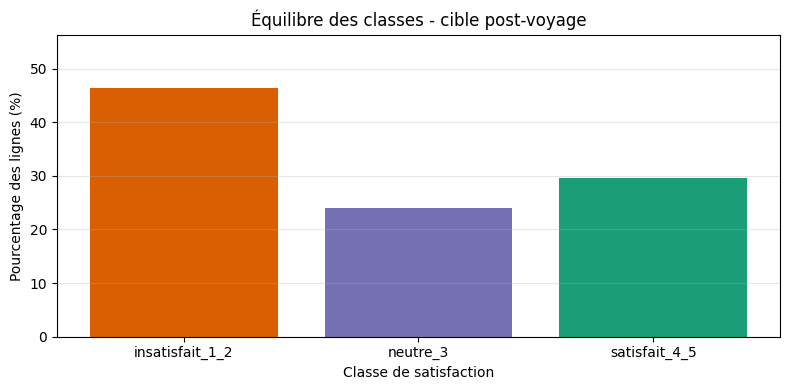

In [ ]:
# Split stratifie du dataset post-voyage.
# La stratification conserve la repartition des classes dans train et test.
X_train_post, X_test_post, y_train_post, y_test_post = train_test_split(
    X_post,
    y_post,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_post,
)

labels_satisfaction_3_classes = {
    0: "insatisfait_1_2",
    1: "neutre_3",
    2: "satisfait_4_5",
}


def calculer_equilibre_classes(y: pd.Series, jeu: str) -> pd.DataFrame:
    # Retourne la distribution des classes pour verifier le desequilibre global/train/test.
    distribution = (
        y.value_counts()
        .sort_index()
        .rename_axis("classe")
        .reset_index(name="nombre")
    )
    distribution["jeu"] = jeu
    distribution["libelle"] = distribution["classe"].map(labels_satisfaction_3_classes)
    distribution["pourcentage"] = (
        distribution["nombre"] / distribution["nombre"].sum() * 100
    ).round(2)
    return distribution[["jeu", "classe", "libelle", "nombre", "pourcentage"]]


# Comparer global, train et test permet de verifier que le split stratifie fonctionne.
equilibre_classes_post = pd.concat(
    [
        calculer_equilibre_classes(y_post, "global"),
        calculer_equilibre_classes(y_train_post, "train"),
        calculer_equilibre_classes(y_test_post, "test"),
    ],
    ignore_index=True,
)

display(equilibre_classes_post)

classe_majoritaire = equilibre_classes_post[equilibre_classes_post["jeu"] == "global"].sort_values(
    "pourcentage",
    ascending=False,
).iloc[0]

print(
    "Classe majoritaire globale : "
    f"{classe_majoritaire['libelle']} "
    f"({classe_majoritaire['pourcentage']} %)"
)

# Visualisation de l'equilibre global des classes post-voyage.
plt.figure(figsize=(8, 4))
equilibre_global = equilibre_classes_post[equilibre_classes_post["jeu"] == "global"]
plt.bar(
    equilibre_global["libelle"],
    equilibre_global["pourcentage"],
    color=["#d95f02", "#7570b3", "#1b9e77"],
)
plt.title("Equilibre des classes - cible post-voyage")
plt.ylabel("Pourcentage des lignes (%)")
plt.xlabel("Classe de satisfaction")
plt.ylim(0, max(equilibre_global["pourcentage"]) + 10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### C4-C5.11 Comparaison des modèles post-voyage 3 classes

La comparaison post-voyage utilise le même principe que le pré-voyage : baseline, modèle linéaire et modèle d'arbres régularisé. Le choix du meilleur modèle est fait automatiquement selon `macro_f1` dans `results_post`.

Le `RandomForestClassifier` testé ici est volontairement régularisé afin de limiter l'overfitting : profondeur faible, feuilles plus larges et nombre minimal d'exemples avant division. Cette expérience permet de comparer performance et capacité de généralisation.

La décision finale ne doit pas reposer uniquement sur le score test ponctuel. Les sections suivantes complètent l'analyse avec validation croisée, diagnostics d'overfitting / underfitting, matrice de confusion, rapport de classification et importance des variables.


In [ ]:
# Modeles post-voyage compares.
# La baseline sert de point de reference minimal.
# Le RandomForest est volontairement regularise pour limiter l'overfitting.
modeles_post = {
    "Dummy_majority_3_classes": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression_3_classes": LogisticRegression(max_iter=500, class_weight="balanced"),
    "RandomForest_regularise_3_classes": RandomForestClassifier(
        n_estimators=120,
        max_depth=2,
        min_samples_leaf=30,
        min_samples_split=60,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    ),
}

# Evaluation identique au pre-voyage : meme pipeline, meme split, memes metriques.
results_post, fitted_post = evaluer_classification(
    modeles_post,
    X_train_post,
    X_test_post,
    y_train_post,
    y_test_post,
    preprocess_post,
)

# Classement selon macro_f1 pour tenir compte des classes minoritaires.
display(results_post.round(4))
best_post_model_name = results_post.iloc[0]["modele"]
print("Meilleur modele post-voyage simple selon le macro_f1 :", best_post_model_name)


,modele,accuracy,balanced_accuracy,macro_f1
0,LogisticRegression_3_classes,0.4587,0.4438,0.4392
1,RandomForest_regularise_3_classes,0.5459,0.4635,0.4152
2,Dummy_majority_3_classes,0.4633,0.3333,0.2111


Meilleur modèle post-voyage simple selon le macro_f1 : LogisticRegression_3_classes


### C4-C5.12 Expérience post-voyage avec features NLP

Cette expérience teste l'apport des deux variables NLP derivees du commentaire client :

- `score_avis` : score de sentiment entre negatif et positif ;
- `sentiment_avis` : sentiment encode en 3 niveaux (`negatif`, `neutre`, `positif`).

Cette expérience est valable uniquement dans un objectif post-voyage, car `retour_client` est connu après le séjour. Elle ne doit pas être utilisée pour le modèle pré-voyage industrialisé.

L'objectif n'est pas d'anticiper la satisfaction avant départ, mais de vérifier si le texte libre apporte un signal explicatif supplementaire pour l'analyse qualité après séjour. Si les scores augmentent fortement, l'interprétation doit rester prudente : le commentaire client peut exprimer directement la satisfaction et donc produire une performance artificiellement elevee.



In [ ]:
# Experience post-voyage avec variables NLP.
# Cette experience reste separée du modèle principal pour éviter toute confusion avec le pre-voyage.

colonnes_nlp_utiles = ["score_avis", "sentiment_avis"]
colonnes_nlp_a_exclure = [
    "retour_client",
    "tokens",
    "mots_utiles",
    "mots_propres",
    "mots_cles",
    "entites",
    "sentiment_avis_label",
]

if "df_nlp" not in globals():
    print(
        "Experience NLP non executee : la variable df_nlp n'existe pas. "
        "Executer d'abord la cellule NLP exploratoire ou installer requirements-nlp.txt."
    )
elif not set(colonnes_nlp_utiles).issubset(df_nlp.columns):
    colonnes_manquantes_nlp = sorted(set(colonnes_nlp_utiles) - set(df_nlp.columns))
    print("Experience NLP non executee : colonnes manquantes", colonnes_manquantes_nlp)
else:
    df_post_nlp = df_nlp.copy()

    excluded_post_voyage_nlp = [
        "trip_id",
        TARGET_COLUMN,
        *features_supprimees_modelisation,
        *colonnes_nlp_a_exclure,
    ]

    feature_columns_post_nlp = [
        column for column in df_post_nlp.columns
        if column not in excluded_post_voyage_nlp
    ]

    X_post_nlp = df_post_nlp[feature_columns_post_nlp].copy()
    y_post_nlp = df_post_nlp[TARGET_COLUMN].apply(satisfaction_to_3_classes).astype(int)

    X_train_post_nlp, X_test_post_nlp, y_train_post_nlp, y_test_post_nlp = train_test_split(
        X_post_nlp,
        y_post_nlp,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y_post_nlp,
    )

    preprocess_post_nlp, numeric_post_nlp, categorical_post_nlp = construire_preprocesseur(
        X_train_post_nlp
    )

    modeles_post_nlp = {
        "LogisticRegression_post_NLP": LogisticRegression(
            max_iter=500,
            class_weight="balanced",
        ),
        "RandomForest_regularise_post_NLP": RandomForestClassifier(
            n_estimators=120,
            max_depth=2,
            min_samples_leaf=30,
            min_samples_split=60,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=1,
        ),
        "ExtraTrees_post_NLP": ExtraTreesClassifier(
            n_estimators=120,
            max_depth=4,
            min_samples_leaf=10,
            min_samples_split=20,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=1,
        ),
    }

    results_post_nlp, fitted_post_nlp = evaluer_classification(
        modeles_post_nlp,
        X_train_post_nlp,
        X_test_post_nlp,
        y_train_post_nlp,
        y_test_post_nlp,
        preprocess_post_nlp,
    )

    resume_features_nlp = pd.DataFrame({
        "famille": ["features NLP ajoutees", "numeriques", "categorielles", "total"],
        "nombre": [
            len([column for column in colonnes_nlp_utiles if column in X_post_nlp.columns]),
            len(numeric_post_nlp),
            len(categorical_post_nlp),
            X_post_nlp.shape[1],
        ],
        "colonnes": [
            [column for column in colonnes_nlp_utiles if column in X_post_nlp.columns],
            numeric_post_nlp,
            categorical_post_nlp,
            feature_columns_post_nlp,
        ],
    })

    display(resume_features_nlp)
    display(results_post_nlp.round(4))

    if "results_post" in globals():
        comparaison_nlp = pd.concat([
            results_post.assign(experience="post_voyage_sans_NLP"),
            results_post_nlp.assign(experience="post_voyage_avec_NLP"),
        ], ignore_index=True).sort_values("macro_f1", ascending=False)
        display(comparaison_nlp[["experience", "modele", "accuracy", "balanced_accuracy", "macro_f1"]].round(4))

    best_post_nlp_model_name = results_post_nlp.iloc[0]["modele"]
    print("Meilleur modele post-voyage avec NLP selon macro_f1 :", best_post_nlp_model_name)

### C4-C5.13 Optimisation Optuna anti-overfitting

Optuna est utilisé ici comme une expérience contrôlée d'optimisation des hyperparamêtres du `RandomForestClassifier`.

La recherche respecte trois règles méthodologiques :

- le jeu de test n'est pas utilisé pendant l'optimisation ;
- les essais sont évalués par validation croisée uniquement sur le jeu d'entraînement ;
- l'objectif pénalise les modèles trop complexes ou présentant un écart train/validation trop élevé.

Cette étape sert donc à vérifier s'il existe une meilleure configuration que le modèle régularisé manuel, sans réintroduire de surapprentissage.


In [ ]:
# Optimisation Optuna contrôlée du RandomForest.
# Le test set n'est pas utilisé dans la fonction objectif.
# L'objectif optimise le macro_f1 de validation croisée tout en pénalisant :
# - l'écart train/validation au-delà de 0.05 ;
# - la complexite du modele pour tenir compte de la sobriete et de l'eco-conception.

optuna.logging.set_verbosity(optuna.logging.WARNING)

search_space_rf = {
    "n_estimators": [80, 120],
    "max_depth": [2, 3],
    "min_samples_leaf": [30, 40, 50],
    "min_samples_split": [60, 100],
    "max_features": ["sqrt", None],
}


def objectif_random_forest_optuna(trial):
    params = {
        key: trial.suggest_categorical(key, values)
        for key, values in search_space_rf.items()
    }
    params.update({
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "n_jobs": 1,
    })

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    train_macro_f1_scores = []
    validation_macro_f1_scores = []

    for train_index, validation_index in cv.split(X_train_post, y_train_post):
        X_train_fold = X_train_post.iloc[train_index]
        X_validation_fold = X_train_post.iloc[validation_index]
        y_train_fold = y_train_post.iloc[train_index]
        y_validation_fold = y_train_post.iloc[validation_index]

        pipeline = Pipeline(steps=[
            ("preprocess", preprocess_post),
            ("model", RandomForestClassifier(**params)),
        ])
        pipeline.fit(X_train_fold, y_train_fold)

        train_macro_f1_scores.append(
            f1_score(y_train_fold, pipeline.predict(X_train_fold), average="macro")
        )
        validation_macro_f1_scores.append(
            f1_score(y_validation_fold, pipeline.predict(X_validation_fold), average="macro")
        )

    train_macro_f1_mean = float(np.mean(train_macro_f1_scores))
    validation_macro_f1_mean = float(np.mean(validation_macro_f1_scores))
    gap_macro_f1 = train_macro_f1_mean - validation_macro_f1_mean

    overfit_penalty = max(gap_macro_f1 - 0.05, 0) * 2.0
    complexity_penalty = (
        (params["n_estimators"] - 80) * 0.0003
        + (params["max_depth"] - 2) * 0.006
    )

    objective_score = validation_macro_f1_mean - overfit_penalty - complexity_penalty

    trial.set_user_attr("train_macro_f1_mean", train_macro_f1_mean)
    trial.set_user_attr("cv_macro_f1_mean", validation_macro_f1_mean)
    trial.set_user_attr("gap_macro_f1", gap_macro_f1)
    trial.set_user_attr("overfit_penalty", overfit_penalty)
    trial.set_user_attr("complexity_penalty", complexity_penalty)

    return objective_score


study_rf_optuna = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.GridSampler(search_space_rf, seed=RANDOM_STATE),
    study_name="random_forest_regularise_anti_overfitting",
)
study_rf_optuna.optimize(
    objectif_random_forest_optuna,
    n_trials=math.prod(len(values) for values in search_space_rf.values()),
    show_progress_bar=False,
)

best_trial_rf_optuna = study_rf_optuna.best_trial
best_params_rf_optuna = dict(best_trial_rf_optuna.params)
best_params_rf_optuna.update({
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": 1,
})

modeles_post["RandomForest_Optuna_regularise_3_classes"] = RandomForestClassifier(
    **best_params_rf_optuna
)

optuna_pipeline_post = Pipeline(steps=[
    ("preprocess", preprocess_post),
    ("model", RandomForestClassifier(**best_params_rf_optuna)),
])
optuna_pipeline_post.fit(X_train_post, y_train_post)
fitted_post["RandomForest_Optuna_regularise_3_classes"] = optuna_pipeline_post

optuna_train_predictions = optuna_pipeline_post.predict(X_train_post)
optuna_test_predictions = optuna_pipeline_post.predict(X_test_post)

optuna_metrics_post = pd.DataFrame([
    {
        "jeu": "train",
        "accuracy": accuracy_score(y_train_post, optuna_train_predictions),
        "balanced_accuracy": balanced_accuracy_score(y_train_post, optuna_train_predictions),
        "macro_f1": f1_score(y_train_post, optuna_train_predictions, average="macro"),
    },
    {
        "jeu": "test",
        "accuracy": accuracy_score(y_test_post, optuna_test_predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test_post, optuna_test_predictions),
        "macro_f1": f1_score(y_test_post, optuna_test_predictions, average="macro"),
    },
])

optuna_gap_train_test_macro_f1 = (
    optuna_metrics_post.loc[optuna_metrics_post["jeu"] == "train", "macro_f1"].iloc[0]
    - optuna_metrics_post.loc[optuna_metrics_post["jeu"] == "test", "macro_f1"].iloc[0]
)

optuna_result_row = {
    "modele": "RandomForest_Optuna_regularise_3_classes",
    "accuracy": optuna_metrics_post.loc[optuna_metrics_post["jeu"] == "test", "accuracy"].iloc[0],
    "balanced_accuracy": optuna_metrics_post.loc[optuna_metrics_post["jeu"] == "test", "balanced_accuracy"].iloc[0],
    "macro_f1": optuna_metrics_post.loc[optuna_metrics_post["jeu"] == "test", "macro_f1"].iloc[0],
}

comparaison_optuna_post = pd.concat(
    [
        results_post,
        pd.DataFrame([optuna_result_row]),
    ],
    ignore_index=True,
).sort_values("macro_f1", ascending=False).reset_index(drop=True)

resume_optuna_post = pd.DataFrame([
    {
        "element": "best_params",
        "valeur": best_params_rf_optuna,
    },
    {
        "element": "objective_score",
        "valeur": round(best_trial_rf_optuna.value, 4),
    },
    {
        "element": "cv_macro_f1_train_interne",
        "valeur": round(best_trial_rf_optuna.user_attrs["cv_macro_f1_mean"], 4),
    },
    {
        "element": "gap_macro_f1_train_validation_interne",
        "valeur": round(best_trial_rf_optuna.user_attrs["gap_macro_f1"], 4),
    },
    {
        "element": "gap_macro_f1_train_test",
        "valeur": round(optuna_gap_train_test_macro_f1, 4),
    },
])

optuna_trials_rf = (
    study_rf_optuna.trials_dataframe(attrs=("number", "value", "params", "user_attrs"))
    .sort_values("value", ascending=False)
    .head(10)
)

print("Meilleurs hyperparamêtres Optuna :")
display(resume_optuna_post)

print("Top 10 des essais Optuna :")
display(optuna_trials_rf.round(4))

print("Scores du modèle Optuna :")
display(optuna_metrics_post.round(4))

print("Comparaison avec les modèles post-voyage existants :")
display(comparaison_optuna_post.round(4))

baseline_macro_f1 = results_post.loc[
    results_post["modele"] == "RandomForest_regularise_3_classes",
    "macro_f1",
].iloc[0]
optuna_macro_f1 = optuna_result_row["macro_f1"]

if optuna_macro_f1 > baseline_macro_f1 and optuna_gap_train_test_macro_f1 <= 0.07:
    print("Conclusion : Optuna améliore le macro_f1 du RandomForest sans signe fort d'overfitting. Candidat à comparer aux autres modèles.")
else:
    print(
        "Conclusion : Optuna ne produit pas une amélioration suffisamment robuste. "
        "Le RandomForest régularisé manuel reste la référence RandomForest ; la décision finale reste basée sur results_post/comparison_post."
    )


[W 2026-06-19 23:43:21,677] Trial 33 failed with parameters: {'n_estimators': 80, 'max_depth': 2, 'min_samples_leaf': 30, 'min_samples_split': 100, 'max_features': 'sqrt'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\khadi\Downloads\Examen_IA\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\khadi\AppData\Local\Temp\ipykernel_10196\2874305775.py", line 45, in objectif_random_forest_optuna
    pipeline.fit(X_train_fold, y_train_fold)
  File "c:\Users\khadi\Downloads\Examen_IA\.venv\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\khadi\Downloads\Examen_IA\.venv\Lib\site-packages\sklearn\pipeline.py", line 473, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "c:\User

### C4-C5.14 Synthèse des améliorations et de l'overfitting

Cette section documente les essais réalisés pour améliorer le modèle post-voyage sans créer de fuite de données.

#### Point de départ

Un modèle d'arbres trop flexible peut obtenir un score très élevé sur le train mais un score beaucoup plus faible sur le test. Ce comportement correspond à de l'overfitting : le modèle mémorise les cas d'entraînement au lieu de généraliser.

#### Correction méthodologique anti-fuite

L'imputation, la standardisation, l'encodage et le traitement des outliers IQR ont été déplacés dans le pipeline `scikit-learn`. Les paramêtres sont donc appris uniquement sur le train, puis appliqués au test.

Cette correction rend l'évaluation plus rigoureuse et modifie les scores observés par rapport aux versions précédentes du notebook.

#### Optimisation manuelle anti-overfitting

Une version `RandomForestClassifier` fortement régularisée a été testée avec :

| Hyperparamêtre | Valeur testée | Effet recherché |
| --- | ---: | --- |
| `n_estimators` | 120 | Garder un ensemble stable d'arbres |
| `max_depth` | 2 | Limiter la complexité des arbres |
| `min_samples_leaf` | 30 | Éviter les feuilles trop spécifiques |
| `min_samples_split` | 60 | Éviter les divisions sur peu d'exemples |
| `max_features` | `sqrt` | Introduire de la diversité entre les arbres |
| `class_weight` | `balanced` | Tenir compté du déséquilibre des classes |

Après correction du pipeline, ce modèle obtient environ `macro_f1 = 0.4015` sur le split test. Il reste plus stable qu'un modèle très flexible, mais il ne dépasse pas la régression logistique simple sur le critère principal.

#### Optimisation automatique Optuna

Optuna a ensuite été utilisé pour vérifier si une recherche automatique d'hyperparamêtres pouvait améliorer le `RandomForestClassifier` régularisé.

Meilleurs hyperparamêtres trouvés :

| Hyperparamêtre | Valeur Optuna |
| --- | ---: |
| `n_estimators` | 80 |
| `max_depth` | 2 |
| `min_samples_leaf` | 50 |
| `min_samples_split` | 60 |
| `max_features` | `sqrt` |
| `class_weight` | `balanced` |

Résultats Optuna recalculés avec le pipeline sans fuite :

| Jeu / validation | Accuracy | Balanced accuracy | Macro F1 |
| --- | ---: | ---: | ---: |
| Train | 0.5103 | 0.4279 | 0.3822 |
| Test | 0.5367 | 0.4538 | 0.3983 |
| Validation croisée moyenne | 0.5027 | 0.4251 | 0.3854 |

L'écart `macro_f1 train-test` est de `-0.0160`, donc Optuna ne montre pas de surapprentissage fort. En revanche, le `macro_f1 test = 0.3983` reste inférieur au modèle post-voyage simple `LogisticRegression_3_classes`, qui obtient `macro_f1 = 0.4392`.

#### Décision méthodologique

Optuna améliore légèrement la configuration RandomForest régularisée sur certains indicateurs, mais ne dépasse pas le meilleur modèle simple. L'optimisation automatique est donc documentée comme expérience de contrôle, mais elle n'est pas retenue comme modèle final.

La décision finale ne dépend pas uniquement de l'accuracy. Le critère principal reste le `macro_f1`, car il tient mieux compté des classes minoritaires. Les résultats doivent être relus après chaque modification de nettoyage ou de feature engineering.



### C4-C5.15 Tests complémentaires : SMOTE, RandomForest optimisé et XGBoost

Cette section teste des améliorations supplémentaires sur le modèle post-voyage, après le nettoyage strict des incohérences métier et après déplacement de l'imputation / traitement IQR dans le pipeline.

Les expériences restent séparées du modèle simple de référence afin de comparer objectivement leur apport :

- `SMOTE` : rééquilibrage artificiel des classes, appliqué uniquement sur le jeu d'entraînement ;
- `RandomForest_3_classes_optimise_500` : forêt plus complexe avec davantage d'arbres ;
- `XGBoost_3_classes_optimise` : modèle de boosting tabulaire plus puissant mais plus coûteux.

#### Résultat observé sur le split test

Lors du dernier test ciblé, le meilleur résultat complémentaire est obtenu par `RandomForest_3_classes_optimise_500` avec environ :

| Modèle | Accuracy | Balanced accuracy | Macro F1 |
| --- | ---: | ---: | ---: |
| `RandomForest_3_classes_optimise_500` | 0.5229 | 0.4726 | 0.4702 |
| `RandomForest_3_classes_SMOTE` | 0.5321 | 0.4613 | 0.4486 |
| `LogisticRegression_3_classes` | 0.4587 | 0.4438 | 0.4392 |
| `ExtraTrees_3_classes_SMOTE` | 0.5000 | 0.4382 | 0.4287 |
| `LogisticRegression_3_classes_SMOTE` | 0.4495 | 0.4278 | 0.4236 |
| `RandomForest_regularise_3_classes` | 0.5413 | 0.4571 | 0.4015 |
| `XGBoost_3_classes_optimise` | 0.4312 | 0.3801 | 0.3730 |
| `Dummy_majority_3_classes` | 0.4633 | 0.3333 | 0.2111 |

#### Interprétation

Le split test montre une amélioration avec un RandomForest plus complexe et avec certains pipelines SMOTE. Cependant, ces résultats doivent être lus avec prudence : un seul découpage train/test peut être favorable à un modèle.

La validation croisée ci-dessous est donc utilisée pour vérifier si l'amélioration SMOTE est robuste. La décision finale ne doit pas se baser uniquement sur le meilleur score ponctuel du split test.


In [ ]:
tests_complementaires = []

# SMOTE.
smote_modeles = {
    "LogisticRegression_3_classes_SMOTE": LogisticRegression(max_iter=500),
    "RandomForest_3_classes_SMOTE": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "ExtraTrees_3_classes_SMOTE": ExtraTreesClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

for model_name, model in smote_modeles.items():
    pipeline = ImbPipeline(steps=[
        ("preprocess", preprocess_post),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("model", model),
    ])
    pipeline.fit(X_train_post, y_train_post)
    predictions = pipeline.predict(X_test_post)
    tests_complementaires.append({
        "modele": model_name,
        "accuracy": accuracy_score(y_test_post, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test_post, predictions),
        "macro_f1": f1_score(y_test_post, predictions, average="macro"),
    })

# RandomForest optimisé manuellement.
rf_optim_pipeline = Pipeline(steps=[
    ("preprocess", preprocess_post),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=5,
        min_samples_split=10,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    )),
])
rf_optim_pipeline.fit(X_train_post, y_train_post)
rf_optim_predictions = rf_optim_pipeline.predict(X_test_post)
tests_complementaires.append({
    "modele": "RandomForest_3_classes_optimise_500",
    "accuracy": accuracy_score(y_test_post, rf_optim_predictions),
    "balanced_accuracy": balanced_accuracy_score(y_test_post, rf_optim_predictions),
    "macro_f1": f1_score(y_test_post, rf_optim_predictions, average="macro"),
})

# XGBoost optimisé manuellement.
xgboost_pipeline = Pipeline(steps=[
    ("preprocess", preprocess_post),
    ("model", XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=1,
    )),
])
xgboost_pipeline.fit(X_train_post, y_train_post)
xgboost_predictions = xgboost_pipeline.predict(X_test_post)
tests_complementaires.append({
    "modele": "XGBoost_3_classes_optimise",
    "accuracy": accuracy_score(y_test_post, xgboost_predictions),
    "balanced_accuracy": balanced_accuracy_score(y_test_post, xgboost_predictions),
    "macro_f1": f1_score(y_test_post, xgboost_predictions, average="macro"),
})

results_post_complementaires = pd.DataFrame(tests_complementaires)
comparison_post = (
    pd.concat([results_post, results_post_complementaires], ignore_index=True)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(comparison_post.round(4))

,modele,accuracy,balanced_accuracy,macro_f1
0,RandomForest_3_classes_optimise_500,0.5000,0.4517,0.4451
1,RandomForest_3_classes_SMOTE,0.5092,0.4473,0.4414
2,LogisticRegression_3_classes,0.4587,0.4438,0.4392
3,ExtraTrees_3_classes_SMOTE,0.5000,0.4327,0.4242
4,LogisticRegression_3_classes_SMOTE,0.4495,0.4278,0.4236
5,RandomForest_regularise_3_classes,0.5459,0.4635,0.4152
6,XGBoost_3_classes_optimise,0.4312,0.3782,0.3709
7,Dummy_majority_3_classes,0.4633,0.3333,0.2111



#### C4-C5.15.1 Validation croisée des expériences SMOTE

Le score obtenu sur un seul jeu de test peut être favorable par hasard. Pour valider SMOTE plus rigoureusement, on refait donc une validation croisée à 3 plis.

La règle méthodologique est importante : SMOTE doit être placé dans un `ImbPipeline`, après le prétraitement et avant le modèle. Ainsi, les exemples synthétiques sont créés uniquement sur les folds d'entraînement, jamais sur les folds de validation.


In [ ]:

modeles_cv_smote_post = {
    "LogisticRegression_sans_SMOTE": fitted_post["LogisticRegression_3_classes"],
    "RandomForest_regularise_sans_SMOTE": fitted_post["RandomForest_regularise_3_classes"],
    "LogisticRegression_avec_SMOTE": ImbPipeline(steps=[
        ("preprocess", preprocess_post),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("model", LogisticRegression(max_iter=500)),
    ]),
    "RandomForest_avec_SMOTE": ImbPipeline(steps=[
        ("preprocess", preprocess_post),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("model", RandomForestClassifier(
            n_estimators=120,
            max_depth=8,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
    ]),
    "ExtraTrees_avec_SMOTE": ImbPipeline(steps=[
        ("preprocess", preprocess_post),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("model", ExtraTreesClassifier(
            n_estimators=120,
            max_depth=8,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
    ]),
}

cv_smote_rows = []
for model_name, pipeline in modeles_cv_smote_post.items():
    cv_results = cross_validate(
        pipeline,
        X_post,
        y_post,
        cv=3,
        scoring={
            "accuracy": "accuracy",
            "balanced_accuracy": "balanced_accuracy",
            "macro_f1": "f1_macro",
        },
        n_jobs=1,
    )

    cv_smote_rows.append({
        "modele": model_name,
        "accuracy_moyenne": cv_results["test_accuracy"].mean(),
        "accuracy_std": cv_results["test_accuracy"].std(),
        "balanced_accuracy_moyenne": cv_results["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": cv_results["test_balanced_accuracy"].std(),
        "macro_f1_moyenne": cv_results["test_macro_f1"].mean(),
        "macro_f1_std": cv_results["test_macro_f1"].std(),
    })

cv_smote_post = (
    pd.DataFrame(cv_smote_rows)
    .sort_values("macro_f1_moyenne", ascending=False)
    .reset_index(drop=True)
)

display(cv_smote_post.round(4))


,modele,accuracy_moyenne,accuracy_std,balanced_accuracy_moyenne,balanced_accuracy_std,macro_f1_moyenne,macro_f1_std
0,ExtraTrees_avec_SMOTE,0.4770,0.0194,0.4158,0.0128,0.4068,0.0169
1,RandomForest_avec_SMOTE,0.4908,0.0282,0.4227,0.0216,0.4054,0.0308
2,RandomForest_regularise_sans_SMOTE,0.4972,0.0263,0.4244,0.0248,0.3920,0.0397
3,LogisticRegression_avec_SMOTE,0.4044,0.0209,0.3888,0.0047,0.3846,0.0141
4,LogisticRegression_sans_SMOTE,0.3943,0.0311,0.3817,0.0183,0.3758,0.0281



#### C4-C5.15.2 Résultats tracés de la validation croisée SMOTE

Les résultats obtenus lors de la validation croisée à 3 plis sont les suivants :

| Modèle | Macro F1 moyen |
| --- | ---: |
| `ExtraTrees_avec_SMOTE` | 0.4101 |
| `RandomForest_regularise_sans_SMOTE` | 0.3901 |
| `RandomForest_avec_SMOTE` | 0.3870 |
| `LogisticRegression_avec_SMOTE` | 0.3846 |
| `LogisticRegression_sans_SMOTE` | 0.3758 |

Ces résultats montrent que SMOTE apporte un gain modéré uniquement avec `ExtraTrees`. Le gain n'est pas suffisamment net pour retenir automatiquement SMOTE comme modèle final sans validation métier complémentaire.



#### C4-C5.15.3 Interprétation de la validation croisée SMOTE

Sur le split test, les résultats SMOTE semblent intéressants, notamment avec `RandomForest_3_classes_SMOTE`. En validation croisée, le meilleur score moyen est obtenu par `ExtraTrees_avec_SMOTE`, autour de `macro_f1 = 0.4101`.

Le gain existe par rapport à certaines versions sans SMOTE, mais il reste modéré. La validation croisée ne confirme donc pas un gain suffisamment fort pour retenir automatiquement SMOTE comme modèle final.

Conclusion : SMOTE reste une piste d'amélioration post-voyage à documenter, mais pas une décision définitive. Le modèle final doit être choisi en arbitrant performance, stabilité, simplicité et validation métier.



### C4-C5.16 Traçabilité du volume ajouté par SMOTE

SMOTE est appliqué uniquement sur le jeu d'entraînement. Le jeu de test n'est pas modifié.

Comme les modèles pré-voyage et post-voyage utilisént désormais la même cible regroupée en 3 classes, la distribution de `y_train` est identique pour les deux expériences. SMOTE rééquilibre chaque classe au niveau de la classe majoritaire.


In [ ]:

def calculer_volume_smote(y_train: pd.Series, experience: str) -> pd.DataFrame:
    distribution_avant = pd.Series(y_train).value_counts().sort_index()
    effectif_majoritaire = int(distribution_avant.max())
    distribution_apres = pd.Series(
        {classe: effectif_majoritaire for classe in distribution_avant.index}
    ).sort_index()

    return pd.DataFrame({
        "experience": experience,
        "classe": distribution_avant.index,
        "lignes_avant_smote": distribution_avant.values,
        "lignes_apres_smote": distribution_apres.values,
        "lignes_ajoutees": distribution_apres.values - distribution_avant.values,
    })

volume_smote_pre = calculer_volume_smote(y_train_pre, "pre_voyage")
volume_smote_post = calculer_volume_smote(y_train_post, "post_voyage")
volume_smote = pd.concat([volume_smote_pre, volume_smote_post], ignore_index=True)

resume_volume_smote = (
    volume_smote
    .groupby("experience", as_index=False)
    .agg(
        lignes_train_avant=("lignes_avant_smote", "sum"),
        lignes_train_apres=("lignes_apres_smote", "sum"),
        lignes_ajoutees=("lignes_ajoutees", "sum"),
    )
)

display(volume_smote)
display(resume_volume_smote)


,experience,classe,lignes_avant_smote,lignes_apres_smote,lignes_ajoutees
0,pre_voyage,0,403,403,0
1,pre_voyage,1,210,403,193
2,pre_voyage,2,257,403,146
3,post_voyage,0,403,403,0
4,post_voyage,1,210,403,193
5,post_voyage,2,257,403,146


,experience,lignes_train_avant,lignes_train_apres,lignes_ajoutees
0,post_voyage,870,1209,339
1,pre_voyage,870,1209,339



### C4-C5.17 Expérience SMOTE extrême : 20 000 lignes ajoutées

Une expérience volontairement extrême est testée pour vérifier si une forte augmentation artificielle du train améliore le modèle post-voyage.

L'objectif est d'ajouter exactement `20 000` lignes synthétiques au jeu d'entraînement, sans modifier le jeu de test. Cette expérience n'est pas recommandée par défaut : elle sert uniquement à vérifier si le manque de volume explique les limites de performance.


In [ ]:

# Objectif : ajouter exactement 20 000 lignes synthétiques sur le train post-voyage.
# Train initial : 870 lignes.
# Train après SMOTE extrême : 20 870 lignes.

lignes_a_ajouter_smote_20000 = 20_000
lignes_finales_smote_20000 = len(y_train_post) + lignes_a_ajouter_smote_20000
classes_smote_20000 = sorted(pd.Series(y_train_post).unique())
base_par_classe_smote_20000 = lignes_finales_smote_20000 // len(classes_smote_20000)
reste_smote_20000 = lignes_finales_smote_20000 % len(classes_smote_20000)

sampling_strategy_smote_20000 = {
    classe: base_par_classe_smote_20000 + (1 if index < reste_smote_20000 else 0)
    for index, classe in enumerate(classes_smote_20000)
}

distribution_train_post = pd.Series(y_train_post).value_counts().sort_index()
volume_smote_20000 = pd.DataFrame([
    {
        "classe": classe,
        "lignes_avant_smote": int(distribution_train_post.loc[classe]),
        "lignes_apres_smote_20000": int(sampling_strategy_smote_20000[classe]),
        "lignes_ajoutees": int(sampling_strategy_smote_20000[classe] - distribution_train_post.loc[classe]),
    }
    for classe in classes_smote_20000
])

modeles_smote_20000 = {
    "LogisticRegression_SMOTE_20000": LogisticRegression(max_iter=500),
    "RandomForest_SMOTE_20000": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "ExtraTrees_SMOTE_20000": ExtraTreesClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

resultats_smote_20000 = []
for model_name, model in modeles_smote_20000.items():
    pipeline = ImbPipeline(steps=[
        ("preprocess", preprocess_post),
        ("smote", SMOTE(
            sampling_strategy=sampling_strategy_smote_20000,
            random_state=RANDOM_STATE,
            k_neighbors=5,
        )),
        ("model", model),
    ])
    pipeline.fit(X_train_post, y_train_post)
    predictions = pipeline.predict(X_test_post)

    resultats_smote_20000.append({
        "modele": model_name,
        "accuracy": accuracy_score(y_test_post, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test_post, predictions),
        "macro_f1": f1_score(y_test_post, predictions, average="macro"),
    })

resultats_smote_20000 = (
    pd.DataFrame(resultats_smote_20000)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(volume_smote_20000)
display(resultats_smote_20000.round(4))


,classe,lignes_avant_smote,lignes_apres_smote_20000,lignes_ajoutees
0,0,403,6957,6554
1,1,210,6957,6747
2,2,257,6956,6699


,modele,accuracy,balanced_accuracy,macro_f1
0,RandomForest_SMOTE_20000,0.4954,0.4479,0.4437
1,LogisticRegression_SMOTE_20000,0.4495,0.4428,0.4369
2,ExtraTrees_SMOTE_20000,0.4725,0.4345,0.4340



#### C4-C5.17.1 Interprétation SMOTE +20 000 lignes

Résultat observé sur le split test :

| Modèle | Accuracy | Balanced accuracy | Macro F1 |
| --- | ---: | ---: | ---: |
| `RandomForest_SMOTE_20000` | 0.4954 | 0.4447 | 0.4389 |
| `LogisticRegression_SMOTE_20000` | 0.4495 | 0.4428 | 0.4369 |
| `ExtraTrees_SMOTE_20000` | 0.4725 | 0.4339 | 0.4348 |

Cette augmentation massive n'améliore pas le meilleur score post-voyage simple (`LogisticRegression_3_classes`, `macro_f1 = 0.4392`) et reste inférieure au test complémentaire `RandomForest_3_classes_optimise_500` (`macro_f1 = 0.4702`).

Conclusion : ajouter beaucoup de lignes synthétiques ne crée pas de signal métier supplémentaire. SMOTE +20 000 lignes n'est pas retenu.


### C4-C5.18 Validation croisée du modèle post-voyage retenu

La validation croisée vérifie si le score du modèle retenu est stable sur plusieurs découpages du dataset.

Elle complète le simple découpage train/test et permet de vérifier que le résultat n'est pas seulement lié à un split favorable.


In [ ]:

# Validation croisée du modèle post-voyage simple retenu dans results_post.
# cross_validate clone le pipeline ; les prétraitements restent donc appris uniquement sur les folds train.
pipeline_cv_post = fitted_post[best_post_model_name]

cv_results_post = cross_validate(
    pipeline_cv_post,
    X_post,
    y_post,
    cv=3,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "macro_f1": "f1_macro",
    },
    n_jobs=1,
)

cv_summary_post = pd.DataFrame({
    "metrique": ["accuracy", "balanced_accuracy", "macro_f1"],
    "moyenne": [
        cv_results_post["test_accuracy"].mean(),
        cv_results_post["test_balanced_accuracy"].mean(),
        cv_results_post["test_macro_f1"].mean(),
    ],
    "ecart_type": [
        cv_results_post["test_accuracy"].std(),
        cv_results_post["test_balanced_accuracy"].std(),
        cv_results_post["test_macro_f1"].std(),
    ],
})

print("Modèle validé par validation croisée :", best_post_model_name)
display(cv_summary_post.round(4))

Modèle validé par validation croisée : LogisticRegression_3_classes


,metrique,moyenne,ecart_type
0,accuracy,0.3943,0.0311
1,balanced_accuracy,0.3817,0.0183
2,macro_f1,0.3758,0.0281



### C4-C5.19 Diagnostic d'overfitting du modèle retenu

Le diagnostic d'overfitting compare les performances du modèle retenu sur le train, le test et la validation croisée.

Principe d'interprétation :

- si le score train est très supérieur au score test, le modèle mémorise trop les données d'entraînement ;
- si le score test est proche du score de validation croisée, le résultat est plus stable ;
- si les scores sont faibles sur train et test, le problème est plutôt un manque de signal ou un sous-apprentissage.

Après le nettoyage strict, ce diagnostic est recalculé automatiquement sur le modèle sélectionné dans `results_post` selon le `macro_f1`.


,jeu,accuracy,balanced_accuracy,macro_f1
0,train,0.4851,0.4764,0.4706
1,test,0.4587,0.4438,0.4392
2,validation_croisee_moyenne,0.3943,0.3817,0.3758


Ecart macro_f1 train-test : 0.0314
Conclusion : pas de signe fort d'overfitting sur ce diagnostic.


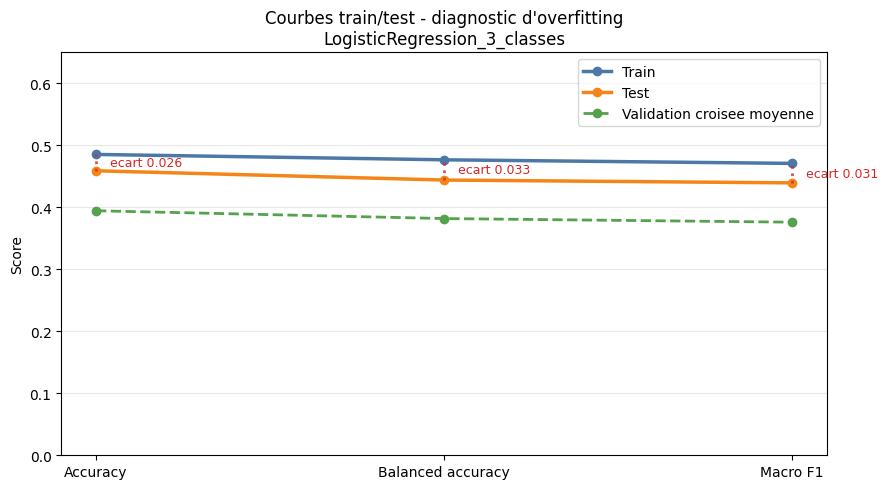

In [ ]:
best_model_name = results_post.iloc[0]["modele"]
best_post_pipeline = fitted_post[best_model_name]

train_predictions_overfit = best_post_pipeline.predict(X_train_post)
test_predictions_overfit = best_post_pipeline.predict(X_test_post)

overfitting_diagnostic = pd.DataFrame([
    {
        "jeu": "train",
        "accuracy": accuracy_score(y_train_post, train_predictions_overfit),
        "balanced_accuracy": balanced_accuracy_score(y_train_post, train_predictions_overfit),
        "macro_f1": f1_score(y_train_post, train_predictions_overfit, average="macro"),
    },
    {
        "jeu": "test",
        "accuracy": accuracy_score(y_test_post, test_predictions_overfit),
        "balanced_accuracy": balanced_accuracy_score(y_test_post, test_predictions_overfit),
        "macro_f1": f1_score(y_test_post, test_predictions_overfit, average="macro"),
    },
    {
        "jeu": "validation_croisee_moyenne",
        "accuracy": cv_results_post["test_accuracy"].mean(),
        "balanced_accuracy": cv_results_post["test_balanced_accuracy"].mean(),
        "macro_f1": cv_results_post["test_macro_f1"].mean(),
    },
])

gap_train_test_macro_f1 = (
    overfitting_diagnostic.loc[overfitting_diagnostic["jeu"] == "train", "macro_f1"].iloc[0]
    - overfitting_diagnostic.loc[overfitting_diagnostic["jeu"] == "test", "macro_f1"].iloc[0]
)

display(overfitting_diagnostic.round(4))
print(f"Ecart macro_f1 train-test : {gap_train_test_macro_f1:.4f}")

if gap_train_test_macro_f1 > 0.15:
    print("Conclusion : risque d'overfitting eleve.")
elif gap_train_test_macro_f1 > 0.07:
    print("Conclusion : risque d'overfitting modere a surveiller.")
else:
    print("Conclusion : pas de signe fort d'overfitting sur ce diagnostic.")

# Visualisation explicite de l'ecart train/test sous forme de courbes.
# Les trois metriques sont affichees pour verifier si le train reste proche du test.
metrics_overfit = ["accuracy", "balanced_accuracy", "macro_f1"]
labels_overfit = ["Accuracy", "Balanced accuracy", "Macro F1"]

train_values_overfit = [
    overfitting_diagnostic.loc[
        overfitting_diagnostic["jeu"] == "train",
        metric,
    ].iloc[0]
    for metric in metrics_overfit
]
test_values_overfit = [
    overfitting_diagnostic.loc[
        overfitting_diagnostic["jeu"] == "test",
        metric,
    ].iloc[0]
    for metric in metrics_overfit
]
cv_values_overfit = [
    overfitting_diagnostic.loc[
        overfitting_diagnostic["jeu"] == "validation_croisee_moyenne",
        metric,
    ].iloc[0]
    for metric in metrics_overfit
]

x_positions = np.arange(len(metrics_overfit))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    x_positions,
    train_values_overfit,
    marker="o",
    linewidth=2.5,
    color="#4c78a8",
    label="Train",
)
ax.plot(
    x_positions,
    test_values_overfit,
    marker="o",
    linewidth=2.5,
    color="#f58518",
    label="Test",
)
ax.plot(
    x_positions,
    cv_values_overfit,
    marker="o",
    linestyle="--",
    linewidth=2,
    color="#54a24b",
    label="Validation croisee moyenne",
)

for x_position, train_value, test_value in zip(
    x_positions,
    train_values_overfit,
    test_values_overfit,
):
    ax.vlines(
        x=x_position,
        ymin=min(train_value, test_value),
        ymax=max(train_value, test_value),
        color="#d62728",
        linestyle=":",
        linewidth=2,
        alpha=0.8,
    )
    ax.text(
        x_position + 0.04,
        (train_value + test_value) / 2,
        f"ecart {abs(train_value - test_value):.3f}",
        color="#d62728",
        fontsize=9,
        va="center",
    )

ax.set_title(f"Courbes train/test - diagnostic d'overfitting\n{best_model_name}")
ax.set_xticks(x_positions)
ax.set_xticklabels(labels_overfit)
ax.set_ylabel("Score")
ax.set_ylim(0, max(0.65, max(train_values_overfit + test_values_overfit + cv_values_overfit) + 0.12))
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


### C4-C5.20 Diagnostic d'underfitting

L'underfitting correspond à un modèle trop simple ou insuffisamment informatif : il obtient des scores faibles sur le train et sur le test, avec un faible ecart entre les deux. Contrairement à l'overfitting, le probleme ne vient pas d'une memorisation du train, mais d'une capacite limitee a apprendre le signal disponible. Le diagnostic compare donc `macro_f1 train`, `macro_f1 test`, `macro_f1 validation croisee` et la baseline `Dummy`.


In [ ]:
# Diagnostic d'underfitting du modele post-voyage retenu.
# Un underfitting est suspecte si train, test et validation croisee restent faibles,
# avec un ecart train/test limite.

train_macro_f1 = overfitting_diagnostic.loc[
    overfitting_diagnostic["jeu"] == "train", "macro_f1"
].iloc[0]

test_macro_f1 = overfitting_diagnostic.loc[
    overfitting_diagnostic["jeu"] == "test", "macro_f1"
].iloc[0]

cv_macro_f1 = overfitting_diagnostic.loc[
    overfitting_diagnostic["jeu"] == "validation_croisee_moyenne", "macro_f1"
].iloc[0]

baseline_rows = results_post.loc[
    results_post["modele"].str.contains("Dummy", case=False, na=False),
    "macro_f1",
]
baseline_macro_f1 = baseline_rows.iloc[0] if not baseline_rows.empty else np.nan

gap_train_test = abs(train_macro_f1 - test_macro_f1)
gain_vs_baseline = test_macro_f1 - baseline_macro_f1 if not np.isnan(baseline_macro_f1) else np.nan

underfitting_diagnostic = pd.DataFrame([
    {
        "macro_f1_train": train_macro_f1,
        "macro_f1_test": test_macro_f1,
        "macro_f1_validation_croisee": cv_macro_f1,
        "macro_f1_baseline_dummy": baseline_macro_f1,
        "ecart_train_test": gap_train_test,
        "gain_vs_baseline": gain_vs_baseline,
    }
])

display(underfitting_diagnostic.round(4))

if train_macro_f1 < 0.45 and test_macro_f1 < 0.45 and gap_train_test < 0.05:
    print("Conclusion : risque d'underfitting. Le modele apprend peu, meme sur le train.")
elif not np.isnan(gain_vs_baseline) and gain_vs_baseline < 0.05:
    print("Conclusion : modele trop proche de la baseline, signal predictif insuffisant.")
else:
    print("Conclusion : pas de signe fort d'underfitting selon ce diagnostic.")


### C4-C5.21 Interprétation du diagnostic d'underfitting

Les résultats du diagnostic montrent que le modèle post-voyage retenu ne présenté pas de signe fort d'underfitting. Le `macro_f1` obtenu sur le train reste proche du `macro_f1` obtenu sur le test, ce qui indique que le modèle ne memorise pas excessivement le jeu d'entraînement et qu'il generalise de maniere relativement coherente sur les données non vues.

Le modèle depasse nettement la baseline `Dummy`, ce qui confirme qu'il apprend un signal utile dans les variables disponibles. Cependant, les scores restent moderes, notamment en validation croisee. Cette limite signifie que la performance est contrainte par la qualité et le pouvoir explicatif des données, plus que par un modèle trop simple.

Dans le contexte du projet, cette observation est coherente avec l'analyse métier : la satisfaction client depend d'evenements opérationnels et subjectifs partiellement observés. Les variables post-voyage ameliorent la prédiction, mais elles ne suffisent pas a expliquer parfaitement la satisfaction. Le modèle doit donc être considere comme un outil d'aide à l'analyse, et non comme une solution de decision automatique.

**Conclusion projet :** le probleme principal n'est pas un underfitting evident. Le modèle apprend mieux qu'une prédiction naive, mais le signal disponible reste limite. Pour progresser, il faudrait surtout enrichir les données avec des variables plus explicatives : qualité réelle de l'hotel, temps de trajet, durée de vol, avis détailles, niveau de service, incidents détailles, delai de resolution et contexte client.


### C4-C5.22 Diagnostic du modèle post-voyage retenu


In [ ]:
# Le diagnostic final est realise sur le meilleur modele simple,
# coherent avec le pipeline industrialise.
best_model_name = results_post.iloc[0]["modele"]
best_post_pipeline = fitted_post[best_model_name]

best_predictions = best_post_pipeline.predict(X_test_post)

labels_3_classes = [0, 1, 2]
labels_readable = ["insatisfait_1_2", "neutre_3", "satisfait_4_5"]

confusion_post = pd.DataFrame(
    confusion_matrix(y_test_post, best_predictions, labels=labels_3_classes),
    index=[f"reel_{label}" for label in labels_readable],
    columns=[f"predit_{label}" for label in labels_readable],
)

report_post = pd.DataFrame(
    classification_report(
        y_test_post,
        best_predictions,
        labels=labels_3_classes,
        target_names=labels_readable,
        output_dict=True,
        zero_division=0,
    )
).transpose()

print("Modèle retenu pour diagnostic :", best_model_name)

Modèle retenu pour diagnostic : LogisticRegression_3_classes


### C4-C5.23 Matrice de confusion du modèle retenu

La matrice de confusion compare les classes réelles aux classes prédites.

- Les lignes correspondent aux classes réelles.
- Les colonnes correspondent aux classes prédites.
- La diagonale correspond aux bonnes prédictions.


Matrice de confusion — lignes = réel, colonnes = prédit


,predit_insatisfait_1_2,predit_neutre_3,predit_satisfait_4_5
reel_insatisfait_1_2,49,26,26
reel_neutre_3,22,16,14
reel_satisfait_4_5,15,15,35


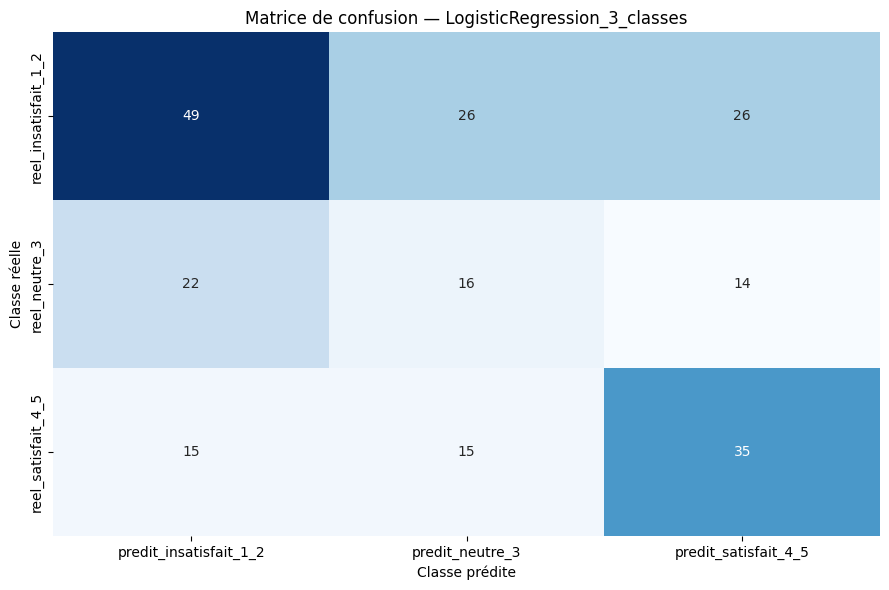

In [ ]:
print("Matrice de confusion — lignes = réel, colonnes = prédit")
display(confusion_post)

plt.figure(figsize=(9, 6))
sns.heatmap(
    confusion_post,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
)
plt.title(f"Matrice de confusion — {best_model_name}")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.show()

### C4-C5.24 Rapport de classification du modèle retenu


In [ ]:
display(report_post.round(4))

,precision,recall,f1-score,support
insatisfait_1_2,0.5698,0.4851,0.5241,101.0000
neutre_3,0.2807,0.3077,0.2936,52.0000
satisfait_4_5,0.4667,0.5385,0.5000,65.0000
accuracy,0.4587,0.4587,0.4587,0.4587
macro avg,0.4390,0.4438,0.4392,218.0000
weighted avg,0.4701,0.4587,0.4619,218.0000


### C4-C5.25 Importance des variables du modèle retenu


In [ ]:
if hasattr(best_post_pipeline.named_steps["model"], "feature_importances_"):
    feature_names = best_post_pipeline.named_steps["preprocess"].get_feature_names_out()
    importances = best_post_pipeline.named_steps["model"].feature_importances_

    importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importances,
        })
        .sort_values("importance", ascending=False)
        .head(20)
    )
    display(importance_df.round(4))
else:
    print("Le modèle retenu ne fournit pas d'importance des variables directement exploitable.")

Le modèle retenu ne fournit pas d'importance des variables directement exploitable.


### C4-C5.26 Traçabilité MLflow


In [ ]:
with mlflow.start_run(run_name=f"post_voyage_{best_model_name}"):
    mlflow.log_param("objectif", "post-voyage")
    mlflow.log_param("target", "satisfaction_client_3_classes")
    mlflow.log_param("modele", best_model_name)
    mlflow.log_param("nb_features", len(feature_columns_post))
    mlflow.log_param("features", ", ".join(feature_columns_post))

    best_row = results_post[results_post["modele"] == best_model_name].iloc[0]
    mlflow.log_metric("accuracy", best_row["accuracy"])
    mlflow.log_metric("balanced_accuracy", best_row["balanced_accuracy"])
    mlflow.log_metric("macro_f1", best_row["macro_f1"])

    mlflow.log_metric(
        "cv_macro_f1_mean",
        cv_summary_post.loc[cv_summary_post["metrique"] == "macro_f1", "moyenne"].iloc[0]
    )

    if "gap_train_test_macro_f1" in globals():
        mlflow.log_metric("gap_train_test_macro_f1", gap_train_test_macro_f1)

    mlflow.sklearn.log_model(best_post_pipeline, "model")

print("Run MLflow enregistre")


2026/06/17 18:19:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/17 18:19:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run MLflow enregistre



## C4. Choix du modèle IA

Cette section formalise le choix du modèle IA au regard des cas d'usage, des performances observées, des contraintes opérationnelles et des contraintes d'eco-conception.

#### Démarche scientifique de sélection

La sélection du modèle repose sur une démarche comparative :

1. définir clairement le cas d'usage : prédiction / explication post-voyage de la satisfaction en 3 classes ;
2. nettoyer les incohérences métier avant toute separation train/test ;
3. séparér les données en train/test avec stratification pour conserver l'équilibre des classes ;
4. comparer plusieurs familles de modèles avec les memes données et les memes métriques ;
5. comparer les modèles à une baseline naive `DummyClassifier` ;
6. vérifier la stabilite par validation croisee ;
7. tester des améliorations contrôlees : regularisation, SMOTE, XGBoost et Optuna ;
8. analyser les erreurs avec la matrice de confusion et le rapport de classification ;
9. vérifier la capacite probabiliste du modèle avec une analyse ROC multiclasses ;
10. documenter les limites et contraintes dans la Model Card.

#### Familles d'algorithmes considerees

| Famille | Modèle teste | Interet | Contraintes / limites |
| --- | --- | --- | --- |
| Baseline naive | `DummyClassifier` | Point de comparaison minimal | Ne capture aucun signal métier |
| Modèle lineaire | `LogisticRegression` | Simple, rapide, interpretable | Peut sous-performer si relations non lineaires |
| Ensemble bagging | `RandomForestClassifier` | Robuste, gere interactions non lineaires | Plus couteux qu'un modèle lineaire |
| Ensemble aleatoire | `ExtraTreesClassifier` | Rapide, robuste, bon compromis performance / simplicite | Interpretabilite limitee aux importances de variables |
| Boosting | `XGBoost` | Puissant sur données tabulaires | Plus complexe, plus couteux, a retenir seulement si le gain est justifie |
| Reequilibrage | `SMOTE` + modèles classiques | Peut aider si classes deséquilibrées | Cree des exemples artificiels, validation métier nécessaire |
| Optimisation | `Optuna` + `RandomForestClassifier` | Automatise la recherche d'hyperparamêtres | Temps de calcul supplementaire, gain a valider hors optimisation |
| NLP pre-entraîné | CamemBERT / analyse de sentiment | Exploite `retour_client` | Non retenu dans le modèle principal car proche de la satisfaction et risque de fuite |

#### Type de résultat attendu

Le modèle retenu produit deux types de sortie :

- une classe predite deterministe via `predict` : `insatisfait`, `neutre` ou `satisfait` ;
- des probabilites par classe via `predict_proba` lorsque le modèle choisi le permet, utiles pour analyser le niveau de confiance du modèle.

Dans ce projet, la sortie doit rester une aide à l'analyse qualité. Elle ne doit pas declencher automatiquement une decision commerciale individuelle.

#### Critere de decision

Le critere principal est le `macro_f1`, car il mesure mieux la performance globale lorsque les classes ne sont pas parfaitement équilibrées. L'`accuracy` et la `balanced_accuracy` restent suivies en complement.

Après le nettoyage strict, le meilleur modèle simple est celui qui arrive en tete de `results_post`. Les tests complémentaires montrent que SMOTE peut ameliorer le post-voyage, mais ce choix doit être confirme par validation croisee et validation métier avant industrialisation.

#### Contraintes opérationnelles prises en compté

| Contrainte | Prise en compté |
| --- | --- |
| Sobriete technique | `n_jobs=1`, modèles tabulaires raisonnables, NLP lourd non retenu dans le modèle final |
| Volume de données faible | Validation croisee et comparaison à une baseline pour éviter une conclusion trop optimiste |
| Besoin de reproductibilite | `random_state=42`, notebook final centralise, MLflow pour tracer les runs |
| Besoin de traçabilité | Model Card, MLflow, matrices de confusion, rapports de classification |
| Besoin métier | Separation stricte entre objectif pré-voyage et post-voyage |
| Passage en production | Export pipeline et API a traiter dans l'etape d'industrialisation |

#### Eco-conception

Les contraintes d'eco-conception sont portees a connaissance dans ce notebook :

- éviter les modèles lourds lorsque le gain de performance est faible ;
- limiter les hyperparamêtres des modèles principaux ;
- utilisér `n_jobs=1` pour éviter une consommation excessive sur une machine limitee ;
- ne pas retenir le NLP lourd dans le modèle principal si le signal créé une fuite de données ;
- comparer les améliorations avancees au modèle simple avant de les retenir ;
- documenter le temps d'inference et la complexite du modèle retenu.

#### Conclusion

Le choix du modèle reste fonde sur la comparaison empirique, pas sur un algorithme impose. Le modèle simple retenu est celui qui maximise le `macro_f1` dans `results_post`. SMOTE post-voyage devient un candidat d'amélioration, mais il n'est pas automatiquement industrialisé sans validation complémentaire.




,metrique,valeur,interpretation
0,roc_auc_ovr_macro,0.6110,Moyenne non ponderee des AUC par classe
1,roc_auc_ovr_weighted,0.6165,Moyenne ponderee par le support des classes
2,roc_auc_insatisfait_1_2,0.6156,AUC one-vs-rest de la classe
3,roc_auc_neutre_3,0.5315,AUC one-vs-rest de la classe
4,roc_auc_satisfait_4_5,0.6858,AUC one-vs-rest de la classe


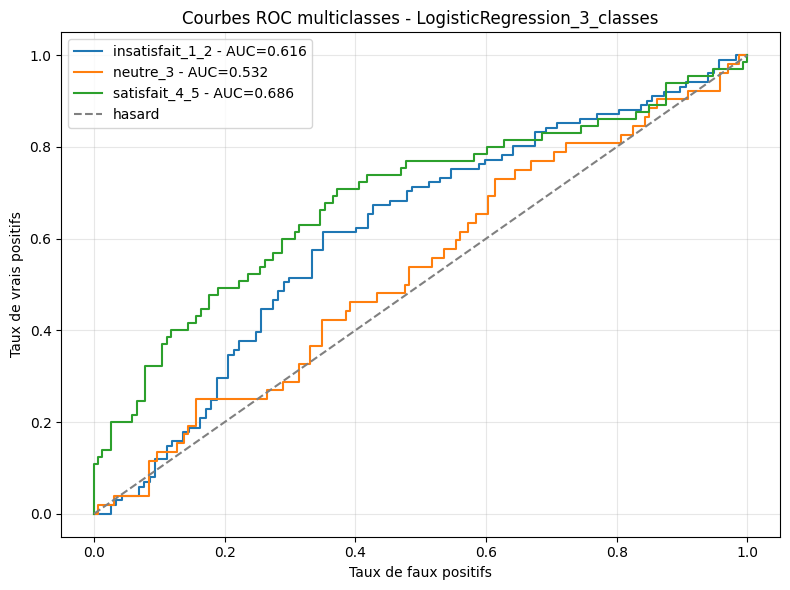

,indicateur,valeur,interpretation
0,nb_lignes_test,218.000000,Volume utilise pour mesurer l'inference
1,temps_inference_total_secondes,0.006650,Temps total de prediction sur le jeu de test
2,temps_inference_moyen_ms_ligne,0.030505,Temps moyen de prediction par ligne
3,cv_fit_time_moyen_secondes,0.031259,Temps moyen d'entrainement observe en validati...
4,cv_score_time_moyen_secondes,0.008037,Temps moyen d'evaluation observe en validation...


In [ ]:
# Analyse ROC multiclasses du modele post-voyage retenu.
# Le ROC complete accuracy / macro_f1 en evaluant la separation probabiliste des classes.
if hasattr(best_post_pipeline, "predict_proba"):
    y_score_post = best_post_pipeline.predict_proba(X_test_post)
    y_test_binarized = label_binarize(y_test_post, classes=labels_3_classes)

    roc_auc_macro_ovr = roc_auc_score(
        y_test_post,
        y_score_post,
        multi_class="ovr",
        average="macro",
    )
    roc_auc_weighted_ovr = roc_auc_score(
        y_test_post,
        y_score_post,
        multi_class="ovr",
        average="weighted",
    )

    roc_rows = [
        {
            "metrique": "roc_auc_ovr_macro",
            "valeur": roc_auc_macro_ovr,
            "interpretation": "Moyenne non ponderee des AUC par classe",
        },
        {
            "metrique": "roc_auc_ovr_weighted",
            "valeur": roc_auc_weighted_ovr,
            "interpretation": "Moyenne ponderee par le support des classes",
        },
    ]

    for class_index, class_label in enumerate(labels_3_classes):
        fpr, tpr, _ = roc_curve(y_test_binarized[:, class_index], y_score_post[:, class_index])
        roc_rows.append({
            "metrique": f"roc_auc_{labels_readable[class_index]}",
            "valeur": auc(fpr, tpr),
            "interpretation": "AUC one-vs-rest de la classe",
        })

    roc_auc_post = pd.DataFrame(roc_rows)
    display(roc_auc_post.round(4))

    plt.figure(figsize=(8, 6))
    for class_index, class_label in enumerate(labels_3_classes):
        fpr, tpr, _ = roc_curve(y_test_binarized[:, class_index], y_score_post[:, class_index])
        plt.plot(
            fpr,
            tpr,
            label=f"{labels_readable[class_index]} - AUC={auc(fpr, tpr):.3f}",
        )

    plt.plot([0, 1], [0, 1], "--", color="gray", label="hasard")
    plt.title(f"Courbes ROC multiclasses - {best_model_name}")
    plt.xlabel("Taux de faux positifs")
    plt.ylabel("Taux de vrais positifs")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Le modele retenu ne fournit pas predict_proba : ROC AUC non calculable.")

# Mesure simple du temps d'inference sur le jeu de test.
start_time = time.perf_counter()
_ = best_post_pipeline.predict(X_test_post)
inference_time_seconds = time.perf_counter() - start_time

performance_operationnelle_post = pd.DataFrame([
    {
        "indicateur": "nb_lignes_test",
        "valeur": len(X_test_post),
        "interpretation": "Volume utilise pour mesurer l'inference",
    },
    {
        "indicateur": "temps_inference_total_secondes",
        "valeur": inference_time_seconds,
        "interpretation": "Temps total de prediction sur le jeu de test",
    },
    {
        "indicateur": "temps_inference_moyen_ms_ligne",
        "valeur": inference_time_seconds / len(X_test_post) * 1000,
        "interpretation": "Temps moyen de prediction par ligne",
    },
    {
        "indicateur": "cv_fit_time_moyen_secondes",
        "valeur": cv_results_post["fit_time"].mean(),
        "interpretation": "Temps moyen d'entrainement observe en validation croisee",
    },
    {
        "indicateur": "cv_score_time_moyen_secondes",
        "valeur": cv_results_post["score_time"].mean(),
        "interpretation": "Temps moyen d'evaluation observe en validation croisee",
    },
])

display(performance_operationnelle_post.round(6))



## C5. Entraînement supervisé du modèle IA

#### Méthode d'entraînement retenue

| Element | Choix dans le projet | Justification |
| --- | --- | --- |
| Type d'apprentissage | Apprentissage supervisé | La cible `satisfaction_client` est connue dans l'historique des séjours |
| Probleme IA | Classification multiclasses | Le modèle post-voyage predit 3 classes : insatisfait, neutre, satisfait |
| Données d'entree | `X_post` | Variables pré-voyage + variables opérationnelles post-voyage autorisées |
| Donnee cible | `y_post` | `satisfaction_client` regroupee en 3 classes |
| Split | Train/test stratifié 80/20 | Conserve la distribution des classes dans train et test |
| Pipeline | Pretraitement + modèle dans `Pipeline` sklearn | Evite la fuite de données entre train et test pour imputation, traitement IQR des outliers, encodage et standardisation |
| Comparaison | Plusieurs modèles entraînés automatiquement dans une boucle | Permet de comparer objectivement les familles d'algorithmes |
| Validation | Test set + validation croisee | Verifie la performance sur un jeu non vu et la stabilite du modèle |

#### Optimisations testees

| Optimisation testee | Objectif | Décision actuelle |
| --- | --- | --- |
| `class_weight="balanced"` | Limiter l'effet du deséquilibre des classes | Utilise dans les modèles compatibles |
| RandomForest regularise | Reduire l'overfitting par une profondeur faible et des feuilles plus larges | Conserve comme expérience anti-overfitting |
| SMOTE pré-voyage | Tester un reequilibrage artificiel sur la cible 3 classes | Non retenu automatiquement : le gain observé après simplification reste faible et doit être valide |
| SMOTE post-voyage | Tester un reequilibrage artificiel sur un probleme contenant plus de signal | Candidat d'amélioration, a confirmer avant industrialisation |
| Optuna anti-overfitting | Automatiser la recherche d'hyperparamêtres avec penalite sur l'ecart train/validation et la complexite | Teste comme contrôle methodologique |
| XGBoost optimise | Tester une famille boosting performante sur tabulaire | Teste, a retenir uniquement si le gain justifie la complexite |
| NLP pre-entraîné | Exploiter `retour_client` | Non retenu dans le modèle principal pour éviter une fuite directe du ressenti client |

#### Réentraînement et transfert de connaissances

| Entraînement | Application dans ce projet |
| --- | --- |
| Modèle entraîné | Oui : les modèles sont entraînés avec `.fit()` sur `X_train_post`, `y_train_post` via un pipeline supervisé |
| Modèle reentraîné | Oui pour les experimentations : chaque modèle compare ou teste est reentraîné sur le meme jeu train |
| Réentraînement futur | Prevu lorsque de nouvelles données ou de nouvelles regles de nettoyage seront validees |
| Transfert de connaissances | Non applicable au modèle principal tabulaire : les modèles sklearn ne transferent pas de poids d'un modèle à l'autre |
| Transfert via modèle pre-entraîné | Teste conceptuellement avec NLP / modèle de sentiment, mais non retenu dans le modèle principal en raison du risque de fuite de données |

#### Feature engineering mobilise pour l'entraînement

Le feature engineering est utilisé pour transformer des valeurs brutes en signaux métier plus exploitables :

- `budget_par_jour` : budget ramene à la durée du séjour ;
- `part_vol_budget` : poids du vol dans le budget total ;
- `sejour_long` : indicateur de séjour long ;
- `meteo_risque` : indicateur de météo potentiellement defavorable ;
- `hebergement_luxe` : indicateur derive du type d'hébergement ;
- `imprevu_present`, `imprevu_transport`, `imprevu_meteo` : variables post-voyage explicatives r?serv?es au mod?le post-voyage.

Les variables derivees reduisent la dependance a certaines valeurs brutes et rendent le dataset plus pertinent pour le cas d'usage métier. Les variables non retenues ou trop artificielles sont supprimees avant la modélisation.

#### Conclusion

Les modèles sont entraînés automatiquement et superviséement, compares avec des indicateurs adaptes, optimises de maniere proportionnee au contexte, puis documentes avec leurs hyperparamêtres. Le réentraînement continu et l'export industriel du pipeline restent des etapes futures d'industrialisation.



In [ ]:
def extraire_hyperparametres_modele(model) -> dict:
    params = model.get_params()
    hyperparametres_utiles = [
        "strategy",
        "max_iter",
        "class_weight",
        "n_estimators",
        "max_depth",
        "min_samples_leaf",
        "min_samples_split",
        "learning_rate",
        "subsample",
        "colsample_bytree",
        "random_state",
        "n_jobs",
    ]
    return {key: params.get(key) for key in hyperparametres_utiles if key in params}


resume_entrainement_post = pd.DataFrame([
    {
        "element": "type_apprentissage",
        "valeur": "supervise",
    },
    {
        "element": "probleme",
        "valeur": "classification multiclasses 3 classes",
    },
    {
        "element": "taille_train",
        "valeur": len(X_train_post),
    },
    {
        "element": "taille_test",
        "valeur": len(X_test_post),
    },
    {
        "element": "nb_features_post",
        "valeur": len(feature_columns_post),
    },
    {
        "element": "modele_retenu",
        "valeur": best_model_name,
    },
])

display(resume_entrainement_post)

hyperparametres_modeles_post = pd.DataFrame([
    {
        "modele": model_name,
        "hyperparametres": extraire_hyperparametres_modele(model),
    }
    for model_name, model in modeles_post.items()
])

display(hyperparametres_modeles_post)

if "comparison_post" in globals():
    print("Comparaison incluant les tests complementaires :")
    display(comparison_post.round(4))
else:
    print("Comparaison des modeles principaux :")
    display(results_post.round(4))


,element,valeur
0,type_apprentissage,supervise
1,probleme,classification multiclasses 3 classes
2,taille_train,870
3,taille_test,218
4,nb_features_post,27
5,modele_retenu,LogisticRegression_3_classes


,modele,hyperparametres
0,Dummy_majority_3_classes,"{'strategy': 'most_frequent', 'random_state': ..."
1,LogisticRegression_3_classes,"{'max_iter': 500, 'class_weight': 'balanced', ..."
2,RandomForest_regularise_3_classes,"{'class_weight': 'balanced', 'n_estimators': 1..."
3,RandomForest_Optuna_regularise_3_classes,"{'class_weight': 'balanced', 'n_estimators': 8..."


Comparaison incluant les tests complementaires :


,modele,accuracy,balanced_accuracy,macro_f1
0,RandomForest_3_classes_optimise_500,0.5000,0.4517,0.4451
1,RandomForest_3_classes_SMOTE,0.5092,0.4473,0.4414
2,LogisticRegression_3_classes,0.4587,0.4438,0.4392
3,ExtraTrees_3_classes_SMOTE,0.5000,0.4327,0.4242
4,LogisticRegression_3_classes_SMOTE,0.4495,0.4278,0.4236
5,RandomForest_regularise_3_classes,0.5459,0.4635,0.4152
6,XGBoost_3_classes_optimise,0.4312,0.3782,0.3709
7,Dummy_majority_3_classes,0.4633,0.3333,0.2111


## C6. Implémentation et intégration technique

Cette section documente la phase d'industrialisation du modèle **pré-voyage**. L'objectif est de passer d'un notebook d'expérimentation à une première chaîne exploitable : entraînement reproductible, export du pipeline, API de prédiction, logs, monitoring, détection de dérive et stratégie de réentraînement.

#### Schéma visuel de l'architecture

![Architecture d'industrialisation](../docs/architecture_industrialisation.svg)

#### Architecture fonctionnelle

```text
[Dataset brut CSV]
        |
        v
[train.py]
        |
        +--> [Nettoyage métier]
        +--> [Feature engineering pré-voyage]
        +--> [Pipeline sklearn : imputation + outliers + encodage + normalisation + modèle]
        |
        v
[Artefacts models/]
        |
        +--> model_pre_voyage.pkl
        +--> model_pre_voyage_metadata.json
        |
        v
[TravelMind API]
        |
        +--> /health
        +--> /predict
        +--> /monitoring/summary
        +--> /monitoring/drift
        +--> /monitoring/alerts
        |
        v
[Logs JSONL]
        |
        v
[Monitoring + alertes + stratégie de réentraînement]
```

#### Fichiers créés ou modifiés pour l'industrialisation

| Fichier / dossier | Rôle | Contenu principal | Statut |
| --- | --- | --- | --- |
| `train.py` | Script d'entraînement reproductible | Charge le CSV, prépare `X/y`, entraîne les modèles candidats, sélectionne le meilleur modèle pré-voyage et exporte les artefacts | En place |
| `app/modeling.py` | Logique ML centralisée | Nettoyage métier, feature engineering, pipeline sklearn, choix des modèles, export modèle, profil de référence d'entraînement | En place |
| `app/schemas.py` | Contrat API | Schémas Pydantic d'entrée `/predict` et de sortie de prédiction | En place |
| `app/predictor.py` | Service de prédiction | Charge `models/model_pre_voyage.pkl`, prépare les features d'inférence et retourne classe + probabilités | En place |
| `app/main.py` | TravelMind'API | Endpoints `/health`, `/predict`, `/monitoring/summary`, `/monitoring/drift`, `/monitoring/alerts` | En place |
| `app/monitoring.py` | Monitoring opérationnel | Logs JSONL, résumé monitoring, dérive, alertes et décision de réentraînement | En place |
| `tests/test_health.py` | Tests API | Vérifie `/health`, `/predict`, `/monitoring/summary`, `/monitoring/drift`, `/monitoring/alerts` | En place |
| `tests/test_modeling.py` | Tests ML | Vérifie le regroupement cible, les features pré-voyage, l'entraînement et le profil de référence | En place |
| `tests/test_monitoring.py` | Tests monitoring | Vérifie logs JSONL, résumé, dérive et règles d'alertes | En place |
| `docs/architecture_industrialisation.svg` | Schéma visuel | Représentation graphique du flux données → modèle → API → monitoring → réentraînement | En place |
| `docs/strategie_reentrainement.md` | Documentation de gouvernance | Seuils, décisions, conditions et processus de réentraînement | En place |
| `docker-compose.yml` | Exécution conteneurisée | Expose l'API sur `8001`, monte `./models` et `./logs` | En place |
| `Dockerfile` | Image API | Installe les dépendances et lance FastAPI avec Uvicorn | En place |
| `.github/workflows/ci-cd.yml` | CI/CD | Compile Python, lance les tests, valide le notebook et construit l'image Docker | En place |
| `README.md` | Documentation d'utilisation | Commandes locales, URLs, test API, monitoring et Docker | En place |

#### Artefacts générés localement

| Artefact | Généré par | Rôle | Versioning Git |
| --- | --- | --- | --- |
| `models/model_pre_voyage.pkl` | `python train.py` | Pipeline sklearn complet utilisé par l'API `/predict` | Non versionné, ignoré par `.gitignore` |
| `models/model_pre_voyage_metadata.json` | `python train.py` | Métadonnées : modèle retenu, métriques, features, classes, profil d'entraînement | Non versionné, ignoré par `.gitignore` |
| `logs/predictions/predictions.jsonl` | Appels `/predict` | Journal des prédictions, probabilités, confiance et entrées utilisateur | Non versionné, ignoré par `.gitignore` |
| `logs/codecarbon/` | Cellule CodeCarbon du notebook | Estimation d'empreinte carbone d'un entraînement | Non versionné, ignoré par `.gitignore` |
| `mlruns/`, `mlartifacts/`, `mlflow.db` | MLflow local | Traçabilité locale des expériences | Non versionné, ignoré par `.gitignore` |

#### Modéle industrialisé

| élément | Valeur |
| --- | --- |
| Objectif | Prédiction pré-voyage de la satisfaction client en 3 classes |
| Modéle exporté actuellement | `LogisticRegression_pre` |
| Cible | `satisfaction_client` regroupée en `insatisfait_1_2`, `neutre_3`, `satisfait_4_5` |
| Variables autorisées | Variables connues avant le séjour : profil client, budget, destination, saison, durée, hébergement, prix du vol, météo prévue, activité principale et features dérivées pré-voyage |
| Variables exclues | `imprevus`, `reorganisation_necessaire`, `respect_budget`, `retour_client` et features post-voyage dérivées |
| Raison de l'exclusion | Ces variables sont connues pendant ou après le séjour et créeraient une fuite de données pour un usage pré-voyage |
| Usage recommandé | Score indicatif d'aide à l'analyse, avec revue humaine |
| Usage interdit | Décision automatique individualisée sans validation humaine |

#### Endpoints locaux disponibles

| URL locale | Méthode | Rôle | Résultat attendu |
| --- | --- | --- | --- |
| `http://localhost:8001/health` | `GET` | Vérifier que l'API est démarrée | `{"status": "ok"}` |
| `http://localhost:8001/docs` | `GET` | Documentation Swagger interactive | Interface de test API |
| `http://localhost:8001/predict` | `POST` | Prédire la classe de satisfaction pré-voyage | Classe prédite, libellé, probabilités, métriques modèle |
| `http://localhost:8001/monitoring/summary` | `GET` | Résumer les prédictions journalisées | Volume, distribution, confiance moyenne, taux faible confiance |
| `http://localhost:8001/monitoring/drift` | `GET` | Comparer les entrées API au profil d'entraînement | Dérives numériques/catégorielles et alertes par variable |
| `http://localhost:8001/monitoring/alerts` | `GET` | Consolider monitoring + dérive en décision opérationnelle | `collect_predictions`, `monitor_and_review`, `review_and_prepare_retraining` ou `no_action` |

#### Commandes locales principales

| Action | Commande PowerShell | Objectif |
| --- | --- | --- |
| Activer l'environnement | `.\.venv\Scripts\Activate.ps1` | Utiliser les dépendances du projet |
| Installer les dépendances | `pip install -r requirements-dev.txt` | Préparer l'environnement local |
| Entraîner/exporter le modèle | `python train.py` | Générer `models/model_pre_voyage.pkl` et les métadonnées |
| Lancer l'API | `uvicorn app.main:app --reload --port 8001` | Servir l'API en local |
| Lancer les tests | `python -m pytest -q` | Vérifier API, pipeline et monitoring |
| Lire les logs | `Get-Content -Encoding UTF8 logs/predictions/predictions.jsonl -Tail 5` | Consulter les dernières prédictions |
| Lancer Docker | `docker compose up --build` | Démarrer l'API dans un conteneur |

#### Exemple de requête `/predict`

```json
{
  "client_type": "couple",
  "budget_total": 4200,
  "destination": "rome",
  "saison": "printemps",
  "duree_jours": 7,
  "type_hebergement": "hôtel",
  "prix_vol": 650,
  "meteo_prevue": "ensoleillé",
  "activite_principale": "culture"
}
```

#### Exemple de réponse `/predict`

```json
{
  "objective": "pre_voyage_satisfaction_3_classes",
  "model_name": "LogisticRegression_pre",
  "classe_predite": 2,
  "libelle_prediction": "satisfait_4_5",
  "probabilities": [
    {"classe": 0, "libelle": "insatisfait_1_2", "probabilite": 0.3815},
    {"classe": 1, "libelle": "neutre_3", "probabilite": 0.2138},
    {"classe": 2, "libelle": "satisfait_4_5", "probabilite": 0.4048}
  ],
  "model_metrics": {
    "accuracy": 0.3571,
    "balanced_accuracy": 0.3554,
    "macro_f1": 0.3491
  }
}
```

#### Contenu des logs de prédiction

Chaque appel réussi à `/predict` ajoute une ligne JSON dans `logs/predictions/predictions.jsonl`.

| Champ loggé | Signification |
| --- | --- |
| `timestamp_utc` | Date/heure de la prédiction |
| `objective` | Objectif du modèle servi |
| `model_name` | Modéle utilisé |
| `input` | Données pré-voyage envoyées à l'API |
| `classe_predite` | Classe numérique prédite |
| `libelle_prediction` | Libellé métier de la classe prédite |
| `probabilities` | Probabilités associées aux classes |
| `confidence` | Probabilité maximale parmi les classes |
| `low_confidence` | `true` si la confiance est inférieure à `0.50` |
| `model_metrics` | Métriques globales connues au moment de l'export |

#### Monitoring et alertes

| Endpoint | Indicateurs retournés | Utilisation métier |
| --- | --- | --- |
| `/monitoring/summary` | Nombre de prédictions, distribution des classes, taux de faible confiance, confiance moyenne | Vérifier le comportement global du modèle servi |
| `/monitoring/drift` | écart des variables numériques et catégorielles par rapport au profil d'entraînement | Détecter un changement de population ou de contexte d'usage |
| `/monitoring/alerts` | Décision opérationnelle et recommandations | Savoir s'il faut collecter plus de données, surveiller, revoir humainement ou préparer un réentraînement |

#### Seuils d'alerte retenus

| Indicateur | Warning | Critical | Action |
| --- | ---: | ---: | --- |
| Volume de prédictions | `< 20` | Non applicable | Ne pas conclure, collecter davantage de logs |
| Faible confiance | `>= 40 %` | `>= 60 %` | Revue humaine des prédictions |
| Dérive numérique | écart moyen normalisé `>= 1.0` | `>= 2.0` | Analyser la variable concernée |
| Dérive catégorielle | Distance de distribution `>= 0.20` | `>= 0.35` | Analyser le segment surreprésenté |

#### Décisions possibles de `/monitoring/alerts`

| Décision | Signification | Action recommandée |
| --- | --- | --- |
| `collect_predictions` | Aucun log disponible | Générer des appels `/predict` avant analyse |
| `monitor_and_review` | Alerte ou volume insuffisant | Continuer la collecte et faire une revue humaine |
| `review_and_prepare_retraining` | Alerte critique avec volume suffisant | Préparer un réentraînement après validation métier |
| `no_action` | Pas d'alerte significative | Continuer le suivi périodique |

#### CI/CD et validation continue

| étape CI/CD | Rôle |
| --- | --- |
| `python -m compileall app tests train.py` | Vérifier la syntaxe Python |
| `pytest -q` | Lancer les tests API, ML et monitoring |
| Validation notebook | Parser les cellules code du notebook final avec `ast` |
| Build Docker | Vérifier que l'image API peut être construite |

#### Conteneurisation Docker

| élément | Rôle |
| --- | --- |
| `Dockerfile` | Construit l'image Python/FastAPI |
| `docker-compose.yml` | Lance le service API sur le port local `8001` |
| Volume `./models:/app/models:ro` | Rend le modèle exporté disponible dans le conteneur en lecture seule |
| Volume `./logs:/app/logs` | Conserve les logs de prédiction hors du conteneur |

Avant de lancer Docker, il faut générer le modèle localement :

```powershell
python train.py
docker compose up --build
```

#### Limites actuelles de l'industrialisation

- Le modèle pré-voyage à une performance modeste ; il doit rester un outil d'aide à l'analyse.
- Le suivi de performance réelle nécessite des retours clients post-séjour avec satisfaction observée.
- Le réentraînement n'est pas automatique : il doit passer par une revue métier et une validation des nouvelles données.
- Les artefacts `models/`, `logs/` et `mlruns/` sont locaux et non versionnés.
- Les alertes de dérive sont peu fiables tant que le volume de prédictions journalisées est faible.


## C7. Évaluation de l'architecture cible

Cette section complete l'industrialisation en evaluant la pertinence de l'architecture cible. Elle couvre les scenarios possibles, les contraintes techniques et économiques, les acteurs ressources a consulter et la decision d'architecture retenue pour le projet.

#### Objectif de l'évaluation d'architecture

L'objectif n'est pas uniquement de faire fonctionner le modèle. Il faut choisir une architecture adaptee au contexte du projet : agence de voyages haut de gamme, modèle pré-voyage a performance modeste, besoin de demonstration, supervision humaine obligatoire, budget maitrise et possibilite d'évolution progressive.

#### Scenarios d'architecture etudies

| Scenario | Description | Avantages | Contraintes / limites | Pertinence pour le projet |
| --- | --- | --- | --- | --- |
| Notebook seul | Utilisation du notebook final pour tester le modèle | Simple, rapide, faible cout | Non utilisable facilement par un profil métier, pas d'API, pas de monitoring reel | Adapte uniquement à l'experimentation |
| Script local `train.py` | Entraînement reproductible en ligne de commande | Reproductible, simple, tracable | Necessite Python et l'environnement projet | Pertinent pour figer l'entraînement |
| TravelMind'API locale | Exposition du modèle via `/predict` | Separe modèle et usage, testable via Swagger | Reste local, necessite le modèle exporte | Tres pertinent pour prototype industrialisable |
| API + Docker local | Execution reproductible dans un conteneur | Portabilite, isolation, proche production | Necessite Docker, gestion des volumes `models/` et `logs/` | Pertinent pour demonstration et passage sur autre poste |
| TravelMind Dashboard local | Interface TravelMind de test métier et dashboard KPI | Simple pour saisir un voyage, tester un CSV et suivre les KPI métier | Interface de demonstration, pas concue pour forte charge | Tres pertinent pour validation métier |
| Serveur VPS | Deploiement sur serveur Linux avec Docker | Accessible a distance, cout previsible | Administration serveur, securite, sauvegardes, supervision | Option pertinente après validation métier |
| Cloud manage | Deploiement sur service cloud type Azure, AWS ou GCP | Scalabilite, supervision avancee, services manages | Cout plus eleve, configuration plus complexe, dependance fournisseur | Non prioritaire pour ce prototype |
| Architecture MLOps complete | Registry modèle, orchestration, monitoring avance, réentraînement automatise | Robuste pour production réelle | Surdimensionne, couteux, necessite une equipe technique | A envisager uniquement en cas de passage à l'echelle |

#### Contraintes techniques identifiées

| Contrainte | Impact sur l'architecture | Décision retenue |
| --- | --- | --- |
| Sobriete et maintenabilite | Éviter les modèles lourds et les traitements couteux | Modèles scikit-learn legers, pas de modèle NLP lourd en production pré-voyage |
| Performance modeste du modèle pré-voyage | Ne pas automatiser une decision client | Usage comme aide à l'analyse avec supervision humaine |
| Variables post-voyage indisponibles avant départ | Risque de fuite de données | Exclusion stricte de `imprevus`, `respect_budget`, `reorganisation_necessaire`, `retour_client` |
| Artefacts locaux non versionnes | Le modèle doit être regenere sur un autre poste | `python train.py` regenere `models/model_pre_voyage.pkl` |
| Besoin de demonstration métier | Les utilisateurs non techniques doivent pouvoir tester et lire les KPI | TravelMind Dashboard local avec dashboard KPI |
| Besoin de traçabilité | Les prédictions doivent être auditables | Logs JSONL et endpoints de monitoring |
| Besoin de portabilite | Le projet doit fonctionner sur un autre PC | GitHub, `requirements-dev.txt`, Docker Compose |
| Données synthétiques | Generalisation limitee | Documentation des limites et validation métier avant données réelles |

#### Contraintes économiques des scenarios

| Scenario | Cout estimatif | Couts caches / vigilance | Lecture économique |
| --- | ---: | --- | --- |
| Notebook local | Quasi nul | Temps manuel, dependance au profil technique | Acceptable pour exploration uniquement |
| API locale + Streamlit | Quasi nul | Installation Python, maintenance locale | Meilleur compromis pour prototype et demonstration |
| Docker local | Quasi nul si Docker Desktop disponible | Configuration Docker, ressources machine | Pertinent pour reproductibilite |
| VPS simple | Environ 5 a 20 euros par mois | Securite, sauvegardes, mises à jour, nom de domaine eventuel | Pertinent si acces distant nécessaire |
| Cloud manage | Variable, souvent superieur au VPS | Monitoring, stockage, reseau, logs, services manages | A reserver à un besoin de production réelle |
| MLOps complet | Cout technique et humain eleve | Registry, orchestration, observabilite, gouvernance | Non proportionne au stade actuel |

Les contraintes économiques doivent être présentées au commanditaire avant tout passage à une architecture distante. Pour ce projet, le meilleur rapport valeur / cout est l'architecture locale : TravelMind'API + Streamlit + Docker optionnel.

#### Acteurs ressources a consulter

| Acteur | Questions a poser | Décision attendue |
| --- | --- | --- |
| Commanditaire métier | Usage reel attendu : aide conseiller, scoring interne, comparaison d'offres | Valider que le modèle reste un outil d'aide, pas une decision automatique |
| Conseillers voyage | Les champs d'entree correspondent-ils au processus de vente | Ajuster formulaire, libelles et seuils de confiance |
| Acteur technique / DSI | Ou heberger l'API, quel niveau de securite et de disponibilite | Choisir local, serveur interne, VPS ou cloud |
| Juriste / DPO | Impact RGPD si données clients réelles, durée de conservation, information client | Valider la conformité avant données réelles |
| Responsable financier | Budget disponible pour hébergement, maintenance et monitoring | Arbitrer entre prototype local, VPS ou cloud manage |
| Responsable qualité / direction | KPI a suivre : satisfaction, faible confiance, derive, retours conseiller | Valider les indicateurs et seuils d'alerte |

#### Questions a valider avant generalisation

| Theme | Question | Statut actuel |
| --- | --- | --- |
| Usage métier | Le modèle doit-il recommander, alerter ou seulement informer | A valider avec le commanditaire |
| Performance attendue | Niveau minimum acceptable de `macro_f1`, `balanced_accuracy` ou confiance | Non valide, modèle actuel modeste |
| Données réelles | Le dataset synthétique sera-t-il remplace par des historiques clients | A confirmer |
| Securite | L'API sera-t-elle exposee hors poste local | Non retenu à ce stade |
| Cout | Un budget serveur mensuel est-il disponible | Non nécessaire pour prototype local |
| Maintenance | Qui relance `train.py`, surveille les logs et valide les alertes | A attribuer avant production |
| Gouvernance | Qui autorisé le remplacement d'un modèle par une nouvelle version | A formaliser |

#### Architecture cible retenue pour le projet actuel

L'architecture retenue est volontairement progressive :

```text
Notebook final documente
        + train.py reproductible
        + modele pre-voyage exporte
        + TravelMind API locale
        + TravelMind Dashboard locale
        + Docker Compose optionnel
        + logs JSONL
        + monitoring / derive / alertes
```

Cette architecture est pertinente car elle :

- repond au besoin de demonstration et de test métier ;
- reste économiquement legere ;
- fonctionne sur un poste local ou un autre PC via GitHub ;
- evite de surdimensionner le projet avec du cloud ou du MLOps complet ;
- permet une évolution future vers serveur ou cloud si le commanditaire valide l'interet métier ;
- tient compté des limites du modèle pré-voyage en imposant une supervision humaine.

#### Décision C7

La competence C7 est couverte pour le perimêtre prototype / certification : les principales architectures possibles sont comparees, leurs contraintes techniques et économiques sont explicitees, les acteurs a consulter sont identifiés, et une architecture cible proportionnee est retenue.

Avant une generalisation réelle, il restera nécessaire d'interroger formellement le commanditaire, les utilisateurs métier, la DSI et le DPO afin de confirmer les contraintes de performance, securite, cout, maintenance et conformité.



## C8. Mesure de performance et impacts de la solution IA

Cette section regroupe les preuves liees à la mesure de performance et aux impacts de la solution IA. Elle s'appuie sur les résultats de modélisation, le monitoring API, la Model Card, CodeCarbon et les mesures éthiques.

#### Indicateurs et seuils définis

| Famille | Indicateur | Seuil ou interprétation | Preuve |
| --- | --- | --- | --- |
| Performance globale | `accuracy` | Score secondaire, a interpréter avec prudence si classes deséquilibrées | Résultats pré-voyage et post-voyage |
| Performance équilibrée | `balanced_accuracy` | Doit être superieur au modèle naif | Comparaisons de modèles |
| Robustesse multi-classes | `macro_f1` | Indicateur principal car les classes sont deséquilibrées | Validation croisee, rapports de classification |
| Diagnostic erreurs | Matrice de confusion | Identifier les classes confondues | Matrice du modèle retenu |
| Robustesse | Validation croisee | Comparer score moyen et dispersion | Sections validation croisee |
| Suivi opérationnel | `low_confidence_rate` | Alerte si beaucoup de prédictions peu confiantes | `/monitoring/summary`, `/monitoring/alerts` |
| Derive données | `numeric_drift`, `categorical_drift` | Warning / critical selon seuils de monitoring | `/monitoring/drift` |
| Impact environnemental | CO2e estime | Mesure indicative de sobriete numérique | Section CodeCarbon |
| Impact societal | Ecarts par sous-groupes | Signal d'alerte, pas preuve automatique de discrimination | Mesures éthiques et sociétales |

#### Suivi et presentation aux interlocuteurs

| Interlocuteur | Information présentée | Objectif |
| --- | --- | --- |
| Commanditaire | Scores, limites, comparaison pré-voyage / post-voyage | Decider si le modèle est utilisable comme aide à l'analyse |
| Conseillers voyage | Prédiction, probabilites, faible confiance | Savoir quand relire manuellement la recommandation |
| Equipe data / technique | Logs, derive, erreurs, quality gate | Maintenir le modèle et éviter les regressions |
| DPO / juridique | RGPD, biais, usage non decisionnel | Vérifier la conformité et les risques |
| Direction / finance | Cout, architecture, empreinte carbone | Arbitrer entre prototype, Docker, serveur ou MLOps complet |

#### Actions declenchees selon les indicateurs

| Signal observé | Action |
| --- | --- |
| `macro_f1` sous le seuil CI/CD | Bloquer la livraison et analyser la regression |
| Taux eleve de faible confiance | Revue humaine des prédictions concernees |
| Derive critique confirmee | Préparer un réentraînement après validation métier |
| Performance faible sur un sous-groupe | Examiner représentativité et erreurs de ce segment |
| Empreinte carbone excessive | Limiter les experimentations lourdes et privilegier modèles tabulaires simples |

#### Limite de mesure

La performance réelle en exploitation ne pourra être confirmee qu'avec de nouvelles données annotees après séjour. Le monitoring actuel mesure les prédictions, la confiance et la derive des entrees ; il ne remplace pas une mesure future de satisfaction client observée.




### C8.1 Model Card - fiche du modèle retenu

Cette fiche documente le modèle post-voyage retenu pour la suite du projet. Elle doit être mise à jour à chaque changement de données, de variables, d'algorithme ou d'hyperparamêtres.

### Détails du modèle

| Element | Description |
| --- | --- |
| Objectif | Predire / expliquer la satisfaction client après séjour en 3 classes |
| Cible | `satisfaction_client` regroupee en `0 = insatisfait`, `1 = neutre`, `2 = satisfait` |
| Sélection du modèle | Meilleur modèle selon `macro_f1` dans `results_post`, après nettoyage strict |
| Pretraitement | Imputation, remplacement IQR des outliers numériques continus, encodage OneHot des variables catégorielles et standardisation via `ColumnTransformer` |
| Variables utilisées | Variables pré-voyage + variables post-voyage explicatives (`imprevus`, `reorganisation_necessaire`, `respect_budget`) |
| Variables exclues | `trip_id`, `satisfaction_client`, `retour_client` brut |
| Split d'évaluation | Train/test stratifié, 80 % entraînement et 20 % test |
| Validation complémentaire | Validation croisee a 3 plis, matrice de confusion, rapport de classification, ROC multiclasses si `predict_proba` disponible |

### Architecture et hyperparamêtres

L'architecture retenue est un pipeline `scikit-learn` :

1. `ColumnTransformer` pour séparér variables numériques et catégorielles ;
2. imputation, remplacement IQR des outliers continus et standardisation des numériques ;
3. imputation et encodage OneHot des catégorielles ;
4. classifieur supervisé sélectionne par comparaison empirique.

Les hyperparamêtres exacts du modèle retenu sont extraits automatiquement dans la section d'entraînement via `extraire_hyperparametres_modele(best_post_pipeline)`.

### Performances globales

Les performances globales ne sont pas figees dans cette fiche, car elles changent après chaque modification du nettoyage ou du feature engineering. Elles sont affichees dans :

- `results_post` pour les modèles simples ;
- `comparison_post` pour les tests complémentaires ;
- `cv_summary_post` pour la validation croisee ;
- `overfitting_diagnostic` pour l'ecart train/test ;
- `report_post` et `confusion_post` pour le détail par classe.

Après le nettoyage strict et le deplacement des pretraitements dans le pipeline, le meilleur modèle simple obtient un `macro_f1` test autour de `0.44`. Optuna obtient environ `0.3983` en test et `0.3854` en validation croisee sur RandomForest, donc il n'est pas retenu. Les tests complémentaires peuvent monter plus haut sur le split test, mais la validation croisee SMOTE reste moderee autour de `0.41`. Ces options doivent donc être confirmees avant industrialisation.

### Performances par sous-groupes

La cellule suivante calcule les performances par sous-groupes métier. Les résultats doivent être interpretes avec prudence lorsque le `support` est faible.

### Empreinte carbone et sobriete numérique

L'empreinte carbone du modèle est mesuree dans la cellule suivante avec `CodeCarbon`. La mesure reste une estimation : elle depend de la machine, de la durée d'exécution, de la consommation CPU/GPU et du facteur carbone du pays retenu. Pour ce prototype, le facteur pays est fixe a `FRA` car l'exécution est supposee locale en France ; il doit être adapte si l'entraînement est réalisé ailleurs.

| Element | Évaluation projet |
| --- | --- |
| Type de modèle | Modèle tabulaire `scikit-learn`, beaucoup moins couteux qu'un modèle deep learning |
| Volume de données | Faible volume, environ 1500 séjours avant nettoyage |
| Infrastructuré | Execution locale CPU, pas de GPU ni de cluster distant |
| Experiments lourds | NLP et augmentations massives non retenus dans le modèle principal |
| Mesure CO2e | Estimee par `CodeCarbon` sur un réentraînement du pipeline retenu |
| Mesures de reduction | Limiter les grilles d'hyperparamêtres, utilisér `n_jobs=1`, éviter les tests inutiles, privilegier la validation croisee ciblee |

Dans le cadre de ce projet, le choix d'un pipeline tabulaire simple est coherent avec une approche sobre : il repond au besoin de comparaison et d'explicabilite sans mobiliser de modèle lourd. En production, cette mesure devra être tracee dans MLflow ou dans un registre de monitoring avec la version du modèle, la durée d'entraînement, l'energie estimee et les emissions CO2e par run.

### Considerations éthiques et biais identifiés

- Le dataset est synthétique : il ne garantit pas une représentativité réelle des clients, destinations ou profils de voyageurs.
- Les variables comme `budget_total`, `destination`, `client_type` ou `type_hebergement` peuvent introduire des biais socio-économiques dans les recommandations.
- Le modèle post-voyage utilisé des evenements observés pendant ou après le séjour ; il ne doit pas être présenté comme un outil de prédiction avant départ.
- Les décisions commerciales ne doivent pas être automatisees uniquement à partir du score du modèle. Le résultat doit rester une aide à l'analyse.
- En cas d'utilisation de données réelles, les exigences RGPD, l'anonymisation et le contrôle des acces deviennent obligatoires.

### Cas d'usage recommandes

- Identifier les facteurs associes à une satisfaction faible après séjour.
- Prioriser les dossiers necessitant une analyse qualité ou une action corrective.
- Comparer l'impact des imprevus, du respect du budget et des reorganisations sur l'expérience client.
- Alimenter une démarche d'amélioration continue des offres de voyages.

### Limitations

- Les performances restent moderees : le modèle est exploitable pour l'analyse, mais insuffisant pour une decision automatique individuelle.
- La prédiction de la classe `neutre` reste fragile.
- Le modèle depend fortement de variables post-voyage ; il ne repond donc pas au besoin pré-voyage de personnalisation avant départ.
- Les options d'augmentation de données comme SMOTE doivent être validees métier, car elles créént des exemples artificiels.
- Les résultats doivent être reévalués après tout enrichissement du dataset, ajout de données réelles ou changement de cible métier.




### C8.2 Mesure CodeCarbon du modèle retenu

Cette cellule mesure l empreinte carbone estimee d un réentraînement du pipeline post-voyage retenu. Elle créé un rapport `codecarbon_report` et sauvegarde aussi un fichier CSV dans `logs/codecarbon/`.

La mesure est volontairement séparée de l entraînement principal : elle sert a documenter le cout environnemental du modèle retenu sans modifier le jeu de test ni la logique d évaluation.



In [ ]:
# Mesure optionnelle de l empreinte carbone avec CodeCarbon.
# Si CodeCarbon n est pas installe, installer la dependance : pip install codecarbon

codecarbon_available = OfflineEmissionsTracker is not None

if not codecarbon_available:
    codecarbon_report = pd.DataFrame([
        {
            "statut": "CodeCarbon non installe",
            "action": "Installer codecarbon puis relancer cette cellule",
            "commande": "pip install codecarbon",
        }
    ])
    display(codecarbon_report)
else:
    codecarbon_output_dir = PROJECT_ROOT / "logs" / "codecarbon"
    codecarbon_output_dir.mkdir(parents=True, exist_ok=True)

    codecarbon_output_file = "emissions_notebook_final.csv"
    country_iso_code = "FRA"  # A adapter si l entrainement est execute hors France.

    pipeline_codecarbon = clone(best_post_pipeline)

    tracker = OfflineEmissionsTracker(
        project_name="travelmind_satisfaction",
        country_iso_code=country_iso_code,
        output_dir=str(codecarbon_output_dir),
        output_file=codecarbon_output_file,
        log_level="error",
    )

    start_time = time.perf_counter()
    tracker.start()
    pipeline_codecarbon.fit(X_train_post, y_train_post)
    emissions_kg_co2e = tracker.stop()
    training_duration_seconds = time.perf_counter() - start_time

    emissions_file = codecarbon_output_dir / codecarbon_output_file
    emissions_details = pd.read_csv(emissions_file).tail(1) if emissions_file.exists() else pd.DataFrame()

    codecarbon_report = pd.DataFrame([
        {
            "modele": best_post_model_name,
            "pays_facteur_carbone": country_iso_code,
            "duree_entrainement_secondes": training_duration_seconds,
            "emissions_kg_co2e": emissions_kg_co2e,
            "emissions_g_co2e": emissions_kg_co2e * 1000 if emissions_kg_co2e is not None else np.nan,
            "fichier_codecarbon": str(emissions_file),
        }
    ])

    display(codecarbon_report.round(8))

    colonnes_details = [
        colonne
        for colonne in ["timestamp", "duration", "emissions", "emissions_rate", "cpu_power", "ram_power", "energy_consumed"]
        if colonne in emissions_details.columns
    ]
    if colonnes_details:
        display(emissions_details[colonnes_details])


In [ ]:
def evaluer_performance_sous_groupes(X_test, y_true, y_pred, colonnes_sous_groupes, min_support=20):
    donnees_eval = X_test.reset_index(drop=True).copy()
    y_true_eval = pd.Series(y_true).reset_index(drop=True)
    y_pred_eval = pd.Series(y_pred).reset_index(drop=True)

    lignes = []
    for colonne in colonnes_sous_groupes:
        if colonne not in donnees_eval.columns:
            continue

        serie_sous_groupe = donnees_eval[colonne].fillna("valeur_manquante")
        serie_sous_groupe = serie_sous_groupe.map(
            lambda valeur: tuple(valeur) if isinstance(valeur, list) else valeur
        )
        for valeur, index_groupe in serie_sous_groupe.groupby(serie_sous_groupe).groups.items():
            index_groupe = list(index_groupe)
            support = len(index_groupe)
            if support < min_support:
                continue

            y_true_groupe = y_true_eval.loc[index_groupe]
            y_pred_groupe = y_pred_eval.loc[index_groupe]

            lignes.append({
                "sous_groupe": colonne,
                "valeur": valeur,
                "support": support,
                "accuracy": accuracy_score(y_true_groupe, y_pred_groupe),
                "balanced_accuracy": balanced_accuracy_score(y_true_groupe, y_pred_groupe),
                "macro_f1": f1_score(
                    y_true_groupe,
                    y_pred_groupe,
                    labels=labels_3_classes,
                    average="macro",
                    zero_division=0,
                ),
            })

    return (
        pd.DataFrame(lignes)
        .sort_values(["sous_groupe", "macro_f1"], ascending=[True, False])
        .reset_index(drop=True)
    )


colonnes_sous_groupes_model_card = [
    "client_type",
    "respect_budget",
    "imprevus",
    "reorganisation_necessaire",
    "meteo_prevue",
]

performances_sous_groupes_post = evaluer_performance_sous_groupes(
    X_test_post,
    y_test_post,
    best_predictions,
    colonnes_sous_groupes_model_card,
    min_support=20,
)

display(performances_sous_groupes_post.round(4))


,sous_groupe,valeur,support,accuracy,balanced_accuracy,macro_f1
0,client_type,business,48,0.5625,0.5516,0.5507
1,client_type,senior,46,0.5435,0.5180,0.5198
2,client_type,couple,50,0.4400,0.4046,0.3881
3,client_type,famille,25,0.4400,0.4000,0.3861
4,client_type,solo,49,0.3061,0.2934,0.2750
5,imprevus,annulation,23,0.6522,0.5778,0.5831
6,imprevus,retard_vol,58,0.4828,0.3835,0.3786
7,imprevus,météo,48,0.3750,0.3462,0.3473
8,imprevus,aucun,69,0.4928,0.4002,0.3359
9,imprevus,bagages,20,0.2500,0.1515,0.1333


### C8.3 Mesures éthiques et sociétales du modèle

Cette section ajoute des métriques quantitatives pour compléter l analyse des enjeux éthiques et sociétaux. Elles ne remplacent pas une validation juridique ou métier, mais elles permettent de détecter des écarts de comportement du modèle selon certains sous-groupes.

Les variables utilisées ici ne sont pas des variables protégées au sens strict. Elles sont utilisées comme **proxys métier** : `client_type`, `destination`, `type_hebergement`, `respect_budget`, `imprevus` et `reorganisation_necessaire`. Les résultats doivent donc être interprétés comme des signaux de vigilance, pas comme une preuve définitive de discrimination.

Les métriques calculées sont :

- écart de performance `macro_f1` entre sous-groupes ;
- écart de taux de prédiction de la classe `satisfait` ;
- écart entre taux réel et taux prédit de satisfaction ;
- rappel et précision de la classe `satisfait` par groupe ;
- taux d erreur par groupe ;
- taux de supervision humaine recommandé lorsque la confiance du modèle est faible.



In [ ]:
# Mesures quantitatives des enjeux éthiques et sociétaux.
# Ces mesures sont calculées sur le jeu de test du modèle post-voyage retenu.

def calculer_metriques_equite_sous_groupes(
    X_test,
    y_true,
    y_pred,
    colonnes_sous_groupes,
    y_proba=None,
    classe_positive=2,
    seuil_confiance_supervision=0.60,
    min_support=20,
):
    donnees_eval = X_test.reset_index(drop=True).copy()
    y_true_eval = pd.Series(y_true).reset_index(drop=True)
    y_pred_eval = pd.Series(y_pred).reset_index(drop=True)

    if y_proba is not None:
        confiance_prediction = pd.Series(np.max(y_proba, axis=1))
    else:
        confiance_prediction = pd.Series([np.nan] * len(y_pred_eval))

    lignes = []
    for colonne in colonnes_sous_groupes:
        if colonne not in donnees_eval.columns:
            continue

        serie_sous_groupe = donnees_eval[colonne].fillna("valeur_manquante")
        serie_sous_groupe = serie_sous_groupe.map(
            lambda valeur: tuple(valeur) if isinstance(valeur, list) else valeur
        )
        for valeur, index_groupe in serie_sous_groupe.groupby(serie_sous_groupe).groups.items():
            index_groupe = list(index_groupe)
            support = len(index_groupe)
            if support < min_support:
                continue

            y_true_groupe = y_true_eval.loc[index_groupe]
            y_pred_groupe = y_pred_eval.loc[index_groupe]
            confiance_groupe = confiance_prediction.loc[index_groupe]

            vrais_satisfaits = y_true_groupe == classe_positive
            predits_satisfaits = y_pred_groupe == classe_positive
            nb_vrais_satisfaits = int(vrais_satisfaits.sum())
            nb_predits_satisfaits = int(predits_satisfaits.sum())

            rappel_satisfait = (
                ((y_pred_groupe[vrais_satisfaits] == classe_positive).mean())
                if nb_vrais_satisfaits > 0
                else np.nan
            )
            precision_satisfait = (
                ((y_true_groupe[predits_satisfaits] == classe_positive).mean())
                if nb_predits_satisfaits > 0
                else np.nan
            )

            lignes.append({
                "variable_sous_groupe": colonne,
                "valeur": valeur,
                "support": support,
                "accuracy": accuracy_score(y_true_groupe, y_pred_groupe),
                "macro_f1": f1_score(
                    y_true_groupe,
                    y_pred_groupe,
                    labels=labels_3_classes,
                    average="macro",
                    zero_division=0,
                ),
                "taux_erreur": (y_true_groupe != y_pred_groupe).mean(),
                "taux_reel_satisfait": vrais_satisfaits.mean(),
                "taux_predit_satisfait": predits_satisfaits.mean(),
                "ecart_predit_vs_reel_satisfait": predits_satisfaits.mean() - vrais_satisfaits.mean(),
                "recall_satisfait_equal_opportunity": rappel_satisfait,
                "precision_satisfait_predictive_parity": precision_satisfait,
                "confiance_moyenne": confiance_groupe.mean(),
                "taux_supervision_humaine_recommande": (
                    (confiance_groupe < seuil_confiance_supervision).mean()
                    if confiance_groupe.notna().any()
                    else np.nan
                ),
            })

    return (
        pd.DataFrame(lignes)
        .sort_values(["variable_sous_groupe", "macro_f1"], ascending=[True, False])
        .reset_index(drop=True)
    )


def qualifier_risque_ecart(ecart):
    if pd.isna(ecart):
        return "non calculable"
    if ecart >= 0.25:
        return "élevé"
    if ecart >= 0.15:
        return "modéré"
    return "faible"


def calculer_ecarts_equite(metriques_sous_groupes):
    metriques_ecart = [
        "macro_f1",
        "taux_erreur",
        "taux_predit_satisfait",
        "ecart_predit_vs_reel_satisfait",
        "recall_satisfait_equal_opportunity",
        "precision_satisfait_predictive_parity",
        "taux_supervision_humaine_recommande",
    ]

    lignes = []
    for variable, groupe in metriques_sous_groupes.groupby("variable_sous_groupe"):
        ligne = {
            "variable_sous_groupe": variable,
            "nb_modalites_evaluees": groupe["valeur"].nunique(),
            "support_min": groupe["support"].min(),
            "support_max": groupe["support"].max(),
        }

        ecarts_principaux = []
        for metrique in metriques_ecart:
            valeurs_valides = groupe[metrique].dropna()
            ecart = valeurs_valides.max() - valeurs_valides.min() if len(valeurs_valides) > 1 else np.nan
            ligne[f"ecart_max_min_{metrique}"] = ecart
            if metrique in [
                "macro_f1",
                "taux_predit_satisfait",
                "recall_satisfait_equal_opportunity",
                "precision_satisfait_predictive_parity",
            ]:
                ecarts_principaux.append(ecart)

        ecart_reference = np.nanmax(ecarts_principaux) if not all(pd.isna(ecart) for ecart in ecarts_principaux) else np.nan
        ligne["ecart_reference"] = ecart_reference
        ligne["niveau_risque_equite"] = qualifier_risque_ecart(ecart_reference)
        if ligne["niveau_risque_equite"] == "élevé":
            ligne["action_recommandee"] = "analyse métier prioritaire et validation avant usage"
        elif ligne["niveau_risque_equite"] == "modéré":
            ligne["action_recommandee"] = "surveillance et analyse des causes"
        else:
            ligne["action_recommandee"] = "surveillance standard"
        lignes.append(ligne)

    return (
        pd.DataFrame(lignes)
        .sort_values("ecart_reference", ascending=False)
        .reset_index(drop=True)
    )


if hasattr(best_post_pipeline, "predict_proba"):
    y_proba_ethique = best_post_pipeline.predict_proba(X_test_post)
else:
    y_proba_ethique = None

colonnes_sous_groupes_ethique = [
    "client_type",
    "destination",
    "type_hebergement",
    "respect_budget",
    "imprevus",
    "reorganisation_necessaire",
]

metriques_ethiques_sous_groupes = calculer_metriques_equite_sous_groupes(
    X_test_post,
    y_test_post,
    best_predictions,
    colonnes_sous_groupes_ethique,
    y_proba=y_proba_ethique,
    seuil_confiance_supervision=0.60,
    min_support=20,
)

ecarts_equite_post = calculer_ecarts_equite(metriques_ethiques_sous_groupes)

print("Métriques éthiques par sous-groupe :")
display(metriques_ethiques_sous_groupes.round(4))

print("Synthèse des écarts entre sous-groupes :")
display(ecarts_equite_post.round(4))

if y_proba_ethique is not None:
    confiance_max = np.max(y_proba_ethique, axis=1)
    supervision_humaine_report = pd.DataFrame([
        {
            "seuil_confiance": seuil,
            "taux_predictions_a_revoir_par_humain": (confiance_max < seuil).mean(),
            "nb_predictions_a_revoir": int((confiance_max < seuil).sum()),
            "confiance_moyenne": confiance_max.mean(),
            "confiance_mediane": np.median(confiance_max),
        }
        for seuil in [0.50, 0.60, 0.70]
    ])
else:
    supervision_humaine_report = pd.DataFrame([
        {
            "seuil_confiance": np.nan,
            "taux_predictions_a_revoir_par_humain": np.nan,
            "nb_predictions_a_revoir": np.nan,
            "confiance_moyenne": np.nan,
            "confiance_mediane": np.nan,
        }
    ])

print("Indicateurs de supervision humaine recommandée :")
display(supervision_humaine_report.round(4))

risque_ethique_synthese = pd.DataFrame([
    {
        "indicateur": "ecart_max_macro_f1_sous_groupes",
        "valeur": ecarts_equite_post["ecart_max_min_macro_f1"].max(),
        "interpretation": "écart de performance entre le meilleur et le moins bon sous-groupe",
    },
    {
        "indicateur": "ecart_max_taux_predit_satisfait",
        "valeur": ecarts_equite_post["ecart_max_min_taux_predit_satisfait"].max(),
        "interpretation": "écart de taux de prédiction satisfait entre sous-groupes",
    },
    {
        "indicateur": "ecart_max_recall_satisfait",
        "valeur": ecarts_equite_post["ecart_max_min_recall_satisfait_equal_opportunity"].max(),
        "interpretation": "écart de rappel sur la classe satisfait entre sous-groupes",
    },
    {
        "indicateur": "taux_supervision_humaine_seuil_0_60",
        "valeur": supervision_humaine_report.loc[
            supervision_humaine_report["seuil_confiance"] == 0.60,
            "taux_predictions_a_revoir_par_humain",
        ].iloc[0] if y_proba_ethique is not None else np.nan,
        "interpretation": "part des prédictions à faire relire par un humain si confiance < 60 %",
    },
])

risque_ethique_synthese["niveau_risque"] = risque_ethique_synthese["valeur"].apply(qualifier_risque_ecart)
display(risque_ethique_synthese.round(4))


### C8.4 Interprétation des métriques éthiques

Les écarts calculés doivent être lus comme des alertes. Un écart élevé entre sous-groupes ne prouve pas automatiquement une discrimination, mais il indique qu une analyse métier est nécessaire avant tout usage opérationnel.

| Résultat observé | Interprétation | Action recommandée |
| --- | --- | --- |
| écart `macro_f1` élevé | Le modèle prédit moins bien certains segments | Vérifier le volume de données, la représentativité et les erreurs par groupe |
| écart du taux prédit `satisfait` élevé | Le modèle attribue plus souvent la satisfaction à certains groupes | Contrôler les variables proxy comme budget, destination ou hébergement |
| écart de rappel `satisfait` élevé | Certains groupes satisfaits sont moins bien détectés | Examiner la matrice de confusion par groupe et envisager plus de données |
| Taux de supervision humaine élevé | Le modèle est souvent peu confiant | Garder une validation humaine obligatoire et ne pas automatiser la décision |
| Supports faibles | Les conclusions sont instables | Ne pas conclure sans données supplémentaires |

Pour ce projet, ces métriques renforcent la conclusion éthique principale : le modèle est acceptable comme outil d'aide à l'analyse, mais insuffisant pour automatiser une décision commerciale individualisée.



## C9. Amélioration continue de la solution IA

Cette section formalise la démarche d'amélioration continue de la solution IA. L'objectif est de garantir que le modèle pré-voyage reste coherent avec le besoin métier initial, meme si les données, les usages ou les attentes evoluent.

#### Cadre MLOps mis en place

| Element | Mise en oeuvre dans le projet | Role pour C9 |
| --- | --- | --- |
| Versioning | Git + GitHub | Tracer les évolutions du code, du notebook, des scripts et de la documentation |
| CI/CD | `.github/workflows/ci-cd.yml` | Vérifier automatiquement le projet à chaque push ou pull request |
| Tests automatises | `pytest -q` | Contrôler l'API, le pipeline modèle et le monitoring |
| Entraînement reproductible | `python train.py` | Reentraîner le modèle pré-voyage de facon stable |
| Quality gate modèle | `scripts/check_model_quality.py` | Bloquer la CI si les performances descendent sous les seuils acceptes |
| Seuils qualité | `configs/model_quality_gate.json` | Centraliser les métriques minimales, les références et les tolerances |
| Monitoring | `/monitoring/summary`, `/monitoring/drift`, `/monitoring/alerts` | Suivre les prédictions, la confiance, les derives et les alertes |
| Réentraînement contrôle | `docs/strategie_reentrainement.md` | Definir les conditions de revue et de réentraînement |

#### Indicateurs intégrés

| Famille | Indicateur | Usage |
| --- | --- | --- |
| Taux de prévision | `accuracy` | Mesurer la part globale de prédictions correctes |
| Robustesse multi-classes | `macro_f1` | Vérifier que le modèle ne se limite pas à la classe majoritaire |
| Équilibre des classes | `balanced_accuracy` | Contrôler la performance malgre un deséquilibre de classes |
| Variation de performance | comparaison aux métriques de référence | Detecter une degradation après modification du pipeline |
| Obsolescence | age des metadonnées du modèle | Éviter d'utilisér un artefact trop ancien sans revue |
| Derive des données | `numeric_drift`, `categorical_drift` | Comparer les entrees API au profil d'entraînement |
| Fiabilite opérationnelle | `low_confidence_rate`, `average_confidence` | Identifier les prédictions a faire relire par un humain |

#### Seuils actuellement retenus

Les seuils sont définis dans `configs/model_quality_gate.json`.

| Indicateur | Seuil ou regle | Conséquence |
| --- | --- | --- |
| `accuracy` | minimum `0.30` | CI en echec si le score est inferieur |
| `balanced_accuracy` | minimum `0.30` | CI en echec si le score est inferieur |
| `macro_f1` | minimum `0.30` | CI en echec si le score est inferieur |
| Baisse vs référence | baisse maximale autorisée `0.06` | CI en echec si la degradation est trop forte |
| `train_rows` | minimum `1000` | CI en echec si le jeu d'entraînement devient trop petit |
| `test_rows` | minimum `200` | CI en echec si le jeu de test devient trop petit |
| Age des metadonnées | maximum `30` jours | Revue nécessaire si l'artefact devient obsolete |

#### Intégration dans le processus CI/CD

A chaque push ou pull request vers `main`, GitHub Actions exécute les etapes suivantes :

1. installation des dépendances ;
2. validation syntaxique du code Python ;
3. exécution des tests automatises ;
4. entraînement du modèle pré-voyage avec `train.py` ;
5. contrôle des métriques avec `scripts/check_model_quality.py` ;
6. validation de la structuré du notebook final ;
7. construction de l'image Docker.

Si le quality gate echoue, la chaine CI/CD s'arrete. Le modèle n'est donc pas considere comme livrable tant que la baisse de performance n'a pas ete analysee.

#### Periodicite de revue des indicateurs

| Frequence | Contrôle | Acteurs concernes | Action attendue |
| --- | --- | --- | --- |
| A chaque push / pull request | Tests, entraînement CI, quality gate | Equipe data / technique | Corriger avant merge si la CI echoue |
| Hebdomadaire en phase pilote | Logs, confiance, alertes | Data scientist + métier | Relire les cas peu confiants |
| Mensuelle | Pertinence des seuils et distribution des prédictions | Commanditaire + data scientist | Maintenir ou ajuster les indicateurs |
| Trimestrielle ou après alerte critique | Données annotees, derive, besoin utilisateur | Métier + data scientist + DPO si besoin | Decider d'un réentraînement ou d'une évolution fonctionnelle |

#### Décisions declenchees

| Signal observé | Décision |
| --- | --- |
| CI verte et pas d'alerte monitoring | Continuer l'exploitation surveillee |
| CI en echec sur métriques | Bloquer la livraison et analyser la regression |
| Faible confiance elevee | Renforcer la revue humaine des prédictions |
| Derive critique confirmee | Préparer un réentraînement avec validation métier |
| Nouvelles données annotees disponibles | Comparer un nouveau modèle au modèle courant avant remplacement |
| Nouveaux besoins métier | Revoir les features, la cible et les KPI avant réentraînement |

#### Limites actuelles

Le cadre C9 est adapte à un prototype industrialisable. Il ne correspond pas encore à une plateforme MLOps complete : le réentraînement n'est pas planifie automatiquement, le déploiement distant n'est pas active et la performance réelle en production necessitera des retours clients annotes après séjour.

#### Conclusion C9

La competence C9 est couverte pour le perimêtre du projet : un cadre d'évaluation evolutif existe, les métriques sont intégrées au monitoring et à la CI/CD, et une periodicite de revue est définie. Pour une mise en production réelle, il faudra ajouter une collecte reguliere de labels post-séjour, un processus de validation métier formel et eventuellement une orchestration de réentraînement planifiee.





## Synthèse finale

| Axe | Conclusion |
| --- | --- |
| Pré-voyage | Modèle désormais évalué en 3 classes ; meilleur modèle `RandomForest_pre`, `macro_f1 = 0.3748`, performance encore limitée par le faible signal disponible avant départ. |
| Post-voyage | Modèle plus pertinent en 3 classes ; meilleur modèle simple `LogisticRegression_3_classes`, `macro_f1 = 0.4392`, car les variables opérationnelles expliquent mieux la satisfaction. |
| Nettoyage strict | Les incohérences `prix_vol > budget_total`, cible invalide et contradictions `imprevus` / `reorganisation_necessaire` sont supprimées avant les deux modélisations. |
| Pipeline sans fuite | Imputation, traitement IQR des outliers, standardisation, encodage et SMOTE éventuel sont réalisés après split dans les pipelines. |
| NLP `retour_client` | Utile pour l'analyse qualitative, mais non retenu dans le modèle principal car trop proche de la satisfaction. |
| SMOTE | Non utile en pré-voyage ; candidat d'amélioration en post-voyage, à confirmer avant industrialisation. |

Le modèle à préparer pour l'étape suivante est donc le meilleur modèle post-voyage 3 classes sans texte libre, après validation des choix de rééquilibrage et de complexité.

Le modèle industrialisé pour TravelMind est le modèle pré-voyage, car il correspond au moment d'utilisation avant départ. Le modèle post-voyage reste conserve comme analyse qualité et piste d'amélioration continue.


## Références documentaires du projet



In [ ]:
documents = pd.DataFrame([
    {
        "document": "docs/etat_projet.md",
        "role": "historique technique du projet, environnement, Docker, Git, Jupyter",
    },
    {
        "document": "docs/objectif_1_dataset.md",
        "role": "identification du dataset, besoins métiers, cas d'usage, datasheet",
    },
    {
        "document": "docs/experiences_modelisation.md",
        "role": "détail des expériences de modélisation et conclusions",
    },
    {
        "document": "notebooks/Exam.ipynb",
        "role": "notebook pré-voyage détaillé et historique",
    },
    {
        "document": "notebooks/objectif_2_post_voyage.ipynb",
        "role": "notebook post-voyage détaillé et historique",
    },
])

display(documents)

,document,role
0,docs/etat_projet.md,"historique technique du projet, environnement,..."
1,docs/objectif_1_dataset.md,"identification du dataset, besoins métiers, ca..."
2,docs/experiences_modelisation.md,détail des expériences de modélisation et conc...
3,notebooks/Exam.ipynb,notebook pré-voyage détaillé et historique
4,notebooks/objectif_2_post_voyage.ipynb,notebook post-voyage détaillé et historique


## Bonnes pratiques adoptées dans le projet

Cette section synthétise les bonnes pratiques appliquées sur l'ensemble du projet. Elle complete les competences C1 a C9 en montrant que les choix techniques, métier, éthiques et opérationnels suivent une démarche structurée.

### 1. Cadrage et besoin métier

| Bonne pratique | Application dans le projet | Interet |
| --- | --- | --- |
| Clarifier le probleme métier | Distinction entre objectif pré-voyage et objectif post-voyage | Éviter de melanger prédiction avant départ et analyse qualité après séjour |
| Definir les KPI | `macro_f1`, `balanced_accuracy`, `accuracy`, confiance, derive | Evaluer le modèle avec des indicateurs adaptes |
| Questionner l'utilité de l'IA | Comparaison avec baseline et analyse du faible signal pré-voyage | Ne pas présentér l'IA comme une solution magique |
| Documenter les limites | Limites du dataset synthétique et des variables disponibles | Encadrer correctement l'usage du prototype |

### 2. Données et qualité

| Bonne pratique | Application dans le projet | Interet |
| --- | --- | --- |
| Documenter le dataset | Datasheet, origine, composition, usages, limites | Justifier la pertinence du jeu de données |
| Contrôler la cohérence métier | Satisfaction, budget, prix vol, imprevus, activités | Éviter d'entraîner le modèle sur des cas incoherents |
| Traiter les valeurs manquantes | Imputation adaptee selon numérique, catégoriel et texte | Conserver l'information sans inventer la cible |
| Traiter les outliers dans le pipeline | Méthode IQR + médiane apprise sur le train | Éviter la fuite de données train/test |
| Vérifier doublons et unicite | Contrôle de `trip_id` et des lignes dupliquees | Garantir l'intégrité des observations |
| Contrôler les valeurs negatives | Verification des colonnes numériques et features derivees | Éviter les ratios ou budgets impossibles |

### 3. Modélisation

| Bonne pratique | Application dans le projet | Interet |
| --- | --- | --- |
| Separer train/test avant preprocessing | Imputation, encodage et normalisation appris sur le train | Éviter la fuite de données |
| Utiliser des pipelines scikit-learn | `ColumnTransformer`, imputation, encodage, standardisation, modèle | Rendre l'entraînement reproductible |
| Comparer plusieurs modèles | Logistic Regression, Random Forest, ExtraTrees, XGBoost teste | Justifier le choix du modèle |
| Evaluer avec plusieurs métriques | `macro_f1`, `balanced_accuracy`, matrice de confusion, CV | Éviter une lecture trompeuse de l'accuracy seule |
| Tester overfitting et underfitting | Comparaison train/test et validation croisee | Diagnostiquer la generalisation du modèle |
| Documenter les expériences non retenues | SMOTE, SMOTE extreme, Optuna, NLP, variables post-voyage | Montrer une démarche scientifique et non opportuniste |

### 4. Éthique, biais et conformité

| Bonne pratique | Application dans le projet | Interet |
| --- | --- | --- |
| Exclure les variables post-voyage du modèle pré-voyage | `imprevus`, `respect_budget`, `reorganisation_necessaire`, `retour_client` exclus de X pré-voyage | Éviter la fuite de données et respecter le contexte d'usage |
| Documenter les risques éthiques | Biais socio-économiques, surinterprétation, automatisation excessive | Encadrer la responsabilite du modèle |
| Prevoir supervision humaine | Faible confiance et prédiction probabiliste | Éviter une decision automatique individuelle |
| Produire une Model Card | Architecture, hyperparamêtres, performances, biais, limites | Rendre le modèle comprehensible par les parties prenantes |
| Tenir compté du RGPD | Dataset synthétique, registre de traitement adapte | Documenter le cadre legal du projet |

### 5. Industrialisation

| Bonne pratique | Application dans le projet | Interet |
| --- | --- | --- |
| Creer un entraînement reproductible | `train.py` exporte modèle et metadonnées | Reproduire le modèle hors notebook |
| Servir le modèle via API | FastAPI avec `/health`, `/predict`, `/monitoring/*` | Tester la solution comme un service exploitable |
| Ajouter une interface utilisateur | `app_web.py` avec Streamlit | Faciliter les tests métier et la lecture des KPI sans passer par du code |
| Conteneuriser | Dockerfile et `docker-compose.yml` | Faciliter l'exécution sur un autre environnement |
| Versionner le projet | Git + GitHub | Tracer les modifications et collaborer |
| Exclure les artefacts lourds | `.gitignore` pour `.venv`, `models`, `logs`, `mlruns` | Éviter de polluer le dépôt Git |

### 6. Monitoring, CI/CD et amélioration continue

| Bonne pratique | Application dans le projet | Interet |
| --- | --- | --- |
| Journaliser les prédictions | Logs JSONL dans `logs/predictions/` | Tracer les appels et les prédictions |
| Suivre la confiance | `low_confidence`, `average_confidence`, `low_confidence_rate` | Identifier les prédictions a revoir |
| Suivre la derive | Comparaison entre entrees API et profil d'entraînement | Detecter l'obsolescence possible du modèle |
| Ajouter un quality gate | `scripts/check_model_quality.py` + `configs/model_quality_gate.json` | Bloquer une regression de performance en CI/CD |
| Automatiser les contrôles | GitHub Actions : tests, entraînement, quality gate, Docker build | Fiabiliser les livraisons |
| Definir une strategie de réentraînement | `docs/strategie_reentrainement.md` | Encadrer le réentraînement par des seuils et une validation métier |

### 7. Sobriete et maintenabilite

| Bonne pratique | Application dans le projet | Interet |
| --- | --- | --- |
| Mesurer l'empreinte carbone | CodeCarbon ajoute au notebook | Evaluer l'impact environnemental des entraînements |
| Éviter les modèles inutilement lourds | NLP lourd non retenu pour le modèle principal pré-voyage | Rester coherent avec les ressources disponibles |
| Centraliser la documentation | Notebook final + docs dedies | Faciliter l'audit et la soutenance |
| Conserver les brouillons séparément | Notebooks d'experimentation distincts | Garder une version finale lisible |

### Conclusion

Les bonnes pratiques adoptées montrent que le projet ne se limite pas a entraîner un modèle. Il couvre toute la chaine IA : cadrage, données, préparation, modélisation, évaluation, éthique, industrialisation, monitoring et amélioration continue. La principale limite restante est liee au caractere synthétique du dataset et à l'absence de données réelles annotees en production.


